# Greek Powerlifting Performance Prediction

**Overview:** This project builds a performance prediction and uncertainty quantification system for Greek raw powerlifters using the OpenPowerlifting dataset. The goal is not simply to minimise prediction error, but to build a pipeline that is honest about what the available features can and cannot predict — and to quantify that uncertainty explicitly for each athlete profile. The project is structured around eight phases, three modeling approaches, and a strength standards tool that a coach or athlete can run interactively.

**Status:** Phases 1–5 complete. Phase 6 in progress. Phases 7 & 8 planned.

**Data:** OpenPowerlifting, 2026-08-01 release (CC BY 4.0).

# PHASE 1: EDA & CLEANING

1. **Goal**: define a clean, well-characterised modelling cohort and understand the data's structure.
2. **Motivation**: the raw OpenPowerlifting data interleaves event types, which contaminates the target; without understanding this the whole model would be built on a confounded quantity.
3. **Approach**: the funnel (Greek → raw → SBD → valid total → modern era → deduplicated), the event-mixing discovery, the two-cohort A/B split, and the comparative analysis against regional peers.

## Cell 1 - imports & global plot configurations 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as scipy_stats 
from pathlib import Path 

# display settings 
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# plot settings 
plt.rcParams['figure.dpi']         = 120 
plt.rcParams['axes.spines.top']    = False 
plt.rcParams['axes.spines.right']  = False 
plt.rcParams['axes.titlesize']     = 11
plt.rcParams['axes.labelsize']     = 9

%matplotlib inline 

In [2]:
# Calculate the RMSE between two series/arrays
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

## Cell 2 - create the output folders 

In [3]:
# Create dedicated folders for plots at the start of each phase
# parents=True creates the full path if it does not exist
# exist_ok=True means no error if the folder already exists

plots_dir = Path('plots/phase1/')
plots_dir.mkdir(parents = True, exist_ok = True) 

print(f"The output folder for the plots is: {plots_dir.resolve()}")

The output folder for the plots is: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase1


## Cell 3 - load the raw data 

Load the full OpenPowerlifting CSV. low_memory=False suppresses dtype inference warnings on large files — pandas needs to read the full file to correctly infer mixed-type columns.
The dated filename (date + hash) is the version stamp — print it so the notebook output records exactly which OPL release produced these numbers.

In [4]:
data_files = sorted(Path('data').glob('openpowerlifting-20*.csv'))
DATA_PATH  = data_files[-1]
print(f"OpenPowerlifting release in use: {DATA_PATH.name}")

df_raw = pd.read_csv(DATA_PATH, low_memory = False)

print(f"The dataset has {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns" )
print(f"We display all column names\n")
print(df_raw.columns.tolist())

OpenPowerlifting release in use: openpowerlifting-2026-08-01-55149139.csv
The dataset has 3,995,881 rows and 42 columns
We display all column names

['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass', 'BirthYearClass', 'Division', 'BodyweightKg', 'WeightClassKg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Best3SquatKg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg', 'Best3DeadliftKg', 'TotalKg', 'Place', 'Dots', 'Wilks', 'Glossbrenner', 'Goodlift', 'Tested', 'Country', 'State', 'Federation', 'ParentFederation', 'Date', 'MeetCountry', 'MeetState', 'MeetTown', 'MeetName', 'Sanctioned']


## Cell 4 - cardinality check

Before any filtering and/or operating on the dataset we need to understand its underlying structure

In [5]:
n_rows = len(df_raw)
cardinality_rows = [] 

for col in df_raw.columns: 
    n_unique = df_raw[col].nunique() 
    dtype    = df_raw[col].dtype 
    pct      = round(n_unique / n_rows * 100, 2)
    cardinality_rows.append({
        'column':     col, 
        'n_unique':   n_unique, 
        'dtype':      dtype, 
        'pct_unique': pct 
    })

cardinality = pd.DataFrame(cardinality_rows)
cardinality = cardinality.sort_values('n_unique', ascending = False) 

print(cardinality)

              column  n_unique    dtype  pct_unique
0               Name   1005650   object       25.17
27              Dots     60938  float64        1.53
28             Wilks     60836  float64        1.52
29      Glossbrenner     57705  float64        1.44
40          MeetName     34388   object        0.86
8       BodyweightKg     14419  float64        0.36
30          Goodlift     11886  float64        0.30
36              Date      9024   object        0.23
39          MeetTown      8827   object        0.22
25           TotalKg      8740  float64        0.22
7           Division      5782   object        0.14
17          Bench3Kg      2990  float64        0.07
19      Best3BenchKg      2975  float64        0.07
14      Best3SquatKg      2950  float64        0.07
12          Squat3Kg      2894  float64        0.07
24   Best3DeadliftKg      2855  float64        0.07
16          Bench2Kg      2834  float64        0.07
22       Deadlift3Kg      2814  float64        0.07
11          

## Cell 5 - cohort definition, filtering and deduplicating of the data

Nationality cohort definition is the nationality of a lifter regardless of the location of the meet. 

Filters: 
1. Raw equipment only
2. Full-power meets only - SBD
3. Valid total
4. No fourth attempts
5. After the year 2015 - the so-called modern-era of the sport

In [6]:
def build_cohort(df_raw, countries, label, verbose = False):
    # [0] Full dataset (Only prints if verbose is True)
    if verbose:
        print(f"[0] Full dataset:                                {len(df_raw):>8,} rows")

    # Definition of cohorts   
    mask = df_raw['Country'].isin(countries)
    cohort = df_raw[mask].copy()
    if verbose:
        print(f"[1] Country filter ({label}):                     {len(cohort):>8,} rows")

    cohort = cohort[cohort['Equipment'] == 'Raw']
    if verbose:
        print(f"[2] Raw equipment only:                           {len(cohort):>8,} rows")

    cohort = cohort[cohort['Event'] == 'SBD']
    if verbose:
        print(f"[3] Full-power meets only:                        {len(cohort):>8,} rows")

    cohort = cohort[cohort['TotalKg'].notna() & (cohort['TotalKg'] > 0)]
    if verbose:
        print(f"[4] Valid Total:                                  {len(cohort):>8,} rows")

    # Remove 4th attempt entries
    fourth = (
        (cohort['Squat4Kg'].notna()    & (cohort['Squat4Kg']    != 0)) |
        (cohort['Bench4Kg'].notna()    & (cohort['Bench4Kg']    != 0)) |
        (cohort['Deadlift4Kg'].notna() & (cohort['Deadlift4Kg'] != 0))
    )
    cohort = cohort[fourth == False].copy()
    if verbose:
        print(f"[5] After 4th-attempt exclusion:                  {len(cohort):>8,} rows")

    # Year filter
    cohort['Year'] = pd.to_datetime(cohort['Date']).dt.year
    cohort = cohort[cohort['Year'] >= 2015].copy()
    if verbose:
        print(f"[6] After 2015, the so-called modern era we have: {len(cohort):>8,} rows")
        print("=" * 85)

    # Add group label for plotting
    cohort['Group'] = label

    # Deduplication / Collapse the twins to form Cohort A (TotalKg)
    cohort['_n_lifts'] = cohort[['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']].notna().sum(axis=1)
    cohort_a = (cohort.sort_values('_n_lifts', ascending=False)
                      .drop_duplicates(subset=['Name', 'Date', 'MeetName'], keep='first')
                      .drop(columns='_n_lifts')
                      .sort_index()
                      .copy())

    # Form Cohort B (SBD-complete)
    lift_cols = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']
    cohort_b = cohort_a[cohort_a[lift_cols].notna().all(axis=1)].copy()

    # Print clean summary metrics for both cohorts (Always prints for all cases)
    print(f"{label:<25} | Cohort A (TotalKg):    {len(cohort_a):>6,} entries | Unique Lifters: {cohort_a['Name'].nunique():>5,}")
    print(f"{'':<25} | Cohort B (SBD-Compl):  {len(cohort_b):>6,} entries | Unique Lifters: {cohort_b['Name'].nunique():>5,}")
    print("-" * 85)

    return cohort_a, cohort_b

# Define the clusters of countries to which we should be comparing Greece 

southern_europe = ['Italy', 'Spain', 'Portugal']

balkan_countries = [
    'Slovenia', 'Croatia', 'Bosnia and Herzegovina', 'Montenegro',
    'Serbia', 'Albania', 'North Macedonia', 'Turkey',
    'Bulgaria', 'Romania'
]

# 1. Greece (Prints the [0]...[6] funnel breakdown + final summary)
df, df_complete = build_cohort(df_raw, ['Greece'], 'Greece', verbose = True)

# 2. Southern Europe (Only prints the final summary)
df_south_a, df_south_b = build_cohort(df_raw, southern_europe, 'Southern Europe')

# 3. Balkans (Only prints the final summary)
df_balkans_a, df_balkans_b = build_cohort(df_raw, balkan_countries, 'Balkans (excl. Greece)')

[0] Full dataset:                                3,995,881 rows
[1] Country filter (Greece):                        7,768 rows
[2] Raw equipment only:                              6,754 rows
[3] Full-power meets only:                           3,029 rows
[4] Valid Total:                                     2,852 rows
[5] After 4th-attempt exclusion:                     2,845 rows
[6] After 2015, the so-called modern era we have:    2,672 rows
Greece                    | Cohort A (TotalKg):     2,646 entries | Unique Lifters: 1,307
                          | Cohort B (SBD-Compl):   2,603 entries | Unique Lifters: 1,282
-------------------------------------------------------------------------------------
Southern Europe           | Cohort A (TotalKg):    30,913 entries | Unique Lifters: 13,194
                          | Cohort B (SBD-Compl):  30,909 entries | Unique Lifters: 13,191
-------------------------------------------------------------------------------------
Balkans (excl. Gree

## Cell 6 — Summary of entries per lifter/lifter-level deduplication summary

The dataset has one row per competition entry, not per lifter. A Greek athlete who competed 20 times appears 20 times. We model at the entry level — each row is one competition appearance.

Unique lifters in cohort:      1,307
Total competition entries:     2,646


Entries per lifter:
  Mean:    2.0
  Median:  1
  Min:     1
  Max:     21

Lifters by number of appearances:
      1 appearances:  785 lifters  (60.1%)
    2-4 appearances:  402 lifters  (30.8%)
    5-9 appearances:  108 lifters  (8.3%)
  10-19 appearances:   11 lifters  (0.8%)
    20+ appearances:    1 lifters  (0.1%)



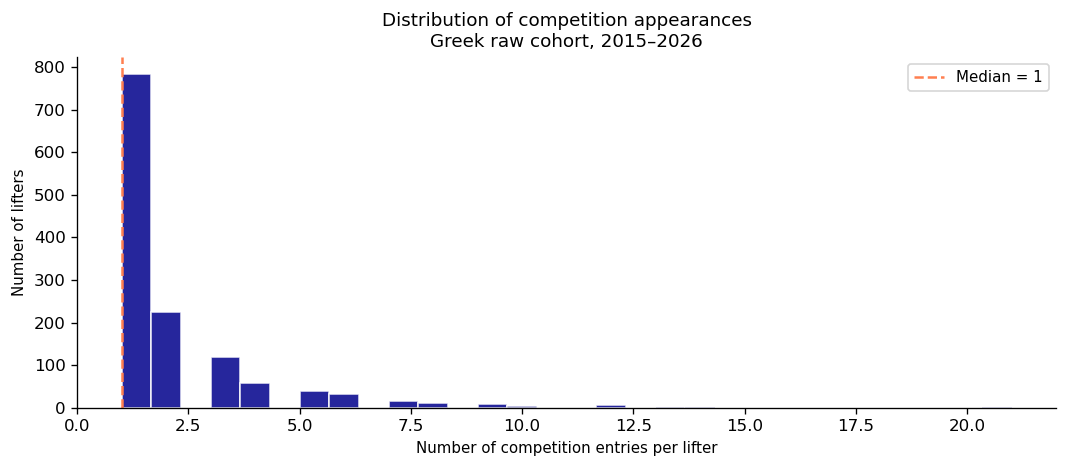

In [7]:
n_unique_lifters  = df['Name'].nunique()
entries_per_lifter = df.groupby('Name').size()

sep = '=' * 43

print(f"{sep}") 
print(f"Unique lifters in cohort:      {n_unique_lifters:,}")
print(f"Total competition entries:     {len(df):,}")
print(f"{sep}")
print()
print(f"{sep}")
print(f"\nEntries per lifter:")
print(f"  Mean:    {entries_per_lifter.mean():.1f}")
print(f"  Median:  {entries_per_lifter.median():.0f}")
print(f"  Min:     {entries_per_lifter.min()}")
print(f"  Max:     {entries_per_lifter.max()}")
print(f"{sep}") 
# Bin lifters by number of appearances to show the distribution shape
bins   = [1, 2, 5, 10, 20, np.inf]
labels = ['1', '2-4', '5-9', '10-19', '20+']

binned        = pd.cut(entries_per_lifter, bins=bins, labels=labels, right=False)
bin_counts    = binned.value_counts().sort_index()

print() 
print(f"{sep}") 
print(f"Lifters by number of appearances:")
for label, count in bin_counts.items():
    pct = count / n_unique_lifters * 100
    print(f"  {label:>5} appearances: {count:>4} lifters  ({pct:.1f}%)")
print(f"{sep}") 
print() 
# Plot: histogram of entries per lifter
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(entries_per_lifter, bins=30, color='darkblue',
        edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of competition entries per lifter')
ax.set_ylabel('Number of lifters')
ax.set_title('Distribution of competition appearances\nGreek raw cohort, 2015–2026')

median_val = entries_per_lifter.median()
ax.axvline(median_val, color='coral', linewidth=1.5,
           linestyle='--', label=f'Median = {median_val:.0f}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(plots_dir / 'lifter_appearances.png', bbox_inches='tight')
plt.show()

## Cell 7 —  Top lifters by appearance count

The top lifters by entry count are the most influential observations in the dataset. Knowing who they are helps assess whether the model
is dominated by a small group of very active competitors.

In [8]:
top_lifters = (
    df.groupby('Name')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_lifters.columns = ['Name', 'n_entries']

print("Top 20 lifters by number of competition entries:")
top_lifters.index = top_lifters.index + 1
print(top_lifters.to_string()) 

Top 20 lifters by number of competition entries:
                         Name  n_entries
1              Marios Liatsis         21
2        Konstantinos Lazaris         14
3          Emmanouel Varveris         13
4       Konstantinos Barounis         12
5        Alexandros Sakarikas         12
6             Odysseas Markou         12
7       Panagiwtis Mpoldoglou         12
8         Dimitris Davazoglou         12
9                 Mary Tsimpi         12
10            Sofia Andreikou         10
11              Savvas Savvas         10
12        Panagiotis Perentis         10
13     Vasileios Karakatsanis          9
14  Alexandros-Ioannis Drosos          9
15     Despoina Charitopoulou          9
16  Konstantinos Konstantatos          9
17           Thomas Aggelakis          9
18        Nikolaos Kakaletris          9
19            Nikolaos Karras          9
20      Panagiotis Kachilelis          9


## Cell 8 - Federation and year breakdown 

Federation breakdown reveals which organizations dominate Greek powerlifting. Year distribution shows the growth of the sport and justifies the 2015 cutoff.

The SBD filter reshuffles the federation landscape significantly: HPF dominates (66% of entries) because it specialises in full-power meets, while ESDT — the largest federation in the unfiltered data — collapses to 11% since it primarily runs single-lift and push-pull events. Phase 2 note: the dummy reference category should be HPF, not ESDT.

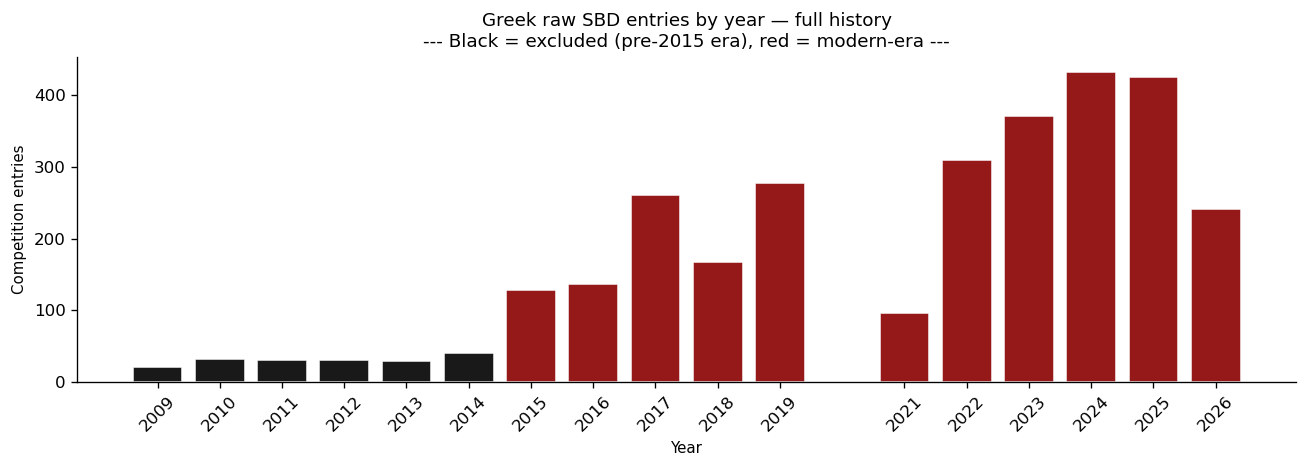

In [9]:
greek_sbd_raw = df_raw[
    (df_raw['Country'] == 'Greece') &
    (df_raw['Equipment'] == 'Raw') &
    (df_raw['Event'] == 'SBD')
].copy()
greek_sbd_raw['Year'] = pd.to_datetime(greek_sbd_raw['Date']).dt.year

year_counts = greek_sbd_raw['Year'].value_counts().sort_index()
colors      = ['black' if y < 2015 else 'darkred' for y in year_counts.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(year_counts.index, year_counts.values, color=colors, edgecolor='white', alpha = 0.9)
ax.set_xlabel('Year')
ax.set_ylabel('Competition entries')
ax.set_title('Greek raw SBD entries by year — full history\n--- Black = excluded (pre-2015 era), red = modern-era ---')
ax.set_xticks(year_counts.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(plots_dir / 'year_cutoff_justification.png', bbox_inches='tight')
plt.show()

============= Federation Breakdown =============
Federation
HPF           1736
GPL            417
ESDT           292
EPF             66
IPL             49
GPA             33
IPF             20
WP               9
WRPF-Spain       4
PLSS             4
ABS              3
KNKF-SP          3
PLTRAW           2
PLU              2
CyprusPF         2
WRPF-DE          1
WRPF-UK          1
WRPF             1
Germany-UA       1
============= Parent Federation Breakdown =============
ParentFederation
IPF     1831
IPL      466
WP       301
GPA       33
WRPF       7
============= Entries by Year =============
Year
2015    120
2016    118
2017    240
2018    158
2019    246
2021     87
2022    285
2023    352
2024    407
2025    400
2026    233


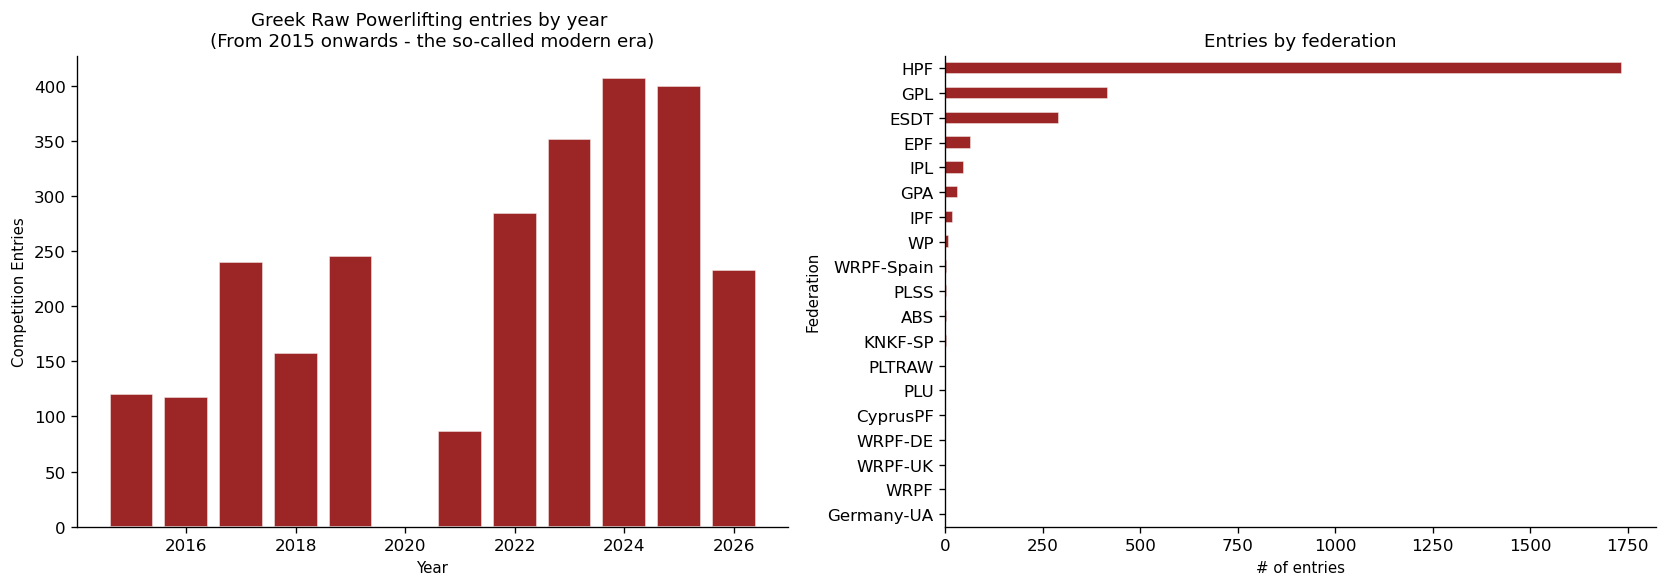

In [10]:
sep = '=' * 13  

print(sep, 'Federation Breakdown', sep)
fed_counts = df['Federation'].value_counts()
print(fed_counts.to_string())

print(sep, 'Parent Federation Breakdown', sep) 
parent_fed_counts = df['ParentFederation'].value_counts() 
print(parent_fed_counts.to_string())

print(sep, 'Entries by Year', sep) 
year_counts = df['Year'].value_counts().sort_index() 
print(year_counts.to_string())

print(4 * sep)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: bar chart of entries per year
year_index  = year_counts.index.tolist()
year_values = year_counts.values.tolist()

axes[0].bar(year_index, year_values, color = 'darkred', edgecolor = 'white', alpha = 0.85)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Competition Entries')
axes[0].set_title('Greek Raw Powerlifting entries by year \n(From 2015 onwards - the so-called modern era)')

# Right: federation breakdown horizontally 
fed_counts.plot(kind = 'barh', ax = axes[1], color = 'darkred', edgecolor = 'white', alpha = 0.85)
axes[1].set_xlabel('# of entries')
axes[1].set_ylabel('Federation')
axes[1].set_title('Entries by federation')
axes[1].invert_yaxis() 

plt.tight_layout() 
plt.savefig(plots_dir / 'federation_year_breakdown.png', bbox_inches='tight')
plt.show() 

## Cell 9 — Cohort breakdown by sex and weight class

In [11]:
sep = '=' * 13  

print(sep, 'By Sex', sep)
sex_counts = df['Sex'].value_counts()
print(sex_counts.to_string())

print(sep, 'By WeightClass (in Kg)', sep)
weight_counts = df['WeightClassKg'].value_counts().sort_index() 
print(weight_counts.to_string())

print(sep, 'Sex × WeightClassKg', sep) 
crosstab = pd.crosstab(df['Sex'], df['WeightClassKg'])
print(crosstab.to_string()) 

============= By Sex =============
Sex
M    2109
F     537
============= By WeightClass (in Kg) =============
WeightClassKg
100     110
100+      1
105     227
110      58
120     102
120+     76
125      37
140       9
140+      9
145       1
43        2
47        7
48        6
52       57
53       10
56       35
57       66
58        5
59       15
60       33
62        1
63       84
64        2
66      103
67.5     81
69       54
72       25
74      214
75      102
76       43
77        4
82.5    138
83      369
84       17
84+      15
85        3
90      143
90+       1
93      371
94        3
============= Sex × WeightClassKg =============
WeightClassKg  100  100+  105  110  120  120+  125  140  140+  145  43  47  48  52  53  56  57  58  59  60  62  63  64   66  67.5  69  72   74  75  76  77  82.5   83  84  84+  85   90  90+   93  94
Sex                                                                                                                                                   

## Cell 10 — Statistical summary of filtered cohort

Statistical summary of the key numerical columns after all filtering. This is the first meaningful summary — earlier describe() on df_raw
was dominated by non-Greek entries and is not informative for modeling.

In [12]:
cols_of_interest = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age', 'Dots', 'Wilks', 'Goodlift'
]

summary = df[cols_of_interest].describe().T 
print(summary) 

                  count   mean    std    min    25%    50%    75%    max
Best3SquatKg    2606.00 174.12  56.22  20.00 132.50 175.00 210.00 380.00
Best3BenchKg    2604.00 112.99  39.34  15.00  85.00 117.50 140.00 230.00
Best3DeadliftKg 2605.00 203.12  56.42  20.00 160.50 207.50 242.50 375.00
TotalKg         2646.00 489.62 145.96 110.00 382.50 500.00 589.38 907.50
BodyweightKg    2645.00  83.90  19.51  30.00  71.40  82.05  92.50 212.10
Age             1828.00  25.96   7.92  10.00  21.00  24.00  29.00  74.50
Dots            2645.00 348.32  67.79 110.10 304.07 347.25 392.64 573.92
Wilks           2645.00 346.31  67.29 107.63 303.04 345.25 390.40 566.69
Goodlift        2643.00  71.04  13.80  23.06  61.98  70.97  80.19 118.00


## Cell 11 — Best3* semantic verification

Each Best3* column should equal the maximum of the three individual attempt columns for that lift (ignoring failed or missing attempts).
We verify this on a random sample to confirm internal consistency.

Mismatches usually mean the federation reported only the best lift, without individual attempts — not a data error, just incomplete reporting.

In [13]:
def verify_best3(df, attempt_cols, best_col, n_sample=300):
    # Keep only rows where the best column is not missing
    available = df[attempt_cols + [best_col]].dropna(subset=[best_col]).copy()
    sample    = available.sample(min(n_sample, len(available)), random_state=42)

    # Treat non-positive values as missing — failed attempts are negative
    attempts_positive = sample[attempt_cols].apply(
        lambda col: col.where(col > 0)
    )

    # The computed best should be the maximum across the three attempts
    computed_best = attempts_positive.max(axis=1)

    # Allow small tolerance for floating point differences
    matches    = np.isclose(computed_best, sample[best_col], atol=0.01)
    mismatches = sample[matches == False]

    return len(sample), matches.sum(), (matches == False).sum(), mismatches


checks = [
    (['Squat1Kg',    'Squat2Kg',    'Squat3Kg'],    'Best3SquatKg'),
    (['Bench1Kg',    'Bench2Kg',    'Bench3Kg'],    'Best3BenchKg'),
    (['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'], 'Best3DeadliftKg'),
]

for attempt_cols, best_col in checks:
    n_checked, n_matched, n_mismatched, bad_rows = verify_best3(
        df, attempt_cols, best_col
    )

    print(f"{best_col}")
    print(f"  Checked: {n_checked}  |  Matched: {n_matched}  |  Mismatched: {n_mismatched}")

    if n_mismatched > 0:
        print("  Sample mismatches (federations reporting best only):")
        print(bad_rows[attempt_cols + [best_col]].head(3).to_string())
    print()

Best3SquatKg
  Checked: 300  |  Matched: 287  |  Mismatched: 13
  Sample mismatches (federations reporting best only):
         Squat1Kg  Squat2Kg  Squat3Kg  Best3SquatKg
2742223       NaN       NaN       NaN        130.00
2742374       NaN       NaN       NaN        126.00
2742376       NaN       NaN       NaN        170.00

Best3BenchKg
  Checked: 300  |  Matched: 285  |  Mismatched: 15
  Sample mismatches (federations reporting best only):
         Bench1Kg  Bench2Kg  Bench3Kg  Best3BenchKg
2742223       NaN       NaN       NaN         90.00
2739191       NaN       NaN       NaN        122.50
2742374       NaN       NaN       NaN        104.00

Best3DeadliftKg
  Checked: 300  |  Matched: 287  |  Mismatched: 13
  Sample mismatches (federations reporting best only):
         Deadlift1Kg  Deadlift2Kg  Deadlift3Kg  Best3DeadliftKg
2742223          NaN          NaN          NaN           170.00
2742654          NaN          NaN          NaN           215.00
2742374          NaN          

## Cell 12 — Attempt column missingness

Individual attempt columns are often missing when a federation reports only the best lift rather than all three attempts.
This does not affect our targets (Best3*) but matters if we later want to use attempt progression as a feature in Phase 2.

In [14]:
sep = '=' * 13

attempt_cols_all = [
    'Squat1Kg',    'Squat2Kg',    'Squat3Kg',
    'Bench1Kg',    'Bench2Kg',    'Bench3Kg',
    'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'
]

print(sep, 'Attempt column missingness', sep)
for col in attempt_cols_all:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<15} {n_missing:>5} missing  ({pct:.1f}%)") 

============= Attempt column missingness =============
  Squat1Kg          179 missing  (6.8%)
  Squat2Kg          205 missing  (7.7%)
  Squat3Kg          284 missing  (10.7%)
  Bench1Kg          179 missing  (6.8%)
  Bench2Kg          193 missing  (7.3%)
  Bench3Kg          310 missing  (11.7%)
  Deadlift1Kg       177 missing  (6.7%)
  Deadlift2Kg       194 missing  (7.3%)
  Deadlift3Kg       294 missing  (11.1%)


## Cell 13 — Target and feature missingness audit 

We separate targets, features, and scoring metrics into three groups. Dots, Wilks, and Goodlift are flagged explicitly as derived columns
to remind us not to use them as features in Phase 2.

In [15]:
sep = '=' * 13

target_cols  = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']
feature_cols = ['BodyweightKg', 'Age', 'Sex', 'WeightClassKg', 'Federation', 'Tested']
score_cols   = ['Dots', 'Wilks', 'Goodlift']

print(sep, 'Target missingness', sep)
for col in target_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(sep, 'Feature missingness', sep) 
for col in feature_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(sep, 'Scoring metrics (derived from target)', sep) 
for col in score_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(4 * sep )
print('  Note: Dots, Wilks, and Goodlift are computed from')
print('  TotalKg and BodyweightKg. Using them as features')
print('  would cause target leakage — excluded from modeling.')
print(4 * sep ) 

============= Target missingness =============
  Best3SquatKg              40 missing  (1.5%)
  Best3BenchKg              42 missing  (1.6%)
  Best3DeadliftKg           41 missing  (1.5%)
  TotalKg                    0 missing  (0.0%)
============= Feature missingness =============
  BodyweightKg               1 missing  (0.0%)
  Age                      818 missing  (30.9%)
  Sex                        0 missing  (0.0%)
  WeightClassKg              7 missing  (0.3%)
  Federation                 0 missing  (0.0%)
  Tested                   668 missing  (25.2%)
============= Scoring metrics (derived from target) =============
  Dots                       1 missing  (0.0%)
  Wilks                      1 missing  (0.0%)
  Goodlift                   3 missing  (0.1%)
  Note: Dots, Wilks, and Goodlift are computed from
  TotalKg and BodyweightKg. Using them as features
  would cause target leakage — excluded from modeling.


## Cell 14 — Missingness heatmap

Visual representation of the missingness structure. Red cells are missing, gray cells are present. Horizontal red bands indicate a column that is mostly missing. Vertical red stripes indicate specific rows missing many values.

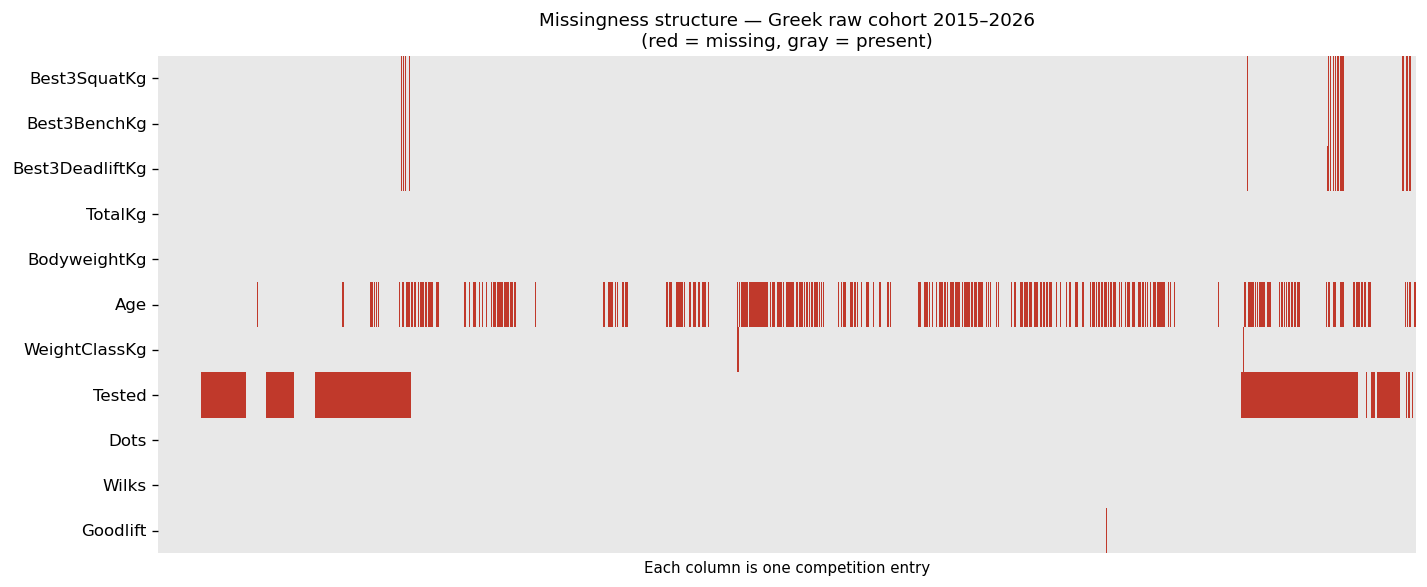

In [16]:
cols_for_heatmap = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age', 'WeightClassKg', 'Tested',
    'Dots', 'Wilks', 'Goodlift'
]

missing_matrix = df[cols_for_heatmap].isna().astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    missing_matrix.T,
    cbar        = False,
    cmap        = ['#e8e8e8', '#c0392b'],
    ax          = ax,
    yticklabels = cols_for_heatmap,
    xticklabels = False
)

ax.set_xlabel('Each column is one competition entry', fontsize=9)
ax.set_title(
    'Missingness structure — Greek raw cohort 2015–2026\n'
    '(red = missing, gray = present)',
    fontsize=11
)

plt.tight_layout()
plt.savefig(plots_dir / 'missingness_heatmap.png', bbox_inches='tight')
plt.show()

## Cell 15 — Skewness, kurtosis, and Q-Q plots

We check whether the four target distributions are approximately normal. Skewness > 1.0 in absolute value typically warrants a log transformation. The Q-Q plot shows where the distribution departs from normality — heavy tails appear as points curving away from the diagonal at the extremes. (excess kurtosis; normal distribution = 0) 

Target                   Skewness   Kurtosis   Suggestion
──────────────────────────────────────────────────────────────
Best3SquatKg                0.187     -0.142   ok as-is
Best3BenchKg               -0.040     -0.430   ok as-is
Best3DeadliftKg            -0.130     -0.387   ok as-is
TotalKg                    -0.041     -0.464   ok as-is


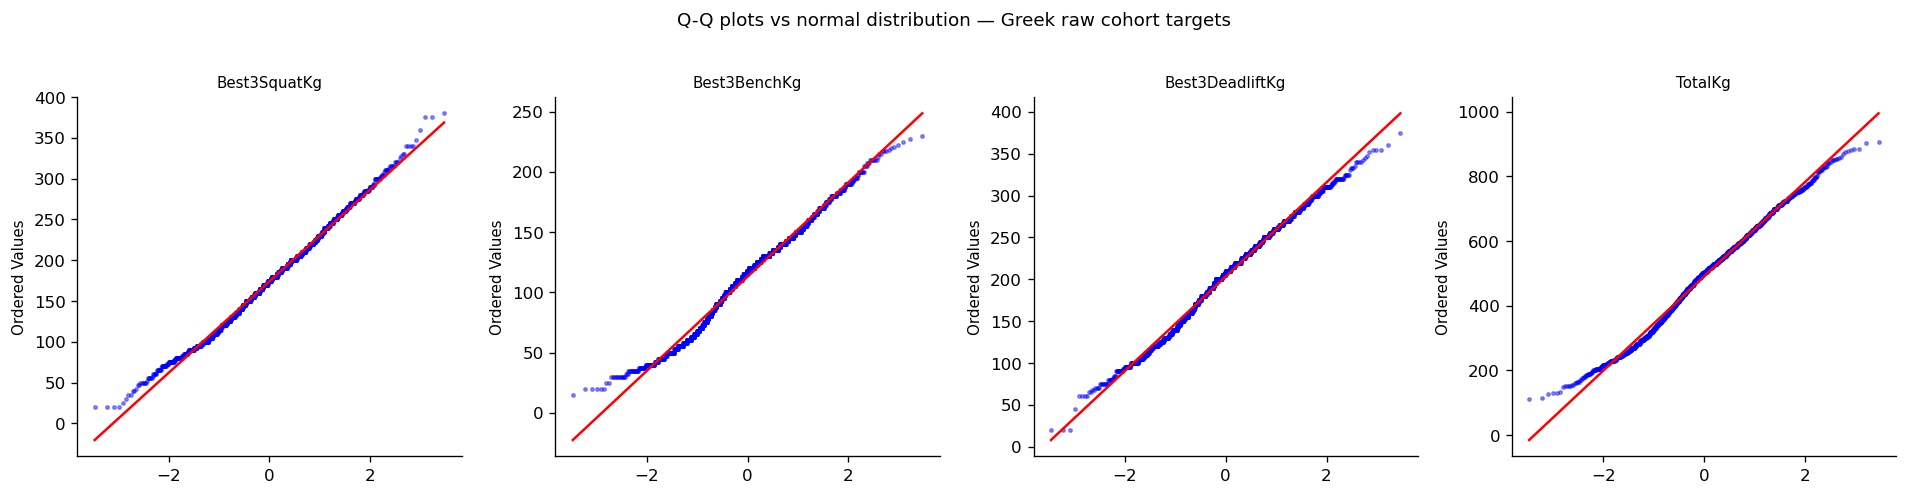

============= TotalKg skewness by sex =============
  M: skewness = 0.115  (n=2,109)
  F: skewness = 0.274  (n=537)


In [17]:
targets = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']

print(f"{'Target':<22} {'Skewness':>10} {'Kurtosis':>10}   {'Suggestion'}")
print('─' * 62)

for target in targets:
    data       = df[target].dropna()
    skewness   = data.skew()
    kurtosis   = data.kurtosis()
    suggestion = 'consider log transform' if abs(skewness) > 1.0 else 'ok as-is'
    print(f"{target:<22} {skewness:>10.3f} {kurtosis:>10.3f}   {suggestion}")

# Q-Q plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, target in zip(axes, targets):
    data = df[target].dropna()
    scipy_stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(target, fontsize=9)
    ax.set_xlabel('')
    ax.get_lines()[0].set(markersize=2, alpha=0.4)

plt.suptitle(
    'Q-Q plots vs normal distribution — Greek raw cohort targets',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'qq_plots_targets.png', bbox_inches='tight')
plt.show()

sep = '=' * 13

# Check skewness split by sex
# Symmetry holds within each sex too
print(sep, 'TotalKg skewness by sex', sep)
for sex in ['M', 'F']:
    subset   = df[df['Sex'] == sex]['TotalKg'].dropna()
    skewness = subset.skew()
    print(f"  {sex}: skewness = {skewness:.3f}  (n={len(subset):,})")

print(4 * sep)

## Cell 16 — Log-transform evaluation with KDE

For each target we show the raw and log-transformed distributions side by side with KDE curves overlaid on histograms.
```density = True``` normalizes the histogram so the KDE and bars are on the same scale and directly comparable.

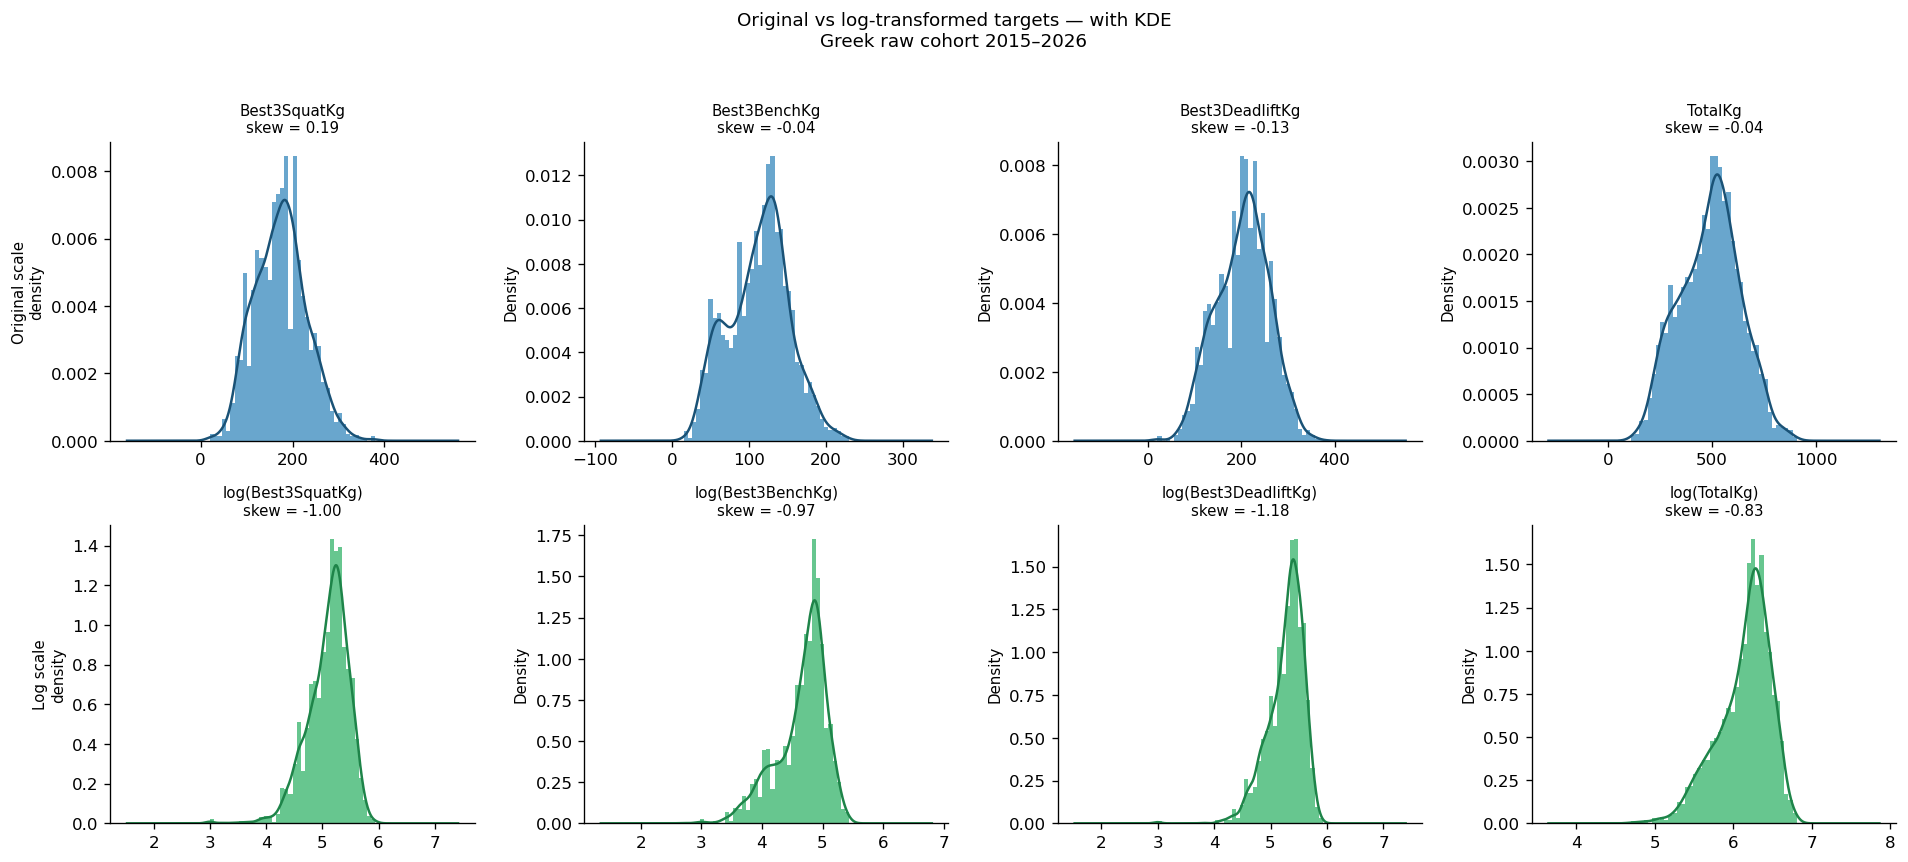

In [18]:
targets = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, target in enumerate(targets):
    raw_data = df[target].dropna()
    raw_data = raw_data[raw_data > 0]
    log_data = np.log(raw_data)

    raw_skew = raw_data.skew()
    log_skew = log_data.skew()

    # Top row: raw scale
    axes[0, i].hist(raw_data, bins=40, color='#2980b9',
                    edgecolor='none', alpha=0.7, density=True)
    raw_data.plot.kde(ax=axes[0, i], color='#1a5276', linewidth=1.5)
    axes[0, i].set_title(f"{target}\nskew = {raw_skew:.2f}", fontsize=9)

    # Bottom row: log scale
    axes[1, i].hist(log_data, bins=40, color='#27ae60',
                    edgecolor='none', alpha=0.7, density=True)
    log_data.plot.kde(ax=axes[1, i], color='#1e8449', linewidth=1.5)
    axes[1, i].set_title(f"log({target})\nskew = {log_skew:.2f}", fontsize=9)

axes[0, 0].set_ylabel('Original scale\ndensity', fontsize=9)
axes[1, 0].set_ylabel('Log scale\ndensity', fontsize=9)

plt.suptitle(
    'Original vs log-transformed targets — with KDE\nGreek raw cohort 2015–2026',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'log_transform_evaluation.png', bbox_inches='tight')
plt.show()
# No transformation warranted; log would introduce left-skew

## Cell 17 — Correlation analysis: features only

Pearson correlation between the numerical features and targets. Dots, Wilks, and Goodlift are excluded — they are derived from TotalKg and would produce artificially high correlations.

============= Top correlates with TotalKg =============
Best3SquatKg      0.97
Best3DeadliftKg   0.97
Best3BenchKg      0.94
BodyweightKg      0.66
Age               0.01


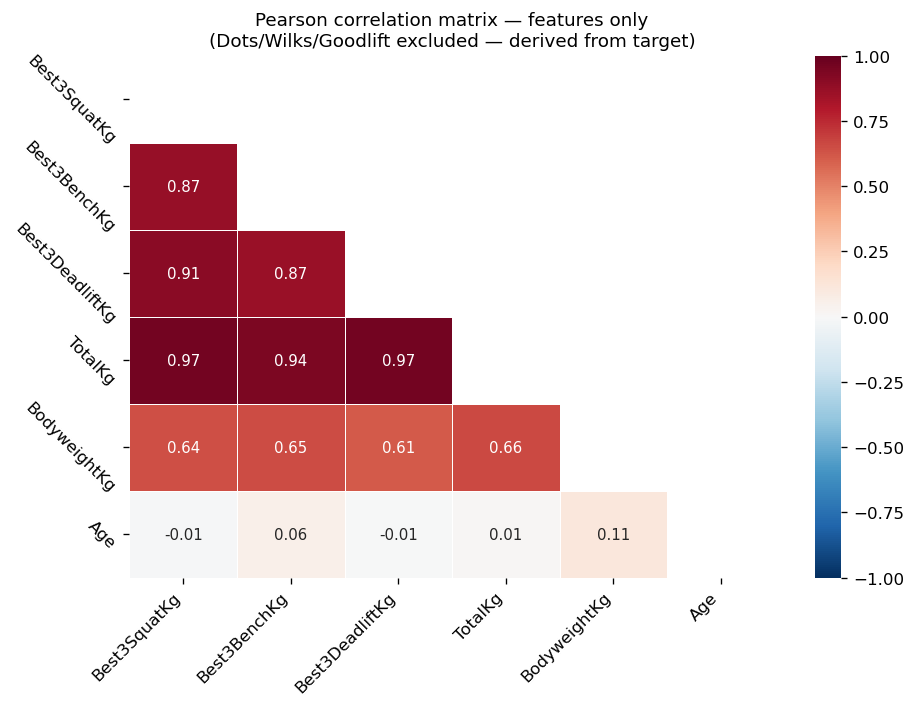

In [19]:
sep = '=' * 13

feature_numeric_cols = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age'
]

corr_matrix = df[feature_numeric_cols].corr()

print(sep, 'Top correlates with TotalKg', sep)
total_corr = corr_matrix['TotalKg'].drop('TotalKg')
total_corr = total_corr.abs().sort_values(ascending=False)
print(total_corr.round(3).to_string())

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 9}
)

ax.set_title(
    'Pearson correlation matrix — features only\n'
    '(Dots/Wilks/Goodlift excluded — derived from target)',
    fontsize=11
)

# Fix y-axis label rotation 
ax.set_yticklabels(ax.get_yticklabels(), rotation = -45)

# Fix x-axis label rotation 
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')

plt.tight_layout()
plt.savefig(plots_dir / 'correlation_heatmap_features.png', bbox_inches='tight')
plt.show()

## Cell 18 — Scoring metrics: leakage confirmation

================= Correlation of scoring metrics with TotalKg =================
BodyweightKg   0.66
Dots           0.78
Wilks          0.77
Goodlift       0.78

Dots, Wilks, and Goodlift are deterministic functions of TotalKg and BodyweightKg.
They are the target, repackaged — so they leak by construction.


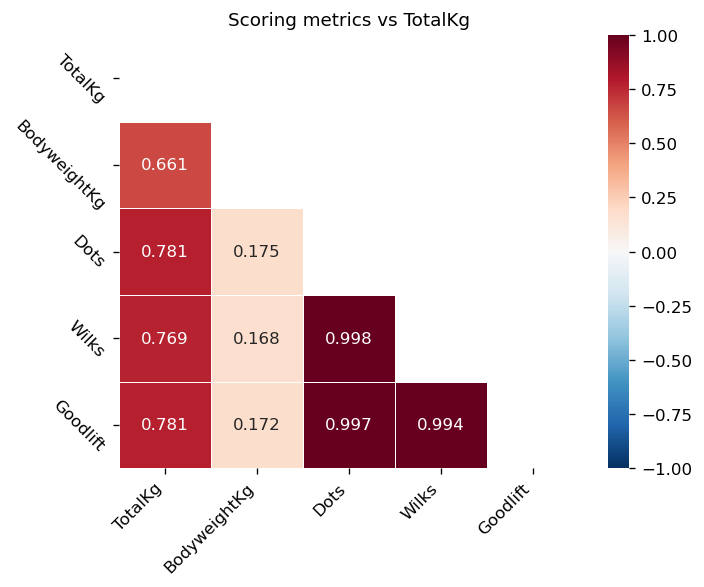

In [20]:
sep = '=' * 17

score_cols_check = ['TotalKg', 'BodyweightKg', 'Dots', 'Wilks', 'Goodlift']

score_corr = df[score_cols_check].corr()

print(sep, 'Correlation of scoring metrics with TotalKg', sep)
score_with_total = score_corr['TotalKg'].drop('TotalKg')
print(score_with_total.round(4).to_string())
print()
print('Dots, Wilks, and Goodlift are deterministic functions of TotalKg and BodyweightKg.')
print('They are the target, repackaged — so they leak by construction.')

mask_score = np.triu(np.ones_like(score_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    score_corr,
    mask       = mask_score,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 10}
)

ax.set_title(
    'Scoring metrics vs TotalKg',
    fontsize=11
)

# Fix y-axis label rotation  
ax.set_yticklabels(ax.get_yticklabels(), rotation = -45)

# Fix x-axis label rotation  
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')

plt.tight_layout()
plt.savefig(plots_dir / 'correlation_scoring_leakage.png', bbox_inches='tight')
plt.show()

## Cell 19 — Comparative summary statistics 

Descriptive statistics for each group side by side. We split by sex for completeness, confirming both male and female distributions are symmetric after the SBD restriction.

In [21]:
sep = '=' * 17

# Combine all three groups into one dataframe for plotting
df_greece_labelled = df.copy()
df_greece_labelled['Group'] = 'Greece'
print(f"{'Greece':<30} {len(df_greece_labelled):>7,} entries  "
      f"| {df_greece_labelled['Name'].nunique():>5} unique lifters")

df_comparison = pd.concat(
    [df_greece_labelled, df_south_a, df_balkans_a],
    ignore_index=True
)

print(f"\nCombined comparison dataframe: {len(df_comparison):,} rows")

targets      = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']
groups       = ['Greece', 'Southern Europe', 'Balkans (excl. Greece)']
sexes        = ['M', 'F']
sex_labels   = {'M': 'Male', 'F': 'Female'}

for sex in sexes:
    print(f"{5 * sep}")
    print(f"  {sex_labels[sex]} lifters")
    print(f"{5 * sep}")

    for target in targets:
        print(f"\n  {target}")
        print(f"  {'Group':<28} {'Mean':>8} {'Median':>8} {'Std':>8} {'n':>6}")
        print(f"  {'─'*56}")

        for group in groups:
            subset = df_comparison[
                (df_comparison['Group'] == group) &
                (df_comparison['Sex']   == sex)
            ][target].dropna()

            if len(subset) == 0:
                print(f"  {group:<28} {'no data':>8}")
                continue

            mean   = subset.mean()
            median = subset.median()
            std    = subset.std()
            n      = len(subset)

            print(f"  {group:<28} {mean:>8.1f} {median:>8.1f} {std:>8.1f} {n:>6,}")

Greece                           2,646 entries  |  1307 unique lifters

Combined comparison dataframe: 43,105 rows
  Male lifters

  Best3SquatKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          191.0    190.0     48.8  2,071
  Southern Europe                 202.2    200.0     41.8 21,757
  Balkans (excl. Greece)          194.2    192.5     47.7  7,033

  Best3BenchKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          127.0    127.5     30.4  2,069
  Southern Europe                 128.0    125.0     27.0 21,756
  Balkans (excl. Greece)          129.3    127.5     31.7  7,034

  Best3DeadliftKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          221.9    220.0     45.6

## Cell 20 — Comparative KDE plots: all four targets

KDE curves for all four targets across the three groups, split by sex. Layout: 2 rows (M/F) × 4 columns (targets). Each panel shows three overlapping KDE curves — one per group.
Overlapping curves reveal whether distributions are similar or whether one group is systematically stronger or weaker.

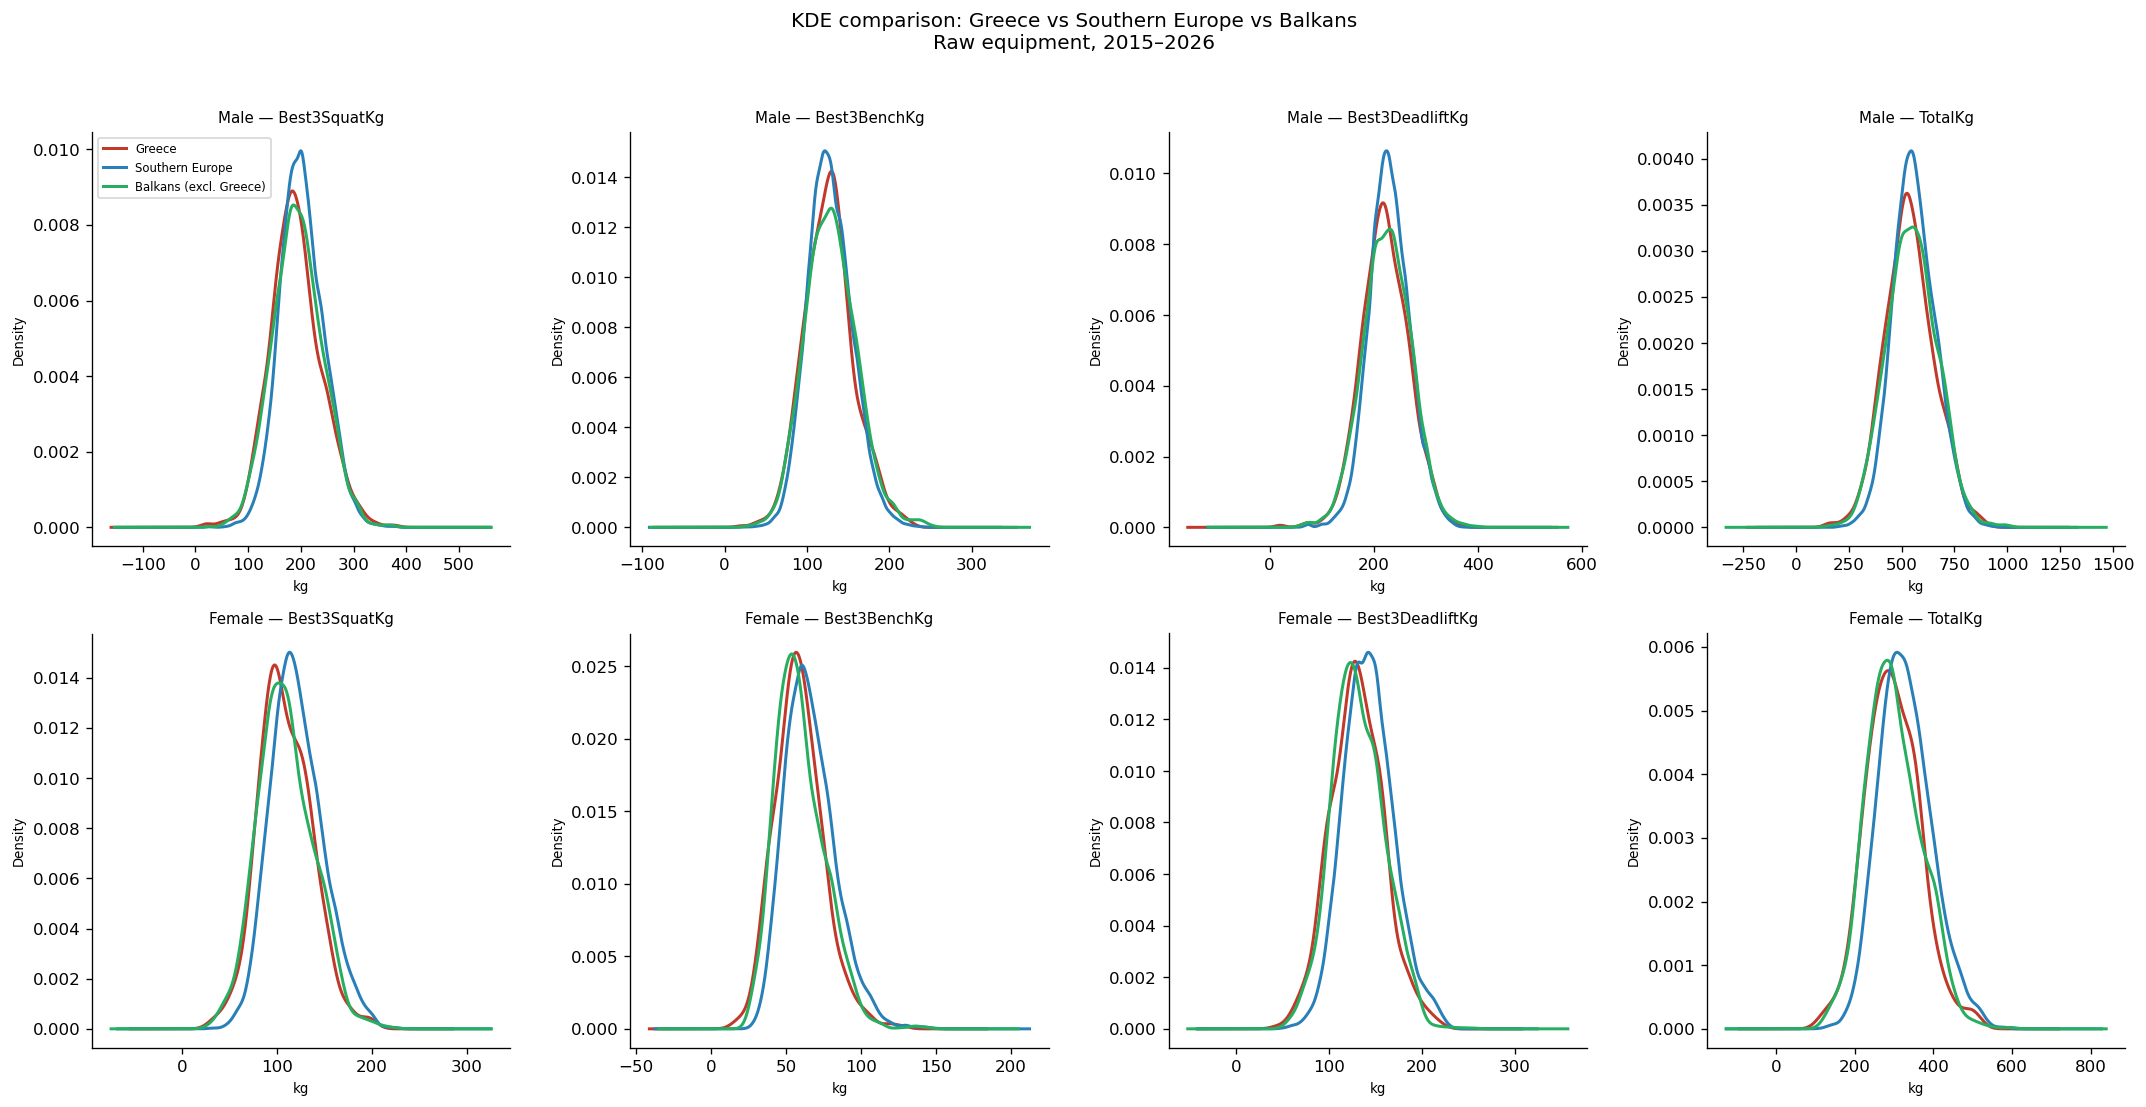

In [22]:
group_colors = {
    'Greece':                 '#c0392b',
    'Southern Europe':        '#2980b9',
    'Balkans (excl. Greece)': '#27ae60'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row_idx, sex in enumerate(['M', 'F']):
    for col_idx, target in enumerate(targets):
        ax = axes[row_idx, col_idx]

        for group in groups:
            subset = df_comparison[
                (df_comparison['Group'] == group) &
                (df_comparison['Sex']   == sex)
            ][target].dropna()

            if len(subset) < 10:
                continue

            subset.plot.kde(
                ax        = ax,
                color     = group_colors[group],
                linewidth = 1.8,
                label     = group
            )

        sex_label = 'Male' if sex == 'M' else 'Female'
        ax.set_title(f"{sex_label} — {target}", fontsize=9)
        ax.set_xlabel('kg', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)

        # Only show legend on the first panel to avoid repetition
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc='upper left')

plt.suptitle(
    'KDE comparison: Greece vs Southern Europe vs Balkans\n'
    'Raw equipment, 2015–2026',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'comparative_kde_all_targets.png', bbox_inches='tight')
plt.show()

# PHASE 2: FEATURE ENGINEERING AND PREPROCESSING

1. **Goal**: turn the cohort into leakage-free, well-conditioned feature matrices ready for modelling.
2. **Motivation**: the scoring columns (Dots/Wilks/Goodlift) are the target repackaged; federation and age need principled encoding; the pipeline must not leak test information.
3. **Approach**: baselines first (the floors to beat), Tested/federation/weight-class encoding, the two feature variants (base vs age-augmented), train-only scaling, and the diagnostic suite (leakage audit, condition number).

## Cell 21 — Compute the baselines

We compute the:

1. predict-the-mean RMSE
2. per-sex-mean RMSE
3. per-sex bodyweight linear regression RMSE on TotalKg
  
Three numbers stored as constants — the floors every later model has to beat.

In [23]:
#
# Overall baseline/Predict-the-mean RMSE 
mean_overall = df['TotalKg'].mean() 
mean_RMSE = calculate_rmse(df["TotalKg"], mean_overall)
print(f"The overall mean is given by:          {mean_overall}", 
      f"The predict-the-mean RMSE is given by: {mean_RMSE}", 
        sep='\n')
print('=' * 63)
# Stratified mean baseline/Per-sex-mean RMSE 
mean_per_sex = df.groupby('Sex')['TotalKg'].transform('mean')
mean_per_sex_RMSE = calculate_rmse(df["TotalKg"], mean_per_sex)
mean_per_sex_display = df.groupby('Sex')['TotalKg'].mean() 
print(f"The per-sex mean is given by:          {mean_per_sex_display}", 
      f"The per-sex-mean RMSE is given by:     {mean_per_sex_RMSE}", 
        sep='\n')
# 
def predict_sex_group_linear_regression(group):
    # drop rows where either feature or target is missing
    # one missing BodyweightKg row in the cohort would otherwise
    # cause np.polyfit's SVD solver to fail
    clean = group[['BodyweightKg', 'TotalKg']].dropna()
    # fit the polynomial (slope and intercept)
    coefficients     = np.polyfit(clean['BodyweightKg'], clean['TotalKg'], deg=1)
    # predict on the full group — the one missing row gets NaN automatically
    y_predictions    = np.polyval(coefficients, group['BodyweightKg'])
    y_predictions_series = pd.Series(y_predictions, index=group.index)
    return y_predictions_series
print('=' * 63)
predictions = (df.groupby('Sex', group_keys = False).apply(predict_sex_group_linear_regression, include_groups=False))
per_sex_linear_regression_RMSE = calculate_rmse(df["TotalKg"], predictions)
print(f"The per-sex-linear regression RMSE is given by:     {per_sex_linear_regression_RMSE}")

The overall mean is given by:          489.6218820861678
The predict-the-mean RMSE is given by: 145.93591978823997
The per-sex mean is given by:          Sex
F   297.48
M   538.55
Name: TotalKg, dtype: float64
The per-sex-mean RMSE is given by:     109.07227657452074
The per-sex-linear regression RMSE is given by:     94.42973447054979


## Cell 22 — Recode Tested

Tested encodes whether the competition was drug-tested. The raw column contains'Yes' or NaN; we recode to a binary integer.

1. Yes means tested, which maps to 1.
2. NaN means untested, which maps to 0.

In [24]:
sep = '=' * 13 
# Tested encodes whether the competition was drug-tested, at least in paperwork 
df['Tested'] = df['Tested'].map({'Yes': 1}).fillna(0).astype(int)
print(sep, 'Tested value counting after recoding', sep)
print(df['Tested'].value_counts().to_string())

============= Tested value counting after recoding =============
Tested
1    1978
0     668


## Cell 23 — Federation grouping

We group federations into tiers to avoid sparse dummy columns.
Rule: federations with ≥100 entries in the SBD cohort become named groups (HPF, GPL, ESDT); everything else gets grouped together under the same umbrella term; Federation_Other. 
We define the HPF as the implicit reference, since it is thelargest cohort and hence will provide us with the most stable baseline; dummy coefficients then read as deviation from HPF. 

In [25]:
sep = '=' * 13 
print(sep, 'Federation counts in Greek raw cohort',sep)
fed_counts = df['Federation'].value_counts()
print(fed_counts.to_string())
print(6 * sep)
#
def assign_federation_groups(federation_name): 
    major_feds = ['HPF', 'GPL', 'ESDT'] 

    if federation_name in major_feds: 
        return federation_name 
    else: 
        return 'Other Federations'

df['FederationGroup'] = df['Federation'].apply(assign_federation_groups) 
print(sep, 'Federation Groups counting', sep) 
print(df['FederationGroup'].value_counts().to_string())

============= Federation counts in Greek raw cohort =============
Federation
HPF           1736
GPL            417
ESDT           292
EPF             66
IPL             49
GPA             33
IPF             20
WP               9
WRPF-Spain       4
PLSS             4
ABS              3
KNKF-SP          3
PLTRAW           2
PLU              2
CyprusPF         2
WRPF-DE          1
WRPF-UK          1
WRPF             1
Germany-UA       1
============= Federation Groups counting =============
FederationGroup
HPF                  1736
GPL                   417
ESDT                  292
Other Federations     201


## Cell 24 — Parse WeightClassKg into a numerical ordinal

WeightClassKg is stored as a string (e.g. '83', '120+', '84+'). The '+' suffix marks the heaviest weight division. We strip the '+' and convert to float so the column can be used as a numerical feature. The open class will always be the largest value within its sex group, preserving the ordinal meaning. 

Note: the numerical values mix classification systems across federations and years, so the column is ordinal within a single federation's scheme but not strictly comparable across all of them. 

In [26]:
sep = '=' * 13 
#
def parse_weight_class(weight_class_string): 
    if pd.isnull(weight_class_string): 
        return np.nan 
    # Remove the '+' suffix if present
    clean_weight_class_string = str(weight_class_string).replace('+', '').strip() 
    # Conversion to float 
    try: 
        return float(clean_weight_class_string)
    except ValueError: 
        return np.nan 

df['WeightClassKg_num'] =  df['WeightClassKg'].apply(parse_weight_class) 
# 
print(sep, 'WeightClassKg_num value counts', sep) 
print(df['WeightClassKg_num'].value_counts().sort_index().to_string()) 
print(4 * sep)
# 
number_missing_weight_class = df['WeightClassKg_num'].isnull().sum() 
print(f'Missing values in the numerical Weight Class: {number_missing_weight_class}')
print(4 * sep)
# 
# impute 7 missing values with within-sex median
# keeping the column complete for Phase 3 residual analysis
for sex in ['M', 'F']: 
    sex_mask = df['Sex'] == sex 
    sex_median = df.loc[sex_mask, 'WeightClassKg_num'].median() 
    missing_mask = sex_mask & df.WeightClassKg_num.isnull() 
    df.loc[missing_mask, 'WeightClassKg_num'] = sex_median 
    # imputing so the column is complete for Phase 3 residual analysis
    number_imputed = missing_mask.sum() 
    if number_imputed > 0: 
        print(f"Imputed {number_imputed} missing values for Sex = {sex} "
              f"with a median of {sex_median:.1f}")

============= WeightClassKg_num value counts =============
WeightClassKg_num
43.00       2
47.00       7
48.00       6
52.00      57
53.00      10
56.00      35
57.00      66
58.00       5
59.00      15
60.00      33
62.00       1
63.00      84
64.00       2
66.00     103
67.50      81
69.00      54
72.00      25
74.00     214
75.00     102
76.00      43
77.00       4
82.50     138
83.00     369
84.00      32
85.00       3
90.00     144
93.00     371
94.00       3
100.00    111
105.00    227
110.00     58
120.00    178
125.00     37
140.00     18
145.00      1
Missing values in the numerical Weight Class: 7
Imputed 6 missing values for Sex = M with a median of 90.0
Imputed 1 missing values for Sex = F with a median of 63.0


## Cell 25 — Derive age category from AgeClass

AgeClass in OpenPowerlifting uses labels with a lower and upper threshold, e.g '20-23'. We map these values to 4 standard powerlifting age divisions, namely sub-juniors, juniors, open, masters. In such a way we an evaluate the performance of the model by the age group in the next Phase even when the Age itself as a value is missing. 

We found three non-standard labels and we aboserbed them likeso: 24-34 & 35-39 were absorbed into Open, 5-12 absorbed into Unknown since it's a data anomaly. 

Note: this column is used for evaluation ONLY - it does NOT enter the feature matrix. 

Note: The Masters cell is thin (114 rows total; 22 female and 92 male). 

In [27]:
sep = '=' * 13  
#
def assign_age_category(age_class): 
    if pd.isnull(age_class): 
        return 'Unknown' 

    age_class = str(age_class).strip() 

    # sub-junior definition 
    if age_class in ['13-15', '15-16', '16-17', '17-18', '18-19', 'Sub-Junior']: 
        return 'Sub-Junior'
    # junior definition 
    elif age_class in ['20-23', 'Junior']: 
        return 'Junior' 
    # masters definition 
    elif any(age_class.startswith(prefix) for prefix in
             ['40', '45', '50', '55', '60', '65', '70', '75', '80', 'Masters']):
        return 'Masters' 
    # open definition 
    elif age_class == 'Open': 
        return 'Open'
    # broad adult bracket used by some federations — maps to Open
    elif age_class in ['24-34', '35-39']:
        return 'Open'
    # single anomalous entry, likely a data error
    elif age_class == '5-12':
        return 'Unknown'
    # catch-all safety net  
    else:
        return 'Unknown'

df['AgeCategory'] = df['AgeClass'].apply(assign_age_category) 

print(sep, 'Age Category Distribution',sep) 
print(df['AgeCategory'].value_counts().to_string())
print(sep, 'AgeCategory × Sex',sep) 
age_sex_crosstab = pd.crosstab(df['AgeCategory'], df['Sex'])
print(age_sex_crosstab.to_string()) 

============= Age Category Distribution =============
AgeCategory
Open          869
Unknown       769
Junior        573
Sub-Junior    311
Masters       124
============= AgeCategory × Sex =============
Sex            F    M
AgeCategory          
Junior       115  458
Masters       28   96
Open         205  664
Sub-Junior    41  270
Unknown      148  621


## Cell 26 — Feature engineering

We build two feature matrix variants for each cohort:

Base features (no Age): Sex_binary, BodyweightKg, federation dummies. Available for all entries — no missingness after BodyweightKg drop

Age-augmented features (with Age): All base features plus Age. Restricted to entries where Age is not missing. 

The dummy encoding is fitted on the full dataset before the train/test split to ensure both splits have the same columns. Fitting dummies inside the split would risk column mismatches if a rare federation group appears in only one split.

In [28]:
cols_to_check = ['Tested', 'FederationGroup', 'WeightClassKg_num', 'AgeCategory']
for col in cols_to_check:
    present = col in df_complete.columns
    print(f"{col:<25} in df_complete: {present}")

Tested                    in df_complete: True
FederationGroup           in df_complete: False
WeightClassKg_num         in df_complete: False
AgeCategory               in df_complete: False


In [29]:
# Sync all Phase 2 derived columns from df to df_complete
# df_complete is a subset of df (index-aligned), so we propagate by index
cols_to_sync = ['FederationGroup', 'WeightClassKg_num', 'AgeCategory']
for col in cols_to_sync:
    df_complete[col] = df.loc[df_complete.index, col]

# Verify
for col in cols_to_sync:
    print(f"{col:<25} in df_complete: {col in df_complete.columns}")

FederationGroup           in df_complete: True
WeightClassKg_num         in df_complete: True
AgeCategory               in df_complete: True


In [30]:
bsep = '=' * 13  

def build_feature_matrix(df_input): 
    working = df_input.copy()
    working = working.dropna(subset=['BodyweightKg']) 

    # binary encode sex: male (1) / female (0) 
    working['Sex_binary'] = (working['Sex'] == 'M').astype(float) 

    # one-hot encoding FederationGroup 
    federation_dummies = pd.get_dummies(
    working['FederationGroup'],
    prefix='Fed'
    )
    # drop HPF to make it the reference category
    # HPF is the largest group (66%) — coefficients measure deviation from HPF
    federation_dummies = federation_dummies.drop(columns=['Fed_HPF'])
    # WeightClassKg_num is excluded; it carries no independent information in a linear model. 

    # Base feature set — no Age
    base_columns = ['Sex_binary', 'BodyweightKg'] 
    X_base = pd.concat([working[base_columns], federation_dummies], axis = 1) 

    # Age-augmented feature set — ONLY complete cases 
    age_columns = ['Sex_binary', 'BodyweightKg', 'Age']
    X_age = pd.concat([working[age_columns], federation_dummies], axis = 1) 
    X_age = X_age.dropna(subset = ['Age']) 

    federation_column_names = federation_dummies.columns.tolist() 

    return X_base, X_age, federation_column_names 

# Build feature matrices for both cohorts
X_base_total, X_age_total, federation_column_total = build_feature_matrix(df) 
X_base_sbd, X_age_sbd, federation_column_sbd = build_feature_matrix(df_complete)

# Align SBD dummy columns to match total cohort columns 
for column in X_base_total.columns: 
    if column not in X_base_sbd.columns:
        X_base_sbd[column] = 0 
        print(f"Added a missing column to X_base_sbd: {column}")

for column in X_age_total.columns:
    if column not in X_age_sbd.columns:
        X_age_sbd[column] = 0
        print(f"Added missing column to X_age_sbd: {column}")

# Reorder SBD columns to match total cohort column order
X_base_sbd = X_base_sbd[X_base_total.columns]
X_age_sbd  = X_age_sbd[X_age_total.columns] 

print(sep, 'Feature matrix shapes', sep) 
print(f"X_base_total (without Age):   {X_base_total.shape}")
print(f"X_age_total  (with Age)   :   {X_age_total.shape}")
print(f"X_base_sbd   (without Age):   {X_base_sbd.shape}")
print(f"X_age_sbd    (with Age)   :   {X_age_sbd.shape}")
print(4 * sep)
base_feature_names = base_feature_names = X_base_total.columns.tolist()
# 
print(f"Base feature names: {base_feature_names}")
print("The Age-augmented adds ['Age'] to the above") 

============= Feature matrix shapes =============
X_base_total (without Age):   (2645, 5)
X_age_total  (with Age)   :   (1828, 6)
X_base_sbd   (without Age):   (2602, 5)
X_age_sbd    (with Age)   :   (1810, 6)
Base feature names: ['Sex_binary', 'BodyweightKg', 'Fed_ESDT', 'Fed_GPL', 'Fed_Other Federations']
The Age-augmented adds ['Age'] to the above


## Cell 27 — Align targets with feature matrices

Each X matrix needs a corresponding Y with matching row indices. 
More explicitly: 

Each feature matrix X has a specific set of row indices determined
by which rows survived the dropna calls inside build_feature_matrix.
We use .loc to extract the corresponding target rows by index
to guarantee X and Y are perfectly aligned.

In [31]:
bsep = '=' * 57 
 
Y_base_total = df.loc[X_base_total.index, 'TotalKg']
Y_age_total = df.loc[X_age_total.index, 'TotalKg']
Y_base_sbd = df_complete.loc[X_base_sbd.index, ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']]
Y_age_sbd    = df_complete.loc[X_age_sbd.index,  ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']] 

print(bsep) 

print('The shapes of targets before conversion')
print(f"Y_base_total: {Y_base_total.shape}")
print(f"Y_age_total:  {Y_age_total.shape}")
print(f"Y_base_sbd:   {Y_base_sbd.shape}")
print(f"Y_age_sbd:    {Y_age_sbd.shape}")

# Convert to numpy arrays with consistent shapes
# Single targets become (n, 1) column vectors
# Multi-output targets become (n, 3) matrices
Y_base_total = Y_base_total.values.reshape(-1,1)
Y_age_total  = Y_age_total.values.reshape(-1,1)
Y_base_sbd   = Y_base_sbd.values 
Y_age_sbd    = Y_age_sbd.values 

print(bsep) 

print('The shapes of targets after conversion')
print(f"Y_total_base: {Y_base_total.shape}   (n, 1) — TotalKg")
print(f"Y_total_age:  {Y_age_total.shape}   (n, 1) — TotalKg with Age")
print(f"Y_sbd_base:   {Y_base_sbd.shape}   (n, 3) — Squat/Bench/Deadlift")
print(f"Y_sbd_age:    {Y_age_sbd.shape}   (n, 3) — Squat/Bench/Deadlift with Age")

# Sanity check: X and Y must have the same number of rows
assert len(X_base_total) == len(Y_base_total), "Row mismatch: X_base_total vs Y_total_base"
assert len(X_age_total)  == len(Y_age_total),  "Row mismatch: X_age_total vs Y_total_age"
assert len(X_base_sbd)   == len(Y_base_sbd),   "Row mismatch: X_base_sbd vs Y_sbd_base"
assert len(X_age_sbd)    == len(Y_age_sbd),    "Row mismatch: X_age_sbd vs Y_sbd_age"

print(bsep) 

print('All alignment assertions passed.')

The shapes of targets before conversion
Y_base_total: (2645,)
Y_age_total:  (1828,)
Y_base_sbd:   (2602, 3)
Y_age_sbd:    (1810, 3)
The shapes of targets after conversion
Y_total_base: (2645, 1)   (n, 1) — TotalKg
Y_total_age:  (1828, 1)   (n, 1) — TotalKg with Age
Y_sbd_base:   (2602, 3)   (n, 3) — Squat/Bench/Deadlift
Y_sbd_age:    (1810, 3)   (n, 3) — Squat/Bench/Deadlift with Age
All alignment assertions passed.


## Cell 28 — Train/test split

We use a fixed random state for reproducibility. An 80/20 split is standard — with ~ 2,700 entries this gives roughly 2,160 training rows and 540 test rows.

In [32]:
bsep = '=' * 57 

# Note that we do NOT split by lifter name here 
# Since the median of appearances per lifter is a small number 
# a random split is appropriate
# There is insufficient repeat-observation dominance to
# warrant the stricter lifter-based split
from sklearn.model_selection import train_test_split

test_size_def = 0.2 
random_state_def = 42 

# Full cohort — TotalKg target, base features
X_tr_base_total, X_te_base_total, Y_tr_base_total, Y_te_base_total = train_test_split(
    X_base_total, Y_base_total, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# Full cohort — TotalKg target, age-augmented features
X_tr_age_total, X_te_age_total, Y_tr_age_total, Y_te_age_total  = train_test_split(
    X_age_total, Y_age_total, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# SBD cohort - three lifts; multi-output target, base features 
X_tr_base_sbd, X_te_base_sbd, Y_tr_base_sbd, Y_te_base_sbd = train_test_split(
    X_base_sbd, Y_base_sbd, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# SBD cohort - three lifts; multi-output target, age-augmented features
X_tr_age_sbd, X_te_age_sbd, Y_tr_age_sbd, Y_te_age_sbd = train_test_split(
    X_age_sbd, Y_age_sbd, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

print(bsep) 
print('Sizes of the sets after the Train/test split')
print(bsep) 

print(f"Full cohort (base):  train={len(X_tr_base_total):,}   test={len(X_te_base_total):,}")
print(f"Full cohort (age):   train={len(X_tr_age_total):,}   test={len(X_te_age_total):,}")
print(f"SBD cohort  (base):  train={len(X_tr_base_sbd):,}   test={len(X_te_base_sbd):,}")
print(f"SBD cohort  (age):   train={len(X_tr_age_sbd):,}   test={len(X_te_age_sbd):,}")

 

# Verify sex balance is preserved across splits
male_pct_train_total = X_tr_base_total['Sex_binary'].mean() * 100
male_pct_test_total  = X_te_base_total['Sex_binary'].mean() * 100
male_pct_train_sbd = X_tr_base_sbd['Sex_binary'].mean() * 100
male_pct_test_sbd  = X_te_base_sbd['Sex_binary'].mean() * 100

print(bsep) 
print('Sex distribution check') 
print(bsep) 
 
print(f"Full cohort original: "
      f"M={X_base_total['Sex_binary'].mean()*100:.1f}%  "
      f"F={(1 - X_base_total['Sex_binary'].mean())*100:.1f}%")
print(f"Train split:          M={male_pct_train_total:.1f}%  F={100 - male_pct_train_total:.1f}%")
print(f"Test split:           M={male_pct_test_total:.1f}%  F={100 - male_pct_test_total:.1f}%")

print(f"SBD cohort original:  " 
      f"M={X_base_sbd['Sex_binary'].mean()*100:.1f}%  "
      f"F={(1 - X_base_sbd['Sex_binary'].mean())*100:.1f}%")
print(f"Train split:          M={male_pct_train_sbd:.1f}%  F={100 - male_pct_train_sbd:.1f}%")
print(f"Test split:           M={male_pct_test_sbd:.1f}%  F={100 - male_pct_test_sbd:.1f}%")

Sizes of the sets after the Train/test split
Full cohort (base):  train=2,116   test=529
Full cohort (age):   train=1,462   test=366
SBD cohort  (base):  train=2,081   test=521
SBD cohort  (age):   train=1,448   test=362
Sex distribution check
Full cohort original: M=79.7%  F=20.3%
Train split:          M=79.8%  F=20.2%
Test split:           M=79.2%  F=20.8%
SBD cohort original:  M=79.4%  F=20.6%
Train split:          M=79.0%  F=21.0%
Test split:           M=81.4%  F=18.6%


## Cell 29 — Scaling

StandardScaler centers each feature to mean 0 and scales to unit variance. A critical aspect is that the scaler is fitted on training data only and then applied to test data. Fitting on the full dataset before splitting would leak test set statistics into the training process. 

In [33]:
# We will verify the above claim by checking that:
# Train BodyweightKg mean ≈ 0 and std ≈ 1 (scaler was fitted here)
# Test  BodyweightKg mean ≠ 0 (scaled with train parameters, not refit)

from sklearn.preprocessing import StandardScaler

def fit_and_scale(X_train, X_test): 
    scaler    = StandardScaler() 
    X_train_s = scaler.fit_transform(X_train)  
    X_test_s  = scaler.transform(X_test) 
    return X_train_s, X_test_s, scaler

X_tr_base_total_s, X_te_base_total_s, scaler_base_total = fit_and_scale(X_tr_base_total, X_te_base_total)
X_tr_age_total_s,  X_te_age_total_s,  scaler_age_total  = fit_and_scale(X_tr_age_total, X_te_age_total) 
X_tr_base_sbd_s,   X_te_base_sbd_s,   scaler_base_sbd   = fit_and_scale(X_tr_base_sbd, X_te_base_sbd)
X_tr_age_sbd_s,    X_te_age_sbd_s,     scaler_age_sbd   = fit_and_scale(X_tr_age_sbd, X_te_age_sbd) 

# Verification: check BodyweightKg column specifically
bw_idx_total = list(X_tr_base_total.columns).index('BodyweightKg')
bw_idx_sbd   = list(X_tr_base_sbd.columns).index('BodyweightKg')

print(bsep)
print('Scaling verification')
print(bsep) 
print('Before scaling:') 
print(f"  Train BodyweightKg (Total)  mean={X_tr_base_total['BodyweightKg'].mean():.2f}  "
      f"std={X_tr_base_total['BodyweightKg'].std():.2f}")
print(f"  Train BodyweightKg (SBD)    mean={X_tr_base_sbd['BodyweightKg'].mean():.2f}  "
      f"std={X_tr_base_sbd['BodyweightKg'].std():.2f}")
print(bsep) 

print('After scaling:')
print('Total')
print(f"  Train BodyweightKg  mean={X_tr_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_tr_base_total_s[:, bw_idx_total].std():.6f}")
print(f"  Test  BodyweightKg  mean={X_te_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_te_base_total_s[:, bw_idx_total].std():.6f}") 
print(bsep) 

print('After scaling:')
print('SBD')
print(f"  Train BodyweightKg  mean={X_tr_base_sbd_s[:, bw_idx_sbd].mean():.6f}  "
      f"std={X_tr_base_sbd_s[:, bw_idx_sbd].std():.6f}")
print(f"  Test  BodyweightKg  mean={X_te_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_te_base_sbd_s[:, bw_idx_sbd].std():.6f}") 
print(bsep) 

Scaling verification
Before scaling:
  Train BodyweightKg (Total)  mean=84.10  std=19.77
  Train BodyweightKg (SBD)    mean=83.79  std=19.65
After scaling:
Total
  Train BodyweightKg  mean=-0.000000  std=1.000000
  Test  BodyweightKg  mean=-0.049257  std=0.931817
After scaling:
SBD
  Train BodyweightKg  mean=-0.000000  std=1.000000
  Test  BodyweightKg  mean=-0.049257  std=0.979125


## Cell 30 — Feature distribution plot: train vs test

Verify that the random split preserved the demographic structure of the cohort

Total


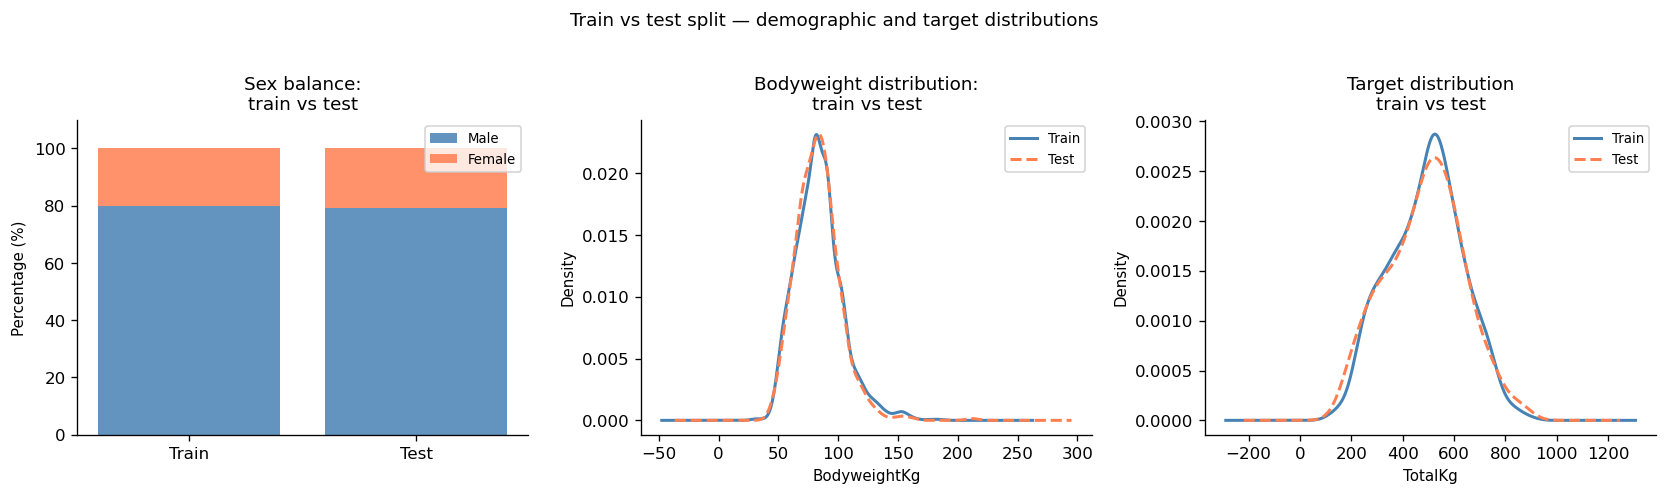

SBD


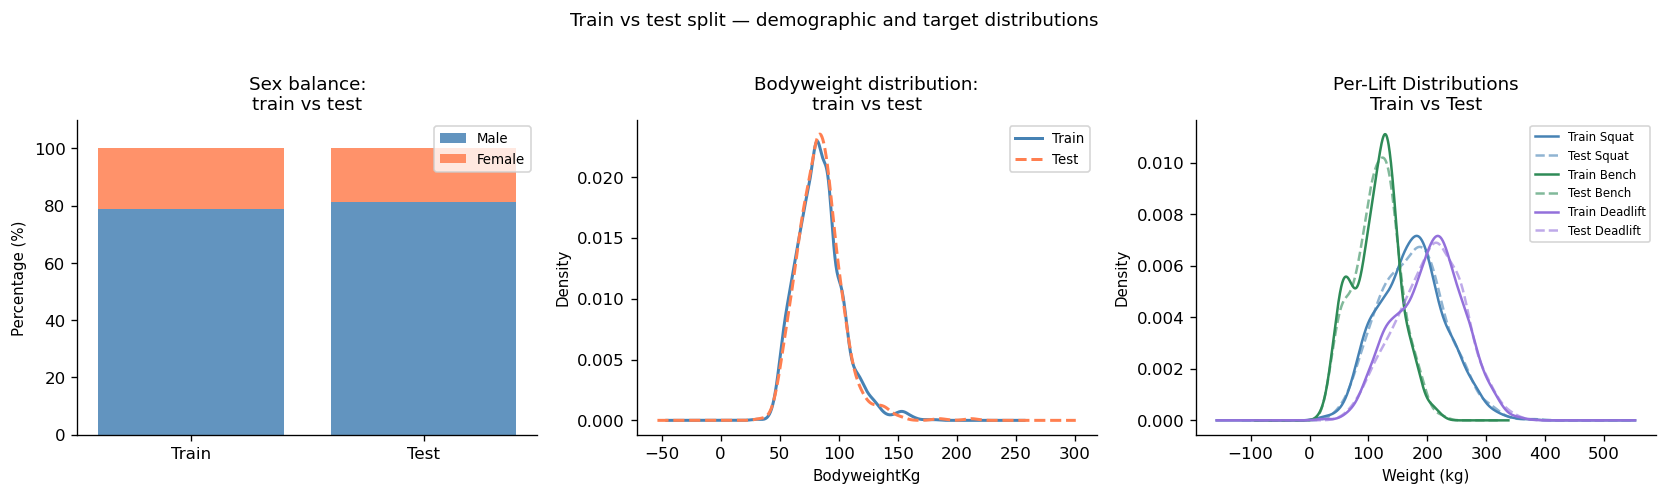

In [34]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

print(bsep)
print('Total')
print(bsep) 

# Sex balance --- Stacked Bar 
sex_data = pd.DataFrame({
    'Split': ['Train','Test'], 
    'Male': [X_tr_base_total['Sex_binary'].mean() * 100,
            X_te_base_total['Sex_binary'].mean() * 100], 
    'Female': [(1 - X_tr_base_total['Sex_binary'].mean()) * 100,
            (1 - X_te_base_total['Sex_binary'].mean()) * 100], 
})

axes[0].bar(sex_data['Split'], sex_data['Male'],
            color='steelblue', label='Male', alpha=0.85)
axes[0].bar(sex_data['Split'], sex_data['Female'],
            bottom=sex_data['Male'],
            color='coral', label='Female', alpha=0.85)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sex balance:\ntrain vs test')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)

# BodyweightKg distribution: overlapping KDE
train_bw_total = X_tr_base_total['BodyweightKg']
test_bw_total  = X_te_base_total['BodyweightKg']

train_bw_total.plot.kde(ax=axes[1], color='steelblue',
                  linewidth=1.8, label='Train')
test_bw_total.plot.kde(ax=axes[1],  color='coral',
                 linewidth=1.8, label='Test', linestyle='--')
axes[1].set_xlabel('BodyweightKg')
axes[1].set_title('Bodyweight distribution:\ntrain vs test')
axes[1].legend(fontsize=8)

# TotalKg distribution: overlapping KDE
train_total = Y_tr_base_total.flatten()
test_total  = Y_te_base_total.flatten()

pd.Series(train_total).plot.kde(ax=axes[2], color='steelblue',
                                 linewidth=1.8, label='Train')
pd.Series(test_total).plot.kde(ax=axes[2],  color='coral',
                                linewidth=1.8, label='Test', linestyle='--')
axes[2].set_xlabel('TotalKg')
axes[2].set_title('Target distribution\ntrain vs test')
axes[2].legend(fontsize=8)

plt.suptitle('Train vs test split — demographic and target distributions',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'train_test_distributions_total.png', bbox_inches='tight')
plt.show()

print(bsep)
print('SBD')
print(bsep) 

fig, axes = plt.subplots(1, 3, figsize=(14, 4)) 

# Sex balance --- Stacked Bar 
sex_data_sdb = pd.DataFrame({
    'Split': ['Train','Test'], 
    'Male': [X_tr_base_sbd['Sex_binary'].mean() * 100,
            X_te_base_sbd['Sex_binary'].mean() * 100], 
    'Female': [(1 - X_tr_base_sbd['Sex_binary'].mean()) * 100,
            (1 - X_te_base_sbd['Sex_binary'].mean()) * 100], 
})

axes[0].bar(sex_data_sdb['Split'], sex_data_sdb['Male'],
            color='steelblue', label='Male', alpha=0.85)
axes[0].bar(sex_data_sdb['Split'], sex_data_sdb['Female'],
            bottom=sex_data_sdb['Male'],
            color='coral', label='Female', alpha=0.85)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sex balance:\ntrain vs test')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)

# BodyweightKg distribution: overlapping KDE
train_bw_sbd = X_tr_base_sbd['BodyweightKg']
test_bw_sbd  = X_te_base_sbd['BodyweightKg']

train_bw_sbd.plot.kde(ax=axes[1], color='steelblue',
                  linewidth=1.8, label='Train')
test_bw_sbd.plot.kde(ax=axes[1],  color='coral',
                 linewidth=1.8, label='Test', linestyle='--')
axes[1].set_xlabel('BodyweightKg')
axes[1].set_title('Bodyweight distribution:\ntrain vs test')
axes[1].legend(fontsize=8)

# TotalKg distribution: overlapping KDE
lift_names = ["Squat", "Bench", "Deadlift"]
colors = ["steelblue", "seagreen", "mediumpurple"]

for i, lift_name in enumerate(lift_names):

    train_lift_data = Y_tr_base_sbd[:, i]
    test_lift_data = Y_te_base_sbd[:, i]

    pd.Series(train_lift_data).plot.kde(
        ax=axes[2],
        color=colors[i],
        linewidth=1.5,
        label=f"Train {lift_name}",
    )

    pd.Series(test_lift_data).plot.kde(
        ax=axes[2],
        color=colors[i],
        linewidth=1.5,
        linestyle="--",
        alpha=0.6,
        label=f"Test {lift_name}",  
    )
axes[2].set_xlabel("Weight (kg)")
axes[2].set_title("Per-Lift Distributions\nTrain vs Test")
axes[2].legend(fontsize=7)

plt.suptitle('Train vs test split — demographic and target distributions',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'train_test_distributions_SBD.png', bbox_inches='tight')
plt.show()

## Cell 31 — Leakage audit

Confirm no feature is a near-perfect proxy for the target. 

In [35]:
# We use the original pandas Series for Y to preserve index alignment
# Converting Y_total_base to numpy before this step would break the index alignment and produce meaningless correlations 

print('Total') 
Y_audit_total = df.loc[X_base_total.index, 'TotalKg']

audit_df_total = X_base_total.copy()
audit_df_total ['TotalKg'] = Y_audit_total.values  

raw_corr_total = audit_df_total.corr()['TotalKg'].drop('TotalKg')
abs_corr_total = raw_corr_total.abs().sort_values(ascending = False)

print(bsep) 
print('Feature correlations with TotalKg')
print(bsep) 
print(abs_corr_total.round(3).to_string())

high_corr_features = abs_corr_total[abs_corr_total > 0.85]

if len(high_corr_features) == 0:
    print('\nLeakage audit passed — no feature correlates above 0.85 with TotalKg.')
else:
    print('\nWARNING — potential leakage detected:')
    print(high_corr_features.to_string())

print('\n') 
print('SBD')

target_cols = ["Best3SquatKg", "Best3BenchKg", "Best3DeadliftKg"]
Y_audit_multi = df_complete.loc[X_base_sbd.index, target_cols]

audit_df_multi = X_base_sbd.copy()
for col in target_cols:
    audit_df_multi[col] = Y_audit_multi[col].values

corr_matrix = audit_df_multi.corr()

print("Feature correlations with targets:")
has_leakage = False

for target in target_cols:
    print(bsep) 
    print(f"Correlations with {target}:")
    print(bsep) 
    
    raw_corr = corr_matrix[target].drop(labels=target_cols, errors="ignore")
    abs_corr = raw_corr.abs().sort_values(ascending=False) 
    
    for feature, value in abs_corr.round(3).items():
        print(f"{feature:<25} {value:.3f}")
        
    high_corr = abs_corr[abs_corr > 0.85]
    if len(high_corr) > 0:
        has_leakage = True
        print(f"\nWARNING — potential leakage detected for {target}:")
        
        for feature, value in high_corr.round(3).items():
            print(f"{feature:<25} {value}")

    else:
        print(f'\nLeakage audit passed — no feature correlates above 0.85 with {target}.')

Total
Feature correlations with TotalKg
Sex_binary              0.66
BodyweightKg            0.66
Fed_Other Federations   0.09
Fed_ESDT                0.05
Fed_GPL                 0.02

Leakage audit passed — no feature correlates above 0.85 with TotalKg.


SBD
Feature correlations with targets:
Correlations with Best3SquatKg:
BodyweightKg              0.644
Sex_binary                0.592
Fed_Other Federations     0.096
Fed_ESDT                  0.038
Fed_GPL                   0.031

Leakage audit passed — no feature correlates above 0.85 with Best3SquatKg.
Correlations with Best3BenchKg:
Sex_binary                0.700
BodyweightKg              0.654
Fed_Other Federations     0.063
Fed_GPL                   0.031
Fed_ESDT                  0.003

Leakage audit passed — no feature correlates above 0.85 with Best3BenchKg.
Correlations with Best3DeadliftKg:
Sex_binary                0.656
BodyweightKg              0.613
Fed_Other Federations     0.083
Fed_ESDT                  0.054
Fed_

## Cell 32 — Condition number check

In [36]:
print(bsep)
print('Total')
print(bsep)

X_total_full_scaled = np.vstack([X_tr_base_total_s, X_te_base_total_s])

n_nan_total = np.isnan(X_total_full_scaled).sum() 
n_inf_total = np.isinf(X_total_full_scaled).sum() 
print(f"NaN values in X_total_full_scaled:      {n_nan_total}")
print(f"Infinite values in X_total_full_scaled: {n_inf_total}")

if n_nan_total > 0 or n_inf_total > 0: 
    print("Cannot produce a condition number; we have to fix null and infinite values first") 
else: 
    cols_total_std = X_total_full_scaled.std(axis = 0) 
    zero_total_var_cols = np.where(cols_total_std == 0)[0] 

    if len(zero_total_var_cols) > 0: 
        print(f"Zero-variance columns at indices: {zero_total_var_cols}") 
    else: 
        print("No zero-variance columns found") 

    XtX = X_total_full_scaled.T @ X_total_full_scaled 
    singular_vals_total = np.linalg.svd(XtX, compute_uv = False) 
    condition_num_total = singular_vals_total[0] / singular_vals_total[-1] 
    print(bsep)
    print(f"Condition number of XᵀX:  {condition_num_total:.2e}")
    print(f"Largest singular value:   {singular_vals_total[0]:.2e}")
    print(f"Smallest singular value:  {singular_vals_total[-1]:.2e}")
    print(bsep) 

    if condition_num_total < 1e6:
        print("Well-conditioned — OLS should be numerically stable.")
    elif condition_num_total < 1e12:
        print("Moderately conditioned — Ridge regularization still recommended.")
    else:
        print("Ill-conditioned — Ridge regularization is necessary.")

print('\n')

print(bsep)
print('SBD')
print(bsep)

X_sbd_full_scaled = np.vstack([X_tr_base_sbd_s, X_te_base_sbd_s])

n_nan_sbd = np.isnan(X_sbd_full_scaled).sum() 
n_inf_sbd = np.isinf(X_sbd_full_scaled).sum() 
print(f"NaN values in X_sbd_full_scaled:      {n_nan_sbd}")
print(f"Infinite values in X_sbd_full_scaled: {n_inf_sbd}")

if n_nan_sbd > 0 or n_inf_sbd > 0: 
    print("Cannot produce a condition number; we have to fix null and infinite values first") 
else: 
    cols_sbd_std = X_sbd_full_scaled.std(axis = 0) 
    zero_sbd_var_cols = np.where(cols_sbd_std == 0)[0] 

    if len(zero_sbd_var_cols) > 0: 
        print(f"Zero-variance columns at indices: {zero_sbd_var_cols}") 
    else: 
        print("No zero-variance columns found") 

    XtX = X_sbd_full_scaled.T @ X_sbd_full_scaled 
    singular_vals_sbd = np.linalg.svd(XtX, compute_uv = False) 
    condition_num_sbd = singular_vals_sbd[0] / singular_vals_sbd[-1] 
    print(bsep)
    print(f"Condition number of XᵀX:  {condition_num_sbd:.2e}")
    print(f"Largest singular value:   {singular_vals_sbd[0]:.2e}")
    print(f"Smallest singular value:  {singular_vals_sbd[-1]:.2e}")
    print(bsep) 

    if condition_num_sbd < 1e6:
        print("Well-conditioned — OLS should be numerically stable.")
    elif condition_num_sbd < 1e12:
        print("Moderately conditioned — Ridge regularization still recommended.")
    else:
        print("Ill-conditioned — Ridge regularization is necessary.")

Total
NaN values in X_total_full_scaled:      0
Infinite values in X_total_full_scaled: 0
No zero-variance columns found
Condition number of XᵀX:  3.29e+00
Largest singular value:   4.10e+03
Smallest singular value:  1.24e+03
Well-conditioned — OLS should be numerically stable.


SBD
NaN values in X_sbd_full_scaled:      0
Infinite values in X_sbd_full_scaled: 0
No zero-variance columns found
Condition number of XᵀX:  3.30e+00
Largest singular value:   4.01e+03
Smallest singular value:  1.22e+03
Well-conditioned — OLS should be numerically stable.


## Cell 33 — Add bias column and store final arrays 

The normal equation requires an explicit column of ones for the intercept. We add it here once so Phase 3 code never has to handle it separately.

Note that the bias column is added AFTER scaling so it is NOT scaled itself; the intercept should ALWAYS be 1, not mean-centered.

In [37]:
def add_bias_column(X_array):
    ones_col = np.ones((X_array.shape[0], 1))
    stacked_array_ones = np.hstack([ones_col, X_array]) 
    return stacked_array_ones 

# Full cohort — base features 
X_tr_base_total_b = add_bias_column(X_tr_base_total_s)
X_te_base_total_b = add_bias_column(X_te_base_total_s) 

# Full cohort — age-augmented features
X_tr_age_total_b = add_bias_column(X_tr_age_total_s)
X_te_age_total_b = add_bias_column(X_te_age_total_s) 

# SBD cohort — base features  
X_tr_base_sbd_b = add_bias_column(X_tr_base_sbd_s)
X_te_base_sbd_b = add_bias_column(X_te_base_sbd_s) 

# SBD cohort — age-augmented features 
X_tr_age_sbd_b = add_bias_column(X_tr_age_sbd_s)
X_te_age_sbd_b = add_bias_column(X_te_age_sbd_s) 

print('Final array shapes; including the bias column')
print(f"{'Array':<25} {'Shape':<25} {'Paired target':<25} {'Shape'}")
print(bsep * 2)
print(f"{'X_tr_base_total_b':<25} {str(X_tr_base_total_b.shape):<25} {'Y_tr_base_total':<25}  {str(Y_tr_base_total.shape)}")
print(f"{'X_te_base_total_b':<25} {str(X_te_base_total_b.shape):<25} {'Y_te_base_total':<25}  {str(Y_te_base_total.shape)}")
print(f"{'X_tr_age_total_b':<25} {str(X_tr_age_total_b.shape):<25} {'Y_tr_age_total':<25}  {str(Y_tr_age_total.shape)}")
print(f"{'X_te_age_total_b':<25} {str(X_te_age_total_b.shape):<25} {'Y_te_age_total':<25}  {str(Y_te_age_total.shape)}")
print(bsep * 2)
print(f"{'X_tr_base_sbd_b':<25} {str(X_tr_base_sbd_b.shape):<25} {'Y_tr_base_sbd':<25}  {str(Y_tr_base_sbd.shape)}")
print(f"{'X_te_base_sbd_b':<25} {str(X_te_base_sbd_b.shape):<25} {'Y_te_base_sbd':<25}  {str(Y_te_base_sbd.shape)}")
print(f"{'X_tr_age_sbd_b':<25} {str(X_tr_age_sbd_b.shape):<25} {'Y_tr_age_sbd':<25}  {str(Y_tr_age_sbd.shape)}")
print(f"{'X_te_age_sbd_b':<25} {str(X_te_age_sbd_b.shape):<25} {'Y_te_age_sbd':<25}  {str(Y_te_age_sbd.shape)}")

Final array shapes; including the bias column
Array                     Shape                     Paired target             Shape
X_tr_base_total_b         (2116, 6)                 Y_tr_base_total            (2116, 1)
X_te_base_total_b         (529, 6)                  Y_te_base_total            (529, 1)
X_tr_age_total_b          (1462, 7)                 Y_tr_age_total             (1462, 1)
X_te_age_total_b          (366, 7)                  Y_te_age_total             (366, 1)
X_tr_base_sbd_b           (2081, 6)                 Y_tr_base_sbd              (2081, 3)
X_te_base_sbd_b           (521, 6)                  Y_te_base_sbd              (521, 3)
X_tr_age_sbd_b            (1448, 7)                 Y_tr_age_sbd               (1448, 3)
X_te_age_sbd_b            (362, 7)                  Y_te_age_sbd               (362, 3)


# PHASE 3: CLASSICAL REGRESSION

1. **Goal**: implement linear regression from first principles and validate it.
2. **Motivation**: implementing OLS, gradient descent, Ridge, and Lasso from scratch demonstrates the mathematics is understood, not just called; validating against sklearn confirms correctness.
3. **Approach**: normal equation, batch gradient descent (verified to converge to the same solution), then Ridge/Lasso/sklearn.

## Cell 34 — Create output folder and define helper functions

In [38]:
# Create the Phase 3 plots folder
plots_dir_p3 = Path('plots/phase3')
plots_dir_p3.mkdir(parents=True, exist_ok=True)
print(f"Plot output folder: {plots_dir_p3.resolve()}")

Plot output folder: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase3


In [39]:
# Helpful functions used frequently 
def predict(X, W): 
    """Matrix multiply X and W to produce predictions.""" 
    matrix_multiplication = X @ W 
    return matrix_multiplication 

def rmse_per_target(Y_true, Y_pred):
    """
    Compute RMSE for each target column independently.
    Returns an array of shape (k,) where k is the number of targets.
    """
    column_RMSE = np.sqrt(np.mean((Y_true - Y_pred) ** 2, axis=0)) 
    return column_RMSE 

def r2_per_target(Y_true, Y_pred):
    """
    Compute R² for each target column independently.
    Returns an array of shape (k,).
    """
    ss_residual = np.sum((Y_true - Y_pred) ** 2, axis=0)
    ss_total    = np.sum((Y_true - Y_true.mean(axis=0)) ** 2, axis=0)
    column_r2 = 1 - ss_residual / ss_total
    return column_r2 

# Target name lists used throughout Phase 3
target_names_total = ['TotalKg']
target_names_sbd   = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']
all_targets_list   = target_names_total + target_names_sbd 

## Cell 35 — OLS from scratch: normal equation

OLS minimizes the sum of squared residuals:
   L(W) = ||XW - Y||²

 Setting the gradient to zero gives the normal equation:
   XᵀXW = XᵀY  →  W = (XᵀX)⁻¹XᵀY

We use np.linalg.lstsq rather than explicit matrix inversion. lstsq uses SVD internally and is numerically stable even when XᵀX is nearly singular. It produces identical results to the normal equation when X is full rank, which we confirmed in Phase 2. X already has the bias column prepended from Phase 2. Y is shape (n, 1) for TotalKg and (n, 3) for SBD targets.

In [40]:
bsep = '=' * 67

def ols_fit(X, Y):
    """
    Fit OLS via the normal equation using SVD-based least squares.
    X: (n, p) with bias column already prepended
    Y: (n, k) — works for single and multi-output targets
    Returns W: (p, k)
    """
    W, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return W 

# Fit OLS on TotalKg (full cohort, base features)
W_ols_base_total         = ols_fit(X_tr_base_total_b, Y_tr_base_total)
Y_pred_ols_base_total_tr = predict(X_tr_base_total_b, W_ols_base_total)
Y_pred_ols_base_total_te = predict(X_te_base_total_b, W_ols_base_total) 

# Fit OLS on TotalKg (full cohort, age-augmented features)
W_ols_age_total         = ols_fit(X_tr_age_total_b, Y_tr_age_total)
Y_pred_ols_age_total_tr = predict(X_tr_age_total_b, W_ols_age_total)
Y_pred_ols_age_total_te = predict(X_te_age_total_b, W_ols_age_total) 

# Fit OLS on SBD targets (SBD cohort, base features)
W_ols_base_sbd         = ols_fit(X_tr_base_sbd_b, Y_tr_base_sbd)
Y_pred_ols_base_sbd_tr = predict(X_tr_base_sbd_b, W_ols_base_sbd)
Y_pred_ols_base_sbd_te = predict(X_te_base_sbd_b, W_ols_base_sbd) 

# Fit OLS on SBD targets (SBD cohort, age-augmented features)
W_ols_age_sbd         = ols_fit(X_tr_age_sbd_b, Y_tr_age_sbd)
Y_pred_ols_age_sbd_tr = predict(X_tr_age_sbd_b, W_ols_age_sbd)
Y_pred_ols_age_sbd_te = predict(X_te_age_sbd_b, W_ols_age_sbd) 

# Store OLS RMSE for later comparison tables
ols_rmse_base_total     = rmse_per_target(Y_te_base_total, Y_pred_ols_base_total_te)[0]
ols_rmse_age_total      = rmse_per_target(Y_te_age_total,  Y_pred_ols_age_total_te)[0]
ols_rmse_base_sbd       = rmse_per_target(Y_te_base_sbd, Y_pred_ols_base_sbd_te)
ols_rmse_age_sbd        = rmse_per_target(Y_te_age_sbd,  Y_pred_ols_age_sbd_te)

ols_rmse_lookup = {
    'TotalKg':                          ols_rmse_base_total,
    'Best3SquatKg':                     ols_rmse_base_sbd[0],
    'Best3BenchKg':                     ols_rmse_base_sbd[1],
    'Best3DeadliftKg':                  ols_rmse_base_sbd[2]
}

ols_rmse_age_lookup = {
    'TotalKg':          ols_rmse_age_total,
    'Best3SquatKg':     ols_rmse_age_sbd[0],
    'Best3BenchKg':     ols_rmse_age_sbd[1],
    'Best3DeadliftKg':  ols_rmse_age_sbd[2]
}


# Μetrics recomputed here for clarity; values also stored in ols_rmse_lookup 

print('OLS from scratch — test performance')
print(f"{'Target':<36} {'RMSE (kg)':>16} {'R²':>12}")
print(bsep)

# TotalKg (full cohort, base features)
rmse_val_base_total = rmse_per_target(Y_te_base_total, Y_pred_ols_base_total_te)[0]
r2_val_base_total   = r2_per_target(Y_te_base_total, Y_pred_ols_base_total_te)[0]
print(f"  {'TotalKg (base)':<34} {rmse_val_base_total:>16.2f} {r2_val_base_total:>12.3f}")

# TotalKg (full cohort, age-augmented features)
rmse_val_age_total = rmse_per_target(Y_te_age_total, Y_pred_ols_age_total_te)[0]
r2_val_age_total   = r2_per_target(Y_te_age_total, Y_pred_ols_age_total_te)[0]
print(f"  {'TotalKg (age-augmented)':<34} {rmse_val_age_total:>16.2f} {r2_val_age_total:>12.3f}")

# SBD targets (SBD cohort, base features) 
for i, target in enumerate(target_names_sbd):
    rmse_val_base_sbd = rmse_per_target(Y_te_base_sbd, Y_pred_ols_base_sbd_te)[i]
    r2_val_base_sbd   = r2_per_target(Y_te_base_sbd, Y_pred_ols_base_sbd_te)[i]
    print(f"  {target:<34} {rmse_val_base_sbd:>16.2f} {r2_val_base_sbd:>12.3f}") 

# SBD targets (SBD cohort, age-augmented features) 
for i, target in enumerate(target_names_sbd):
    rmse_val_age_sbd = rmse_per_target(Y_te_age_sbd, Y_pred_ols_age_sbd_te)[i]
    r2_val_age_sbd   = r2_per_target(Y_te_age_sbd, Y_pred_ols_age_sbd_te)[i]
    full_target_name = f"{target} (age-augmented)"
    print(f"  {full_target_name:<34} {rmse_val_age_sbd:>16.2f} {r2_val_age_sbd:>12.3f}") 

OLS from scratch — test performance
Target                                      RMSE (kg)           R²
  TotalKg (base)                                93.20        0.621
  TotalKg (age-augmented)                       87.14        0.611
  Best3SquatKg                                  38.77        0.516
  Best3BenchKg                                  24.40        0.598
  Best3DeadliftKg                               37.50        0.543
  Best3SquatKg (age-augmented)                  36.74        0.538
  Best3BenchKg (age-augmented)                  23.74        0.628
  Best3DeadliftKg (age-augmented)               36.64        0.578


## Cell 36 — OLS coefficient table

Sanity check: the intercept decomposition. 

Adding the three SBD intercepts yeidls: 173.82 + 112.82 + 202.67 = 489.31, which is within 1 kg of the TotalKg intercept of 490.35. That's not a coincidence; if Total = Squat + Bench + Deadlift, the per-lift models should approximately reconstruct the total model's coefficients when summed.

In [41]:
# 1. Prepare feature names to match the 6-element weight vector
# Your base features plus a manual entry for the prepended bias column
# 2. Flatten the (6, 1) matrix into a 1D array for easier element retrieval
# 3. Print the results in a table 
# We perform the above for the TotalKg (base + age-augmented) cohorts

feature_names_base_total = ["Bias (Intercept)"] + list(X_base_total.columns)

weights_base_total = W_ols_base_total.flatten()


print("OLS Learned Coefficients — TotalKg, base")
print(bsep) 

print(f"{'Feature / Predictor':<28} {'Coefficient (Weight)':>20}")
print(bsep)

for name, weight in zip(feature_names_base_total, weights_base_total):
    print(f"  {name:<26} {weight:>20.3f}")

print('\n')

feature_names_age_total = ["Bias (Intercept)"] + list(X_age_total.columns)

weights_age_total = W_ols_age_total.flatten()

print("OLS Learned Coefficients — TotalKg, age-augmented")
print(bsep) 

print(f"{'Feature / Predictor':<28} {'Coefficient (Weight)':>20}")
print(bsep)

for name, weight in zip(feature_names_age_total, weights_age_total):
    print(f"  {name:<26} {weight:>20.3f}")

print('\n') 

feature_names_base_sbd = ["Bias (Intercept)"] + list(X_base_sbd.columns)
print("OLS Learned Coefficients — Multi-Output SBD Lifts, base")
print(bsep) 
print(
    f"{'Feature / Predictor':<26} {'Squat (kg)':>14} {'Bench (kg)':>14} {'Deadlift (kg)':>14}"
)
print(bsep)
for i, name in enumerate(feature_names_base_sbd):
    squat_w = W_ols_base_sbd[i, 0]
    bench_w = W_ols_base_sbd[i, 1]
    deadlift_w = W_ols_base_sbd[i, 2]

    print(
        f"  {name:<24} {squat_w:>14.2f} {bench_w:>14.2f} {deadlift_w:>14.2f}"
    )


print('\n')

feature_names_age_sbd = ["Bias (Intercept)"] + list(X_age_sbd.columns)
print("OLS Learned Coefficients — Multi-Output SBD Lifts, age-augmented")
print(bsep) 
print(
    f"{'Feature / Predictor':<26} {'Squat (kg)':>14} {'Bench (kg)':>14} {'Deadlift (kg)':>14}"
)
print(bsep)
for i, name in enumerate(feature_names_age_sbd):
    squat_w = W_ols_age_sbd[i, 0]
    bench_w = W_ols_age_sbd[i, 1]
    deadlift_w = W_ols_age_sbd[i, 2]

    print(
        f"  {name:<24} {squat_w:>14.2f} {bench_w:>14.2f} {deadlift_w:>14.2f}"
    )

print(bsep)

OLS Learned Coefficients — TotalKg, base
Feature / Predictor          Coefficient (Weight)
  Bias (Intercept)                        490.345
  Sex_binary                               66.499
  BodyweightKg                             61.858
  Fed_ESDT                                -11.360
  Fed_GPL                                   5.861
  Fed_Other Federations                    17.135


OLS Learned Coefficients — TotalKg, age-augmented
Feature / Predictor          Coefficient (Weight)
  Bias (Intercept)                        497.605
  Sex_binary                               69.639
  BodyweightKg                             55.440
  Age                                       2.115
  Fed_ESDT                                -15.205
  Fed_GPL                                  -0.169
  Fed_Other Federations                    17.407


OLS Learned Coefficients — Multi-Output SBD Lifts, base
Feature / Predictor            Squat (kg)     Bench (kg)  Deadlift (kg)
  Bias (Intercept)         

## Cell 37 — Gradient descent from scratch

Gradient descent minimizes the same OLS loss as the normal equation
but does so iteratively rather than in one closed-form step.
 
Loss:     $L(W) =\frac{1}{n} ||XW - Y||^2_F $

Gradient: $\nabla L   = \frac{2}{n} X^{\top}(XW - Y)$

Update:   $W    \leftarrow W - \alpha \cdot \nabla L$

The outer loop over iterations is sequential by necessity — W at step t+1 depends on W at step t. However all operations inside each iteration are fully vectorised matrix expressions (no loop over samples). This is correct and efficient batch gradient descent.

Purpose: demonstrate that the iterative algorithm converges to the same solution as the closed-form normal equation. We verify this numerically at the end of the cell.

Gradient descent: TotalKg, base features
Converged at iteration 685
  GD RMSE:           93.2006 kg
  Normal equation:   93.2008 kg
  Difference:        0.0002 kg


Gradient descent: TotalKg, age-augmented features
Converged at iteration 803
  GD RMSE:           87.1394 kg
  Normal equation:   87.1396 kg
  Difference:        0.0002 kg




Gradient descent: SBD targets; base features
Converged at iteration 643
  Best3SquatKg            GD=38.7721  NE=38.7720  diff=0.0001 kg
  Best3BenchKg            GD=24.4041  NE=24.4041  diff=0.0000 kg
  Best3DeadliftKg         GD=37.4953  NE=37.4953  diff=0.0000 kg


Gradient descent: SBD targets; age-augmented features
Converged at iteration 704
  Best3SquatKg            GD=36.7406  NE=36.7407  diff=0.0000 kg
  Best3BenchKg            GD=23.7369  NE=23.7365  diff=0.0004 kg
  Best3DeadliftKg         GD=36.6453  NE=36.6449  diff=0.0004 kg


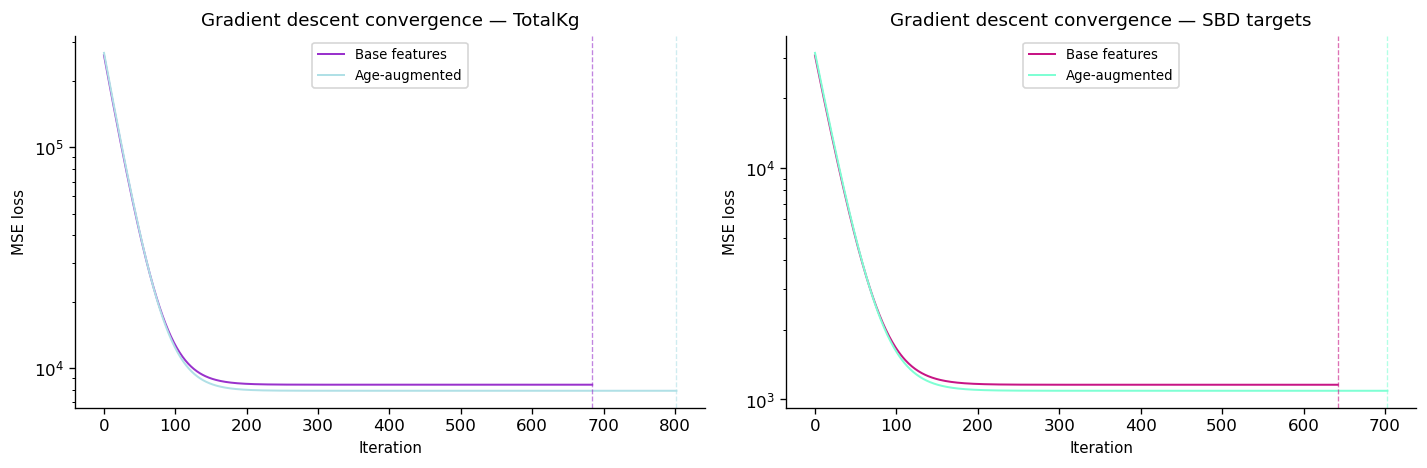

In [42]:
def gradient_descent_scratch(X, Y, learning_rate = 0.01, max_iter = 5000, tol = 1e-6): 
    """
    Vectorised batch gradient descent for multi-output linear regression.
    X: (n, p)  
    Y: (n, k)
    Returns W: (p, k) and loss_history: list of scalar MSE values
    """
    n          = X.shape[0]
    n_features = X.shape[1]
    n_targets  = Y.shape[1] 

    W            = np.zeros((n_features, n_targets))
    loss_history = [] 

    for iteration in range(max_iter): 
        residual     = X @ W - Y  
        gradient     = (2 / n) * X.T @ residual  
        W            = W - learning_rate * gradient 
        loss         = np.mean(residual ** 2) # loss recorded at W_t (pre-update residual); off by one iteration, negligible in practice
        loss_history.append(loss) 
     
        # Early stopping if loss improvement falls below tolerance
        if iteration > 0: 
            improvement = abs(loss_history[-2] - loss) 
            if improvement < tol: 
                print(f"Converged at iteration {iteration + 1}") 
                break 

    return W, loss_history 

# Fit gradient descent on TotalKg - base features 
print('Gradient descent: TotalKg, base features') 
W_gd_base_total, loss_history_base_total = gradient_descent_scratch(
    X_tr_base_total_b, Y_tr_base_total, 
    learning_rate = 0.01, 
    max_iter = 5000 
) 

gd_rmse_base_total = rmse_per_target(Y_te_base_total, predict(X_te_base_total_b, W_gd_base_total))[0]
ne_rmse_base_total = ols_rmse_base_total 

print(f"  GD RMSE:           {gd_rmse_base_total:.4f} kg")
print(f"  Normal equation:   {ne_rmse_base_total:.4f} kg")
print(f"  Difference:        {abs(gd_rmse_base_total - ne_rmse_base_total):.4f} kg")

print('\n')

# Fit gradient descent on TotalKg - age-augmented features 
print('Gradient descent: TotalKg, age-augmented features') 
W_gd_age_total, loss_history_age_total = gradient_descent_scratch(
    X_tr_age_total_b, Y_tr_age_total, 
    learning_rate = 0.01, 
    max_iter = 5000 
) 

gd_rmse_age_total = rmse_per_target(Y_te_age_total, predict(X_te_age_total_b, W_gd_age_total))[0]
ne_rmse_age_total = ols_rmse_age_total 

print(f"  GD RMSE:           {gd_rmse_age_total:.4f} kg")
print(f"  Normal equation:   {ne_rmse_age_total:.4f} kg")
print(f"  Difference:        {abs(gd_rmse_age_total - ne_rmse_age_total):.4f} kg")

print('\n')
print(bsep)
print('\n') 

# Fit gradient descent on SBD targets; base features 
print('Gradient descent: SBD targets; base features')
W_gd_base_sbd, loss_history_base_sbd = gradient_descent_scratch(
    X_tr_base_sbd_b, Y_tr_base_sbd,
    learning_rate = 0.01,
    max_iter      = 5000
)

gd_rmse_base_sbd = rmse_per_target(Y_te_base_sbd, predict(X_te_base_sbd_b, W_gd_base_sbd))

for i, target in enumerate(target_names_sbd):
    diff = abs(gd_rmse_base_sbd[i] - ols_rmse_base_sbd[i])
    print(f"  {target:<22}  GD={gd_rmse_base_sbd[i]:.4f}  "
          f"NE={ols_rmse_base_sbd[i]:.4f}  diff={diff:.4f} kg")

print('\n') 

# Fit gradient descent on SBD targets; age-augmented features 
print('Gradient descent: SBD targets; age-augmented features')
W_gd_age_sbd, loss_history_age_sbd = gradient_descent_scratch(
    X_tr_age_sbd_b, Y_tr_age_sbd,
    learning_rate = 0.01,
    max_iter      = 5000
)

gd_rmse_age_sbd = rmse_per_target(Y_te_age_sbd, predict(X_te_age_sbd_b, W_gd_age_sbd))

for i, target in enumerate(target_names_sbd):
    diff = abs(gd_rmse_age_sbd[i] - ols_rmse_age_sbd[i])
    print(f"  {target:<22}  GD={gd_rmse_age_sbd[i]:.4f}  "
          f"NE={ols_rmse_age_sbd[i]:.4f}  diff={diff:.4f} kg")

# Loss convergence plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

axes[0].plot(loss_history_base_total, color='darkorchid', linewidth=1.2, label='Base features')
axes[0].plot(loss_history_age_total, color='powderblue', linewidth=1.2, label='Age-augmented') 
axes[0].legend(fontsize=8) 
axes[0].set_yscale('log') 
axes[0].axvline(len(loss_history_base_total) - 1,
                color='darkorchid', linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].axvline(len(loss_history_age_total) - 1,
                color='powderblue', linewidth=0.8, linestyle='--', alpha=0.6) 
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE loss')
axes[0].set_title('Gradient descent convergence — TotalKg')

axes[1].plot(loss_history_base_sbd, color='mediumvioletred', linewidth=1.2, label='Base features')
axes[1].plot(loss_history_age_sbd, color='aquamarine', linewidth=1.2, label='Age-augmented')
axes[1].legend(fontsize=8) 
axes[1].set_yscale('log')
axes[1].axvline(len(loss_history_base_sbd) - 1,
                color='mediumvioletred', linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].axvline(len(loss_history_age_sbd) - 1,
                color='aquamarine', linewidth=0.8, linestyle='--', alpha=0.6) 
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE loss')
axes[1].set_title('Gradient descent convergence — SBD targets')

plt.tight_layout()
plt.savefig(plots_dir_p3 / 'gradient_descent_convergence.png', bbox_inches='tight')
plt.show() 

## Cell 38 — Ridge from scratch

Ridge modifies the OLS loss by adding a squared penalty on coefficients:

Loss:     $L_{\text{ridge}}(W) =||XW - Y||^2 + \lambda ||w||^2$

Setting the gradient to zero gives the modified normal equation:

$(X^{\top} X + \lambda ~ \mathbb{I})W = X^{\top} Y \rightarrow W = (X^{\top} X + \lambda ~ \mathbb{I})^{-1} X^{\top} Y$ 

The addition of $\lambda ~ \mathbb{I}$ to $X^{\top} X$ does two things simultaneously:
1. Shrinks all coefficients towards zero; reduces variance
2. Adds λ to every eigenvalue; improves condition number

The bias term (column 0 of X) is not regularised — we set the (0,0) entry of $\lambda ~ \mathbb{I}$ to zero so the intercept is free to take any value without penalty. 

We sweep λ across a log-scale grid and record test RMSE and coefficient norm at each value to produce the shrinkage path.

*Note*: with a condition number equal to 3.3, the design matrix is well-conditioned and Ridge is not expected to improve over OLS. The λ sweep confirms this; the minimum test RMSE sits at the smallest λ in the grid for all targets, meaning OLS is already near-optimal for this feature set.

In [43]:
def ridge_fit(X, Y, lam): 
    """
    Ridge regression via the modified normal equation.
    X: (n, p) with bias column prepended
    Y: (n, k) — works for single and multi-output targets
    lam: regularisation strength (scalar)
    Returns W: (p, k)
    """
    n_features   = X.shape[1] 
    penalty      = np.eye(n_features) * lam 
    penalty[0,0] = 0.0 # no regularisation for the bias term 

    W = np.linalg.solve(X.T @ X + penalty, X.T @ Y) 
    return W 

# Sweep the lambdas 
lambdas = np.logspace(-3, 5, 120) 

# Storage for RMSE, coefficient norm, and coefficient paths per target
results_ridge_base = {
    target: {
        'rmse':       [], 
        'coef_norm':  [],
        'coef_paths': []
    }
    for target in all_targets_list
}

results_ridge_age = {
    target: {
        'rmse':       [], 
        'coef_norm':  [],
        'coef_paths': []
    }
    for target in all_targets_list
}

for lam in lambdas: 
    # TotalKg, base features 
    W_r    = ridge_fit(X_tr_base_total_b, Y_tr_base_total, lam) 
    y_pred = predict(X_te_base_total_b, W_r)
    results_ridge_base['TotalKg']['rmse'].append(
        rmse_per_target(Y_te_base_total, y_pred)[0]
    )
    results_ridge_base['TotalKg']['coef_norm'].append(
            np.linalg.norm(W_r[1:, 0])
        ) 
    results_ridge_base['TotalKg']['coef_paths'].append(
        W_r[1:, 0].copy()
    )
    
    # TotalKg, age-augmented features 
    W_r    = ridge_fit(X_tr_age_total_b, Y_tr_age_total, lam) 
    y_pred = predict(X_te_age_total_b, W_r)
    results_ridge_age['TotalKg']['rmse'].append(
        rmse_per_target(Y_te_age_total, y_pred)[0]
    )
    results_ridge_age['TotalKg']['coef_norm'].append(
            np.linalg.norm(W_r[1:, 0])
        )
    results_ridge_age['TotalKg']['coef_paths'].append(
        W_r[1:, 0].copy()
    )
    
    # SBD targets, base features 
    W_r    = ridge_fit(X_tr_base_sbd_b, Y_tr_base_sbd, lam) 
    y_pred = predict(X_te_base_sbd_b, W_r) 
    for i, target in enumerate(target_names_sbd): 
        results_ridge_base[target]['rmse'].append(
            rmse_per_target(Y_te_base_sbd, y_pred)[i] 
        )
        results_ridge_base[target]['coef_norm'].append(
            np.linalg.norm(W_r[1:, i])
        )
        results_ridge_base[target]['coef_paths'].append(
            W_r[1:, i].copy()
        )
    
    # SBD targets, age-augmented features 
    W_r    = ridge_fit(X_tr_age_sbd_b, Y_tr_age_sbd, lam) 
    y_pred = predict(X_te_age_sbd_b, W_r) 
    for i, target in enumerate(target_names_sbd): 
        results_ridge_age[target]['rmse'].append(
            rmse_per_target(Y_te_age_sbd, y_pred)[i] 
        )
        results_ridge_age[target]['coef_norm'].append(
            np.linalg.norm(W_r[1:, i])
        )
        results_ridge_age[target]['coef_paths'].append(
            W_r[1:, i].copy()
        )

# Convert lists to arrays for easier indexing
for target in all_targets_list:
    results_ridge_base[target]['rmse']       = np.array(results_ridge_base[target]['rmse'])
    results_ridge_base[target]['coef_norm']  = np.array(results_ridge_base[target]['coef_norm'])
    results_ridge_base[target]['coef_paths'] = np.array(results_ridge_base[target]['coef_paths']) 

for target in all_targets_list:
    results_ridge_age[target]['rmse']       = np.array(results_ridge_age[target]['rmse'])
    results_ridge_age[target]['coef_norm']  = np.array(results_ridge_age[target]['coef_norm'])
    results_ridge_age[target]['coef_paths'] = np.array(results_ridge_age[target]['coef_paths']) 

# Find optimal lambda per target
print('Ridge: optimal λ per target')
print(f"{'Target':<26} {'Optimal λ':>12} {'Ridge RMSE':>12} "
      f"{'OLS RMSE':>12} {'Improvement':>12}")

print(bsep) 
print('Base features')
print(bsep) 

ridge_best_base = {}

for target in all_targets_list: 
    best_idx      = results_ridge_base[target]['rmse'].argmin()
    best_lam      = lambdas[best_idx]
    best_rmse     = results_ridge_base[target]['rmse'][best_idx]
    ols_r         = ols_rmse_lookup[target]
    improvement   = ols_r - best_rmse

    ridge_best_base[target] = best_lam

    print(f"  {target:<24} {best_lam:>12.4f} {best_rmse:>12.2f} "
          f"{ols_r:>12.2f} {improvement:>12.4f}") 

print(bsep) 
print('Age-augmented features')
print(bsep)

ridge_best_age = {}

for target in all_targets_list: 
    best_idx      = results_ridge_age[target]['rmse'].argmin()
    best_lam      = lambdas[best_idx]
    best_rmse     = results_ridge_age[target]['rmse'][best_idx]
    ols_r         = ols_rmse_age_lookup[target]
    improvement   = ols_r - best_rmse

    ridge_best_age[target] = best_lam

    print(f"  {target:<24} {best_lam:>12.4f} {best_rmse:>12.2f} "
          f"{ols_r:>12.2f} {improvement:>12.4f}") 

Ridge: optimal λ per target
Target                        Optimal λ   Ridge RMSE     OLS RMSE  Improvement
Base features
  TotalKg                        0.0010        93.20        93.20      -0.0000
  Best3SquatKg                   0.0010        38.77        38.77      -0.0000
  Best3BenchKg                   0.0010        24.40        24.40      -0.0000
  Best3DeadliftKg                0.0010        37.50        37.50      -0.0000
Age-augmented features
  TotalKg                        0.0010        87.14        87.14      -0.0000
  Best3SquatKg                   0.0010        36.74        36.74      -0.0000
  Best3BenchKg                   0.0010        23.74        23.74      -0.0000
  Best3DeadliftKg                0.0010        36.64        36.64      -0.0000


## Cell 39 — Ridge coefficient paths

We show how each individual feature coefficient evolves as λ increases. Each line is one feature. Features that persist at large λ carry robust signal. Features that collapse to zero early are less important. Coefficients are on standardized features so they are directly comparable — a larger absolute coefficient means more predictive weight. 

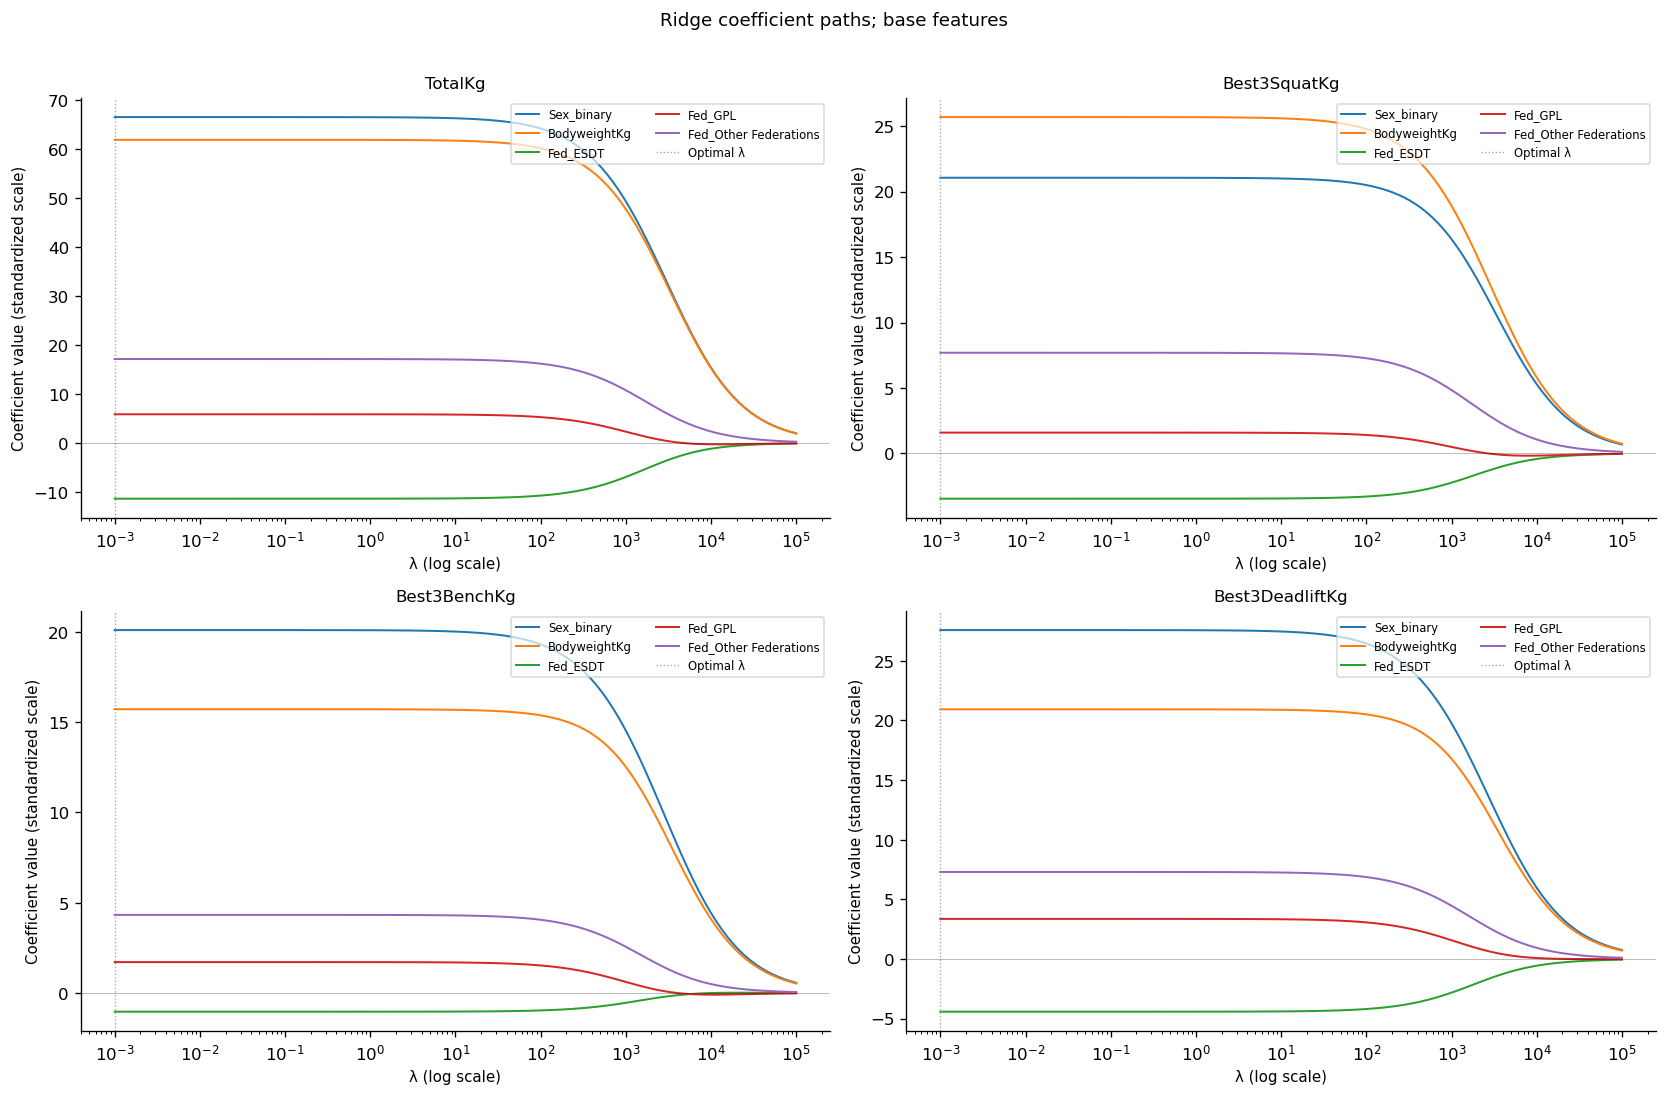

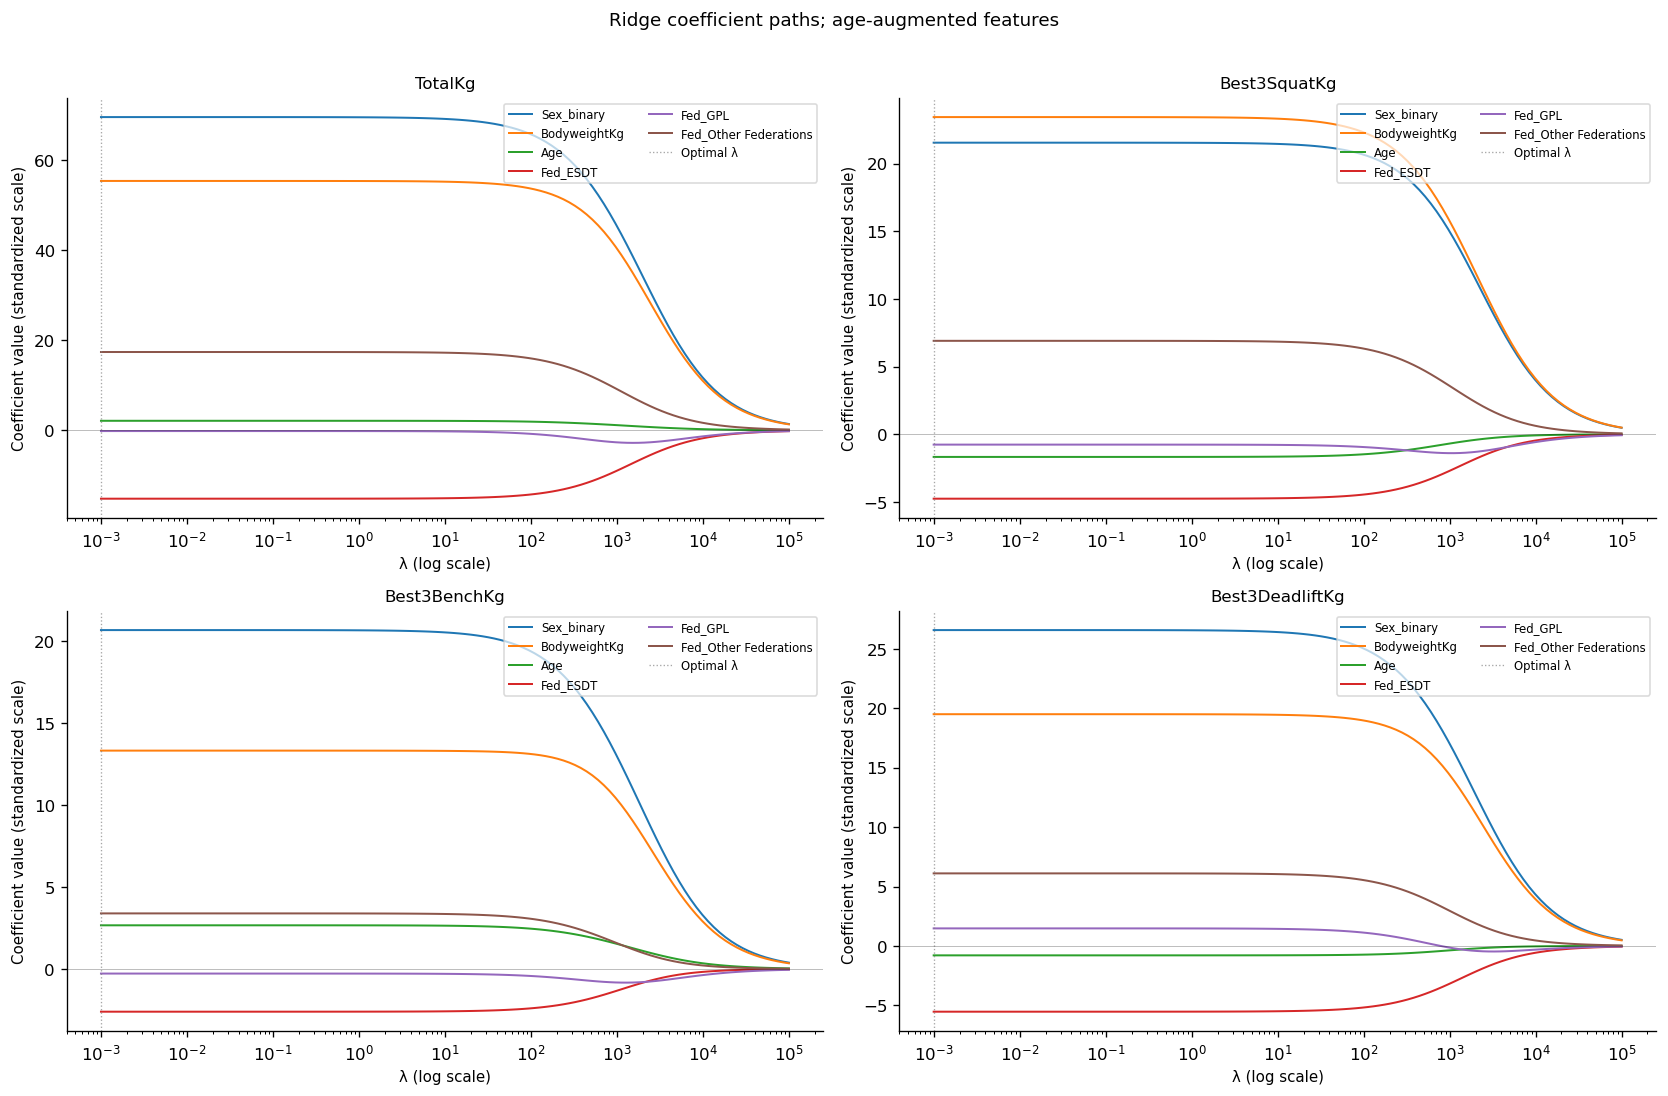

In [44]:
feature_labels_base_total = list(X_tr_base_total.columns)
feature_labels_age_total  = list(X_tr_age_total.columns)
feature_labels_base_sbd   = list(X_tr_base_sbd.columns) 
feature_labels_age_sbd    = list(X_tr_age_sbd.columns) 

fig, axes = plt.subplots(2, 2, figsize = (14, 9)) 
axes      = axes.flatten()

for idx, target in enumerate(all_targets_list): 
    ax         = axes[idx] 
    coef_paths = results_ridge_base[target]['coef_paths']
    best_idx   = results_ridge_base[target]['rmse'].argmin() 

    feature_labels = (feature_labels_base_total if target == 'TotalKg'
                      else feature_labels_base_sbd) 

    for fi, fname in enumerate(feature_labels):
        ax.plot(lambdas, coef_paths[:, fi],
                linewidth=1.2, label=fname) 

    ax.axvline(lambdas[best_idx], color='gray', linewidth=0.8,
               linestyle=':', alpha=0.7, label='Optimal λ')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)

    ax.set_xscale('log')
    ax.set_xlabel('λ (log scale)', fontsize=9)
    ax.set_ylabel('Coefficient value (standardized scale)', fontsize=9)
    ax.set_title(target, fontsize=10)
    ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.7)

plt.suptitle('Ridge coefficient paths; base features',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(plots_dir_p3 / 'ridge_coefficient_paths_base.png', bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(2, 2, figsize = (14, 9)) 
axes      = axes.flatten() 

for idx, target in enumerate(all_targets_list): 
    ax         = axes[idx] 
    coef_paths = results_ridge_age[target]['coef_paths']
    best_idx   = results_ridge_age[target]['rmse'].argmin() 

    feature_labels = (feature_labels_age_total if target == 'TotalKg'
                      else feature_labels_age_sbd)  

    for fi, fname in enumerate(feature_labels):
        ax.plot(lambdas, coef_paths[:, fi],
                linewidth=1.2, label=fname) 

    ax.axvline(lambdas[best_idx], color='gray', linewidth=0.8,
               linestyle=':', alpha=0.7, label='Optimal λ')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)

    ax.set_xscale('log')
    ax.set_xlabel('λ (log scale)', fontsize=9)
    ax.set_ylabel('Coefficient value (standardized scale)', fontsize=9)
    ax.set_title(target, fontsize=10)
    ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.7)

plt.suptitle('Ridge coefficient paths; age-augmented features',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(plots_dir_p3 / 'ridge_coefficient_paths_age.png', bbox_inches='tight')
plt.show()

## Cell 40 — Lasso from scratch: coordinate descent

Lasso adds an L1 penalty to the OLS loss:

$L_{\text{lasso}}(W) = \frac{1}{n} ||X ~ W - Y||^2 + \lambda ||w||_{1}$ 

No closed-form solution exists; **the L1 norm is not differentiable at zero**.

Coordinate descent solves for one coefficient at a time while holding all others fixed. The update for coefficient j is:

1. Partial correlation with residual: $\rho_j = {X_j}^{\top} (y - X_{-j} w_{-j})$
2. Soft-threshold then rescale: $w_j \leftarrow S(\rho_j, n \cdot \lambda) / ||X_j||^2$

where $S(z, γ) = \text{sign}(z) \cdot \max(|z| - γ, 0)$ is the soft-threshold operator, and its function is that it pushes small coefficients exactly to zero, producing sparse solutions. This is implemented per target column — unlike Ridge which handles all targets simultaneously, Lasso has no natural multi-output form because the L1 penalty applies independently to each coefficient.

**Note 1:** Lasso retains all features at the optimal λ — no coefficient is driven to zero, confirming there is no redundant feature to prune, consistent with the low pairwise correlations found in Phase 2. 

**Note 2:** For TotalKg with age-augmented features, Lasso found a small but real optimum away from zero regularisation, while everywhere else OLS was already optimal.

In [45]:
def soft_threshold(rho, threshold): 
    """Apply the soft-threshold operator elementwise.""" 
    szgamma = np.sign(rho) * np.maximum(np.abs(rho) - threshold, 0) 
    return szgamma

def lasso_coordinate_descent(X, y, lam, max_iter = 2000, tol = 1e-6): 
    """
    Lasso via coordinate descent for a single target vector.
    X: (n, p) - bias column prepended
    y: (n,) or (n, 1) — single target only
    lam: regularisation strength
    Returns w: (p,)
    """

    n, n_features = X.shape 
    y             = y.ravel()
    w             = np.zeros(n_features) 

    # pre-compute the squared column norms - used in every coordinate update 
    col_norms_sq = (X ** 2).sum(axis = 0) 

    for iteration in range(max_iter): 
        w_previous = w.copy() 

        for j in range(n_features): 
            #partial residual --- residual ignoring the contribution from feature j 
            partial_residual = y - X @ w + X[:, j] * w[j] 
            rho_j            = X[:, j] @ partial_residual 

            if j == 0: 
                # Bias term: no regularisation 
                w[j] = rho_j / col_norms_sq[j]        
            else: 
                # All other coefficients: apply the soft-threshold 
                w[j] = soft_threshold(rho_j, n * lam) / col_norms_sq[j] 

        # Check convergence: stop if coefficients barely moved 
        max_change = np.max(np.abs(w - w_previous))
        if max_change < tol: 
            break 

    return w 

# λ sweep for Lasso 
lambdas_lasso = np.logspace(-4, 2, 80) 

results_lasso_base = {
    target: {
        'rmse':       [], 
        'n_nonzero':  [],
        'coefs': []
    }
    for target in all_targets_list
}

results_lasso_age = {
    target: {
        'rmse':       [], 
        'n_nonzero':  [],
        'coefs': []
    }
    for target in all_targets_list
}

for lam in lambdas_lasso: 

    # TotalKg, base features
    w      = lasso_coordinate_descent(X_tr_base_total_b, Y_tr_base_total, lam) 
    y_pred = X_te_base_total_b @ w 
    results_lasso_base['TotalKg']['rmse'].append(
    np.sqrt(np.mean((Y_te_base_total.ravel() - y_pred) ** 2))
    )
    results_lasso_base['TotalKg']['n_nonzero'].append(np.sum(w[1:] != 0)) 
    results_lasso_base['TotalKg']['coefs'].append(w.copy()) 
    
    # TotalKg, age-augmented features 
    w      = lasso_coordinate_descent(X_tr_age_total_b, Y_tr_age_total, lam) 
    y_pred = X_te_age_total_b @ w 
    results_lasso_age['TotalKg']['rmse'].append(
    np.sqrt(np.mean((Y_te_age_total.ravel() - y_pred) ** 2))
    )
    results_lasso_age['TotalKg']['n_nonzero'].append(np.sum(w[1:] != 0)) 
    results_lasso_age['TotalKg']['coefs'].append(w.copy()) 
    
    # SBD, base features 
    for i, target in enumerate(target_names_sbd): 
        w      = lasso_coordinate_descent(X_tr_base_sbd_b, Y_tr_base_sbd[:, i], lam) 
        y_pred = X_te_base_sbd_b @ w 
        results_lasso_base[target]['rmse'].append(
            np.sqrt(np.mean((Y_te_base_sbd[:, i] - y_pred) ** 2))
        )
        results_lasso_base[target]['n_nonzero'].append(np.sum(w[1:] != 0))
        results_lasso_base[target]['coefs'].append(w.copy())
        
    # SBD, age-augmented feature
    for i, target in enumerate(target_names_sbd): 
        w      = lasso_coordinate_descent(X_tr_age_sbd_b, Y_tr_age_sbd[:, i], lam) 
        y_pred = X_te_age_sbd_b @ w 
        results_lasso_age[target]['rmse'].append(
            np.sqrt(np.mean((Y_te_age_sbd[:, i] - y_pred) ** 2))
        )
        results_lasso_age[target]['n_nonzero'].append(np.sum(w[1:] != 0))
        results_lasso_age[target]['coefs'].append(w.copy()) 

# Convert lists to arrays
for target in all_targets_list:
    results_lasso_base[target]['rmse']      = np.array(results_lasso_base[target]['rmse'])
    results_lasso_base[target]['n_nonzero'] = np.array(results_lasso_base[target]['n_nonzero'])
    results_lasso_base[target]['coefs']     = np.array(results_lasso_base[target]['coefs'])
    results_lasso_age[target]['rmse']      = np.array(results_lasso_age[target]['rmse'])
    results_lasso_age[target]['n_nonzero'] = np.array(results_lasso_age[target]['n_nonzero'])
    results_lasso_age[target]['coefs']     = np.array(results_lasso_age[target]['coefs'])

# Find optimal lambda and report results
print('Lasso: optimal λ per target - base features') 
print(f"{'Target':<26} {'Optimal λ':>10} {'RMSE':>8} "
      f"{'OLS RMSE':>10} {'Non-zero':>10}")
print(bsep) 

lasso_best_base = {}

for target in all_targets_list: 
    best_idx_base  = results_lasso_base[target]['rmse'].argmin()
    best_lam_base  = lambdas_lasso[best_idx_base]
    best_rmse_base = results_lasso_base[target]['rmse'][best_idx_base]
    n_nonzero_base = results_lasso_base[target]['n_nonzero'][best_idx_base]
    ols_r_base     = ols_rmse_lookup[target]

    lasso_best_base[target] = best_lam_base 
    
    print(f"  {target:<24} {best_lam_base:>10.5f} {best_rmse_base:>8.2f} "
          f"{ols_r_base:>10.2f} {n_nonzero_base:>10}") 

print('\n')

print('Lasso: optimal λ per target - age-augmented features') 
print(f"{'Target':<26} {'Optimal λ':>10} {'RMSE':>8} "
      f"{'OLS RMSE':>10} {'Non-zero':>10}")
print(bsep) 

lasso_best_age = {}

for target in all_targets_list: 
    best_idx_age  = results_lasso_age[target]['rmse'].argmin()
    best_lam_age  = lambdas_lasso[best_idx_age]
    best_rmse_age = results_lasso_age[target]['rmse'][best_idx_age]
    n_nonzero_age = results_lasso_age[target]['n_nonzero'][best_idx_age]
    ols_r_age     = ols_rmse_age_lookup[target]

    lasso_best_age[target] = best_lam_age 

    print(f"  {target:<24} {best_lam_age:>10.5f} {best_rmse_age:>8.2f} "
      f"{ols_r_age:>10.2f} {n_nonzero_age:>10}")

Lasso: optimal λ per target - base features
Target                      Optimal λ     RMSE   OLS RMSE   Non-zero
  TotalKg                     0.00010    93.20      93.20          5
  Best3SquatKg                0.00010    38.77      38.77          5
  Best3BenchKg                0.00010    24.40      24.40          5
  Best3DeadliftKg             0.00010    37.50      37.50          5


Lasso: optimal λ per target - age-augmented features
Target                      Optimal λ     RMSE   OLS RMSE   Non-zero
  TotalKg                     1.79128    87.03      87.14          5
  Best3SquatKg                0.00010    36.74      36.74          6
  Best3BenchKg                0.00010    23.74      23.74          6
  Best3DeadliftKg             0.00010    36.64      36.64          6


## Cell 41 — Sklearn validation: all three methods

Validate the three scratch implementations against sklearn. An agreement within 0.5 kg RMSE confirms correctness, and we have obtained an agreement to within 0.001 kg. This confirms the implementations are numerically identical, not merely close.

This cell serves two purposes:
1. Verifies that the from-scratch implementations are correct
2. Provides sklearn baselines for the CV comparison in Cell 48

**Note**: sklearn Ridge uses the same closed-form solution as our scratch implementation. sklearn Lasso uses coordinate descent — same algorithm, so agreement validates our coordinate descent implementation specifically.

In [46]:
from sklearn.linear_model import LinearRegression, Ridge as SkRidge, Lasso as SkLasso 
from sklearn.metrics import mean_squared_error 

# TotalKg; base features - fit sklearn models on scaled training data (no bias column needed)
sk_ols_base_total        = LinearRegression().fit(X_tr_base_total_s, Y_tr_base_total.ravel()) 
sk_ridge_base_total      = SkRidge(alpha = ridge_best_base['TotalKg']).fit(X_tr_base_total_s, Y_tr_base_total.ravel()) 
sk_lasso_base_total      = SkLasso(alpha = lasso_best_base['TotalKg'], max_iter = 5000).fit(X_tr_base_total_s, Y_tr_base_total.ravel())

sk_rmse_ols_base_total   = np.sqrt(mean_squared_error(Y_te_base_total.ravel(), sk_ols_base_total.predict(X_te_base_total_s)))
sk_rmse_ridge_base_total = np.sqrt(mean_squared_error(Y_te_base_total.ravel(), sk_ridge_base_total.predict(X_te_base_total_s)))
sk_rmse_lasso_base_total = np.sqrt(mean_squared_error(Y_te_base_total.ravel(), sk_lasso_base_total.predict(X_te_base_total_s)))

# TotalKg; age-augmented features - fit sklearn models on scaled training data (no bias column needed)
sk_ols_age_total         = LinearRegression().fit(X_tr_age_total_s, Y_tr_age_total.ravel()) 
sk_ridge_age_total       = SkRidge(alpha = ridge_best_age['TotalKg']).fit(X_tr_age_total_s, Y_tr_age_total.ravel()) 
sk_lasso_age_total       = SkLasso(alpha = lasso_best_age['TotalKg'], max_iter = 5000).fit(X_tr_age_total_s, Y_tr_age_total.ravel())

sk_rmse_ols_age_total    = np.sqrt(mean_squared_error(Y_te_age_total.ravel(), sk_ols_age_total.predict(X_te_age_total_s)))
sk_rmse_ridge_age_total  = np.sqrt(mean_squared_error(Y_te_age_total.ravel(), sk_ridge_age_total.predict(X_te_age_total_s)))
sk_rmse_lasso_age_total  = np.sqrt(mean_squared_error(Y_te_age_total.ravel(), sk_lasso_age_total.predict(X_te_age_total_s)))

# SBD targets; base features - sklearn handles multi-output natively for OLS and Ridge, but not for Lasso
sk_ols_base_sbd          = LinearRegression().fit(X_tr_base_sbd_s, Y_tr_base_sbd)
sk_ridge_base_sbd        = SkRidge(alpha = ridge_best_base['Best3SquatKg']).fit(X_tr_base_sbd_s, Y_tr_base_sbd)
sk_lasso_base_sbd        = np.zeros_like(Y_te_base_sbd, dtype = float)
for i, target in enumerate(target_names_sbd): 
    lasso_i = SkLasso(alpha = lasso_best_base[target], max_iter = 5000).fit(X_tr_base_sbd_s, Y_tr_base_sbd[:, i])
    sk_lasso_base_sbd[:, i] = lasso_i.predict(X_te_base_sbd_s) 

sk_rmse_ols_base_sbd   = rmse_per_target(Y_te_base_sbd, sk_ols_base_sbd.predict(X_te_base_sbd_s)) 
sk_rmse_ridge_base_sbd = rmse_per_target(Y_te_base_sbd, sk_ridge_base_sbd.predict(X_te_base_sbd_s))
sk_rmse_lasso_base_sbd = rmse_per_target(Y_te_base_sbd, sk_lasso_base_sbd)

# SBD targets; age-augmented features - sklearn handles multi-output natively for OLS and Ridge, but not for Lasso
sk_ols_age_sbd          = LinearRegression().fit(X_tr_age_sbd_s, Y_tr_age_sbd)
sk_ridge_age_sbd        = SkRidge(alpha = ridge_best_age['Best3SquatKg']).fit(X_tr_age_sbd_s, Y_tr_age_sbd)
sk_lasso_age_sbd        = np.zeros_like(Y_te_age_sbd, dtype = float)
for i, target in enumerate(target_names_sbd): 
    lasso_i = SkLasso(alpha = lasso_best_age[target], max_iter = 5000).fit(X_tr_age_sbd_s, Y_tr_age_sbd[:, i])
    sk_lasso_age_sbd[:, i] = lasso_i.predict(X_te_age_sbd_s) 

sk_rmse_ols_age_sbd   = rmse_per_target(Y_te_age_sbd, sk_ols_age_sbd.predict(X_te_age_sbd_s)) 
sk_rmse_ridge_age_sbd = rmse_per_target(Y_te_age_sbd, sk_ridge_age_sbd.predict(X_te_age_sbd_s))
sk_rmse_lasso_age_sbd = rmse_per_target(Y_te_age_sbd, sk_lasso_age_sbd)


# Compute scratch RMSE values for comparison
scratch_rmse_base_total = {
    'OLS':   ols_rmse_base_total,
    'Ridge': results_ridge_base['TotalKg']['rmse'].min(),
    'Lasso': results_lasso_base['TotalKg']['rmse'].min()
}
sk_rmse_base_total = {
    'OLS':   sk_rmse_ols_base_total,
    'Ridge': sk_rmse_ridge_base_total,
    'Lasso': sk_rmse_lasso_base_total 
} 
print(bsep) 
print('TotalKg and SBD targets - base features')
print(bsep) 
print('\n') 
print('Validation: scratch vs sklearn — TotalKg')
print(bsep) 
print(f"{'Method':<10} {'Scratch RMSE':>13} {'sklearn RMSE':>13} "
      f"{'Diff':>8} {'Pass':>6}")
print(bsep)

for method in ['OLS', 'Ridge', 'Lasso']:
    scratch_val = scratch_rmse_base_total[method]
    sk_val      = sk_rmse_base_total[method]
    diff        = abs(scratch_val - sk_val)
    passed      = '✓' if diff < 0.5 else '✗ CHECK'
    print(f"  {method:<8} {scratch_val:>13.4f} {sk_val:>13.4f} "
          f"{diff:>8.4f} {passed:>6}")
print('\n') 

print('Validation: scratch vs sklearn — SBD targets')
print(bsep) 
print(f"{'Target':<22} {'Method':<8} {'Scratch':>10} "
      f"{'sklearn':>10} {'Diff':>8} {'Pass':>6}")
print(bsep)
for i, target in enumerate(target_names_sbd):
    scratch_vals = [
        ols_rmse_base_sbd[i],
        results_ridge_base[target]['rmse'].min(),
        results_lasso_base[target]['rmse'].min()
    ]
    sk_vals = [
        sk_rmse_ols_base_sbd[i],
        sk_rmse_ridge_base_sbd[i],
        sk_rmse_lasso_base_sbd[i]
    ]
    for method, scratch_val, sk_val in zip(
        ['OLS', 'Ridge', 'Lasso'], scratch_vals, sk_vals
    ):
        diff   = abs(scratch_val - sk_val)
        passed = '✓' if diff < 0.5 else '✗ CHECK'
        print(f"  {target:<20} {method:<8} {scratch_val:>10.4f} "
              f"{sk_val:>10.4f} {diff:>8.4f} {passed:>6}")

print('\n') 

# Compute scratch RMSE values for comparison
scratch_rmse_age_total = {
    'OLS':   ols_rmse_age_total,
    'Ridge': results_ridge_age['TotalKg']['rmse'].min(),
    'Lasso': results_lasso_age['TotalKg']['rmse'].min()
}
sk_rmse_age_total = {
    'OLS':   sk_rmse_ols_age_total,
    'Ridge': sk_rmse_ridge_age_total,
    'Lasso': sk_rmse_lasso_age_total 
} 
print(bsep) 
print('TotalKg and SBD targets - age-augmented features')
print(bsep) 
print('\n') 
print('Validation: scratch vs sklearn — TotalKg')
print(bsep) 
print(f"{'Method':<10} {'Scratch RMSE':>13} {'sklearn RMSE':>13} "
      f"{'Diff':>8} {'Pass':>6}")
print(bsep)

for method in ['OLS', 'Ridge', 'Lasso']:
    scratch_val = scratch_rmse_age_total[method]
    sk_val      = sk_rmse_age_total[method]
    diff        = abs(scratch_val - sk_val)
    passed      = '✓' if diff < 0.5 else '✗ CHECK'
    print(f"  {method:<8} {scratch_val:>13.4f} {sk_val:>13.4f} "
          f"{diff:>8.4f} {passed:>6}")
print('\n') 

print('Validation: scratch vs sklearn — SBD targets')
print(bsep) 
print(f"{'Target':<22} {'Method':<8} {'Scratch':>10} "
      f"{'sklearn':>10} {'Diff':>8} {'Pass':>6}")
print(bsep)
for i, target in enumerate(target_names_sbd):
    scratch_vals = [
        ols_rmse_age_sbd[i],
        results_ridge_age[target]['rmse'].min(),
        results_lasso_age[target]['rmse'].min()
    ]
    sk_vals = [
        sk_rmse_ols_age_sbd[i],
        sk_rmse_ridge_age_sbd[i],
        sk_rmse_lasso_age_sbd[i]
    ]
    for method, scratch_val, sk_val in zip(
        ['OLS', 'Ridge', 'Lasso'], scratch_vals, sk_vals
    ):
        diff   = abs(scratch_val - sk_val)
        passed = '✓' if diff < 0.5 else '✗ CHECK'
        print(f"  {target:<20} {method:<8} {scratch_val:>10.4f} "
              f"{sk_val:>10.4f} {diff:>8.4f} {passed:>6}") 

TotalKg and SBD targets - base features


Validation: scratch vs sklearn — TotalKg
Method      Scratch RMSE  sklearn RMSE     Diff   Pass
  OLS            93.2008       93.2008   0.0000      ✓
  Ridge          93.2008       93.2008   0.0000      ✓
  Lasso          93.2008       93.2008   0.0000      ✓


Validation: scratch vs sklearn — SBD targets
Target                 Method      Scratch    sklearn     Diff   Pass
  Best3SquatKg         OLS         38.7720    38.7720   0.0000      ✓
  Best3SquatKg         Ridge       38.7720    38.7720   0.0000      ✓
  Best3SquatKg         Lasso       38.7720    38.7720   0.0000      ✓
  Best3BenchKg         OLS         24.4041    24.4041   0.0000      ✓
  Best3BenchKg         Ridge       24.4041    24.4041   0.0000      ✓
  Best3BenchKg         Lasso       24.4041    24.4041   0.0000      ✓
  Best3DeadliftKg      OLS         37.4953    37.4953   0.0000      ✓
  Best3DeadliftKg      Ridge       37.4953    37.4953   0.0000      ✓
  Best3DeadliftKg   

# PHASE 4: EVALUATION AND ANALYSIS

**Goal:** move beyond a single held-out RMSE and determine where the Phase 3 models succeed, where they fail, and why — across demographic subgroups, across targets, and across the bias-variance spectrum.

**Motivation:** an aggregate RMSE hides subgroup-level failure. A model can look reasonable overall while explaining almost no variance for a specific demographic (as this phase found for female and Masters lifters), and a
single train/test split cannot distinguish underfitting from overfitting. Both require dedicated diagnostics, not a single summary number.

**Approach:** (1) sex-stratified RMSE and R², paired with residual violin plots, to check whether performance is uniform across male and female lifters; (2) the same breakdown by age category, to locate which subpopulations the model serves poorly; (3) a bias-variance diagnosis comparing training RMSE against stratified CV RMSE, to determine whether the model's error comes from an overly rigid feature set (bias) or from overfitting to the training split (variance); (4) a residual correlation matrix across the three per-lift targets, to check whether prediction errors are independent per lift or share a common source.

## Cell 42 — Create output folder  

In [47]:
# Create the Phase 4 plots folder
plots_dir_p4 = Path('plots/phase4')
plots_dir_p4.mkdir(parents=True, exist_ok=True)
print(f"Plot output folder: {plots_dir_p4.resolve()}")

Plot output folder: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase4


## Cell 43 — Stratified cross-validation

We use stratified k-fold CV to get reliable performance estimates. Stratification by sex ensures each fold has the same M/F ratio as the full cohort — without this, a fold with fewer females gives artificially lower RMSE because female totals have lower variance. We first show why unstratified CV is misleading, then report the stratified results as the primary performance estimate.

In [48]:
from sklearn.model_selection import KFold, StratifiedKFold 
from sklearn.multioutput import MultiOutputRegressor

kf  = KFold(n_splits = 5, shuffle = True, random_state = 42) 
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

def run_cv(X_np, Y_np, strat_labels, model, cv_splitter): 
    """
    Run k-fold CV with scaling inside each fold.
    Scaling inside the fold prevents leakage of test set statistics.
    strat_labels: used only when cv_splitter is StratifiedKFold
    """
    fold_rmses = [] 

    for train_idx, test_idx in cv_splitter.split(X_np, strat_labels): 
        X_fold_tr = X_np[train_idx]
        X_fold_te = X_np[test_idx]
        Y_fold_tr = Y_np[train_idx]
        Y_fold_te = Y_np[test_idx]

        # Fit scaler on training fold ONLY
        fold_scaler = StandardScaler() 
        X_fold_tr_s = fold_scaler.fit_transform(X_fold_tr)
        X_fold_te_s = fold_scaler.transform(X_fold_te) 

        # Fit model and predict 
        if Y_fold_tr.ndim > 1 and Y_fold_tr.shape[1] > 1: 
            model.fit(X_fold_tr_s, Y_fold_tr) 
            Y_fold_pred = model.predict(X_fold_te_s) 
            fold_rmse = np.array([
                np.sqrt(mean_squared_error(Y_fold_te[:, i], Y_fold_pred[:, i]))
                for i in range(Y_fold_te.shape[1])
            ]) 
        else: 
            model.fit(X_fold_tr_s, Y_fold_tr.ravel()) 
            Y_fold_pred = model.predict(X_fold_te_s) 
            fold_rmse   = np.sqrt(
                mean_squared_error(Y_fold_te.ravel(), Y_fold_pred)
            ) 

        fold_rmses.append(fold_rmse) 

    fold_rmses_array = np.array(fold_rmses)
    
    return fold_rmses_array 

# Raw numpy arrays for Cross-Validation; no bias column — sklearn adds intercept internally 
X_base_total_np = X_base_total.values
Y_base_total_np = Y_base_total.reshape(-1, 1)
X_age_total_np  = X_age_total.values
Y_age_total_np  = Y_age_total.reshape(-1, 1)

X_base_sbd_np   = X_base_sbd.values
Y_base_sbd_np   = Y_base_sbd
X_age_sbd_np    = X_age_sbd.values
Y_age_sbd_np    = Y_age_sbd

# Stratification labels  
sex_base_total_np = X_base_total['Sex_binary'].values
sex_age_total_np = X_age_total['Sex_binary'].values
sex_base_sbd_np   = X_base_sbd['Sex_binary'].values 
sex_age_sbd_np   = X_age_sbd['Sex_binary'].values 

# Optimal lambda values from the scratch sweeps
ridge_lam_base_total = ridge_best_base['TotalKg']
ridge_lam_age_total = ridge_best_age['TotalKg']
lasso_lam_base_total = lasso_best_base['TotalKg']
lasso_lam_age_total = lasso_best_age['TotalKg']
ridge_lam_base_sbd  = np.mean([ridge_best_base[t] for t in target_names_sbd])
ridge_lam_age_sbd   = np.mean([ridge_best_age[t] for t in target_names_sbd])
lasso_lam_base_sbd   = np.mean([lasso_best_base[t] for t in target_names_sbd])
lasso_lam_age_sbd   = np.mean([lasso_best_age[t] for t in target_names_sbd])
 
models_base_total = {
    'OLS':   LinearRegression(),
    'Ridge': SkRidge(alpha=ridge_lam_base_total),
    'Lasso': SkLasso(alpha=lasso_lam_base_total, max_iter=5000)
}
models_age_total = {
    'OLS':   LinearRegression(),
    'Ridge': SkRidge(alpha=ridge_lam_age_total),
    'Lasso': SkLasso(alpha=lasso_lam_age_total, max_iter=5000)
}
models_base_sbd = {
    'OLS':   LinearRegression(),
    'Ridge': SkRidge(alpha=ridge_lam_base_sbd),
    'Lasso': MultiOutputRegressor(SkLasso(alpha=lasso_lam_base_sbd, max_iter=5000))
} 
models_age_sbd = {
    'OLS':   LinearRegression(),
    'Ridge': SkRidge(alpha=ridge_lam_age_sbd),
    'Lasso': MultiOutputRegressor(SkLasso(alpha=lasso_lam_age_sbd, max_iter=5000))
} 

# Run unstratified CV first to show the bias
print('Unstratified 5-fold CV: TotalKg')
print('\n')  
print('Base features')
for name, model in models_base_total.items():
    folds = run_cv(X_base_total_np, Y_base_total_np, sex_base_total_np, model, kf)
    print(f"  {name:<8}  RMSE = {folds.mean():.2f} ± {folds.std():.2f} kg")
print(bsep)
print('Age-augmented features')
for name, model in models_age_total.items():
    folds = run_cv(X_age_total_np, Y_age_total_np, sex_age_total_np, model, kf)
    print(f"  {name:<8}  RMSE = {folds.mean():.2f} ± {folds.std():.2f} kg")
print('\n')
print(bsep)
print('\n') 
# Run stratified CV — primary result
print('Stratified 5-fold CV: TotalKg')
print('\n')  
print('Base features')
strat_results_base_total = {}
for name, model in models_base_total.items():
    folds = run_cv(X_base_total_np, Y_base_total_np, sex_base_total_np, model, skf)
    strat_results_base_total[name] = folds
    print(f"  {name:<8}  RMSE = {folds.mean():.2f} ± {folds.std():.2f} kg")
print(bsep)
print('Age-augmented features')
strat_results_age_total = {}
for name, model in models_age_total.items():
    folds = run_cv(X_age_total_np, Y_age_total_np, sex_age_total_np, model, skf)
    strat_results_age_total[name] = folds
    print(f"  {name:<8}  RMSE = {folds.mean():.2f} ± {folds.std():.2f} kg")


print('\n')
print(bsep)
print('\n')  

# Run unstratified CV first to show the bias
print('Unstratified 5-fold CV: SBD targets')
print('\n')  
print('Base features')
for name, model in models_base_sbd.items():
    folds = run_cv(X_base_sbd_np, Y_base_sbd_np, sex_base_sbd_np, model, kf)
    means = folds.mean(axis=0)
    stds  = folds.std(axis=0)
    print(f"\n  {name}:")
    for i, target in enumerate(target_names_sbd):
        print(f"    {target:<22}  {means[i]:.2f} ± {stds[i]:.2f} kg")
print(bsep)
print('Age-augmented features')
for name, model in models_age_sbd.items():
    folds = run_cv(X_age_sbd_np, Y_age_sbd_np, sex_age_sbd_np, model, kf)
    means = folds.mean(axis=0)
    stds  = folds.std(axis=0)
    print(f"\n  {name}:")
    for i, target in enumerate(target_names_sbd):
        print(f"    {target:<22}  {means[i]:.2f} ± {stds[i]:.2f} kg")
print('\n')
print(bsep)
print('\n') 
# Run stratified CV — primary result
print('Stratified 5-fold CV: SBD targets')
print('\n')  
print('Base features')
strat_results_base_sbd = {}
for name, model in models_base_sbd.items():
    folds = run_cv(X_base_sbd_np, Y_base_sbd_np, sex_base_sbd_np, model, skf)
    strat_results_base_sbd[name] = folds
    means = folds.mean(axis=0)
    stds  = folds.std(axis=0)
    print(f"\n  {name}:")
    for i, target in enumerate(target_names_sbd):
        print(f"    {target:<22}  {means[i]:.2f} ± {stds[i]:.2f} kg")
print(bsep)
print('Age-augmented features')
strat_results_age_sbd = {}
for name, model in models_age_sbd.items():
    folds = run_cv(X_age_sbd_np, Y_age_sbd_np, sex_age_sbd_np, model, skf)
    strat_results_age_sbd[name] = folds
    means = folds.mean(axis=0)
    stds  = folds.std(axis=0)
    print(f"\n  {name}:")
    for i, target in enumerate(target_names_sbd):
        print(f"    {target:<22}  {means[i]:.2f} ± {stds[i]:.2f} kg") 

Unstratified 5-fold CV: TotalKg


Base features
  OLS       RMSE = 92.21 ± 1.67 kg
  Ridge     RMSE = 92.21 ± 1.67 kg
  Lasso     RMSE = 92.21 ± 1.67 kg
Age-augmented features
  OLS       RMSE = 88.88 ± 2.94 kg
  Ridge     RMSE = 88.88 ± 2.94 kg
  Lasso     RMSE = 88.71 ± 2.81 kg




Stratified 5-fold CV: TotalKg


Base features
  OLS       RMSE = 92.17 ± 0.94 kg
  Ridge     RMSE = 92.17 ± 0.94 kg
  Lasso     RMSE = 92.17 ± 0.94 kg
Age-augmented features
  OLS       RMSE = 88.90 ± 2.92 kg
  Ridge     RMSE = 88.90 ± 2.92 kg
  Lasso     RMSE = 88.80 ± 2.98 kg




Unstratified 5-fold CV: SBD targets


Base features

  OLS:
    Best3SquatKg            38.67 ± 0.68 kg
    Best3BenchKg            24.32 ± 0.63 kg
    Best3DeadliftKg         37.52 ± 0.54 kg

  Ridge:
    Best3SquatKg            38.67 ± 0.68 kg
    Best3BenchKg            24.32 ± 0.63 kg
    Best3DeadliftKg         37.52 ± 0.54 kg

  Lasso:
    Best3SquatKg            38.67 ± 0.68 kg
    Best3BenchKg            24.32 ± 0.63 kg


## Cell 44 — Verification of required variables & Ridge test predictions at optimal λ

Verify that the prediction arrays from Phase 3 are available. These were computed in Cell 35 (OLS) and Cell 38 (Ridge). Phase 4 uses Ridge predictions as the primary model. 

Ridge test predictions are the primary predictions used throughout this Phase. 

***Note:*** the numbering of the cells is according to the markdown and not the execution for easier navigation. 

In [49]:
required_variables = [
    'Y_pred_ols_base_total_te',        # OLS predictions for residual reference; TotalKg - base
    'Y_pred_ols_age_total_te',         # OLS predictions for residual reference; TotalKg - age-augmented
    'Y_pred_ols_base_sbd_te',          # OLS predictions for residual reference; SBD - base
    'Y_pred_ols_age_sbd_te',           # OLS predictions for residual reference; SBD - age-augmented 
    'W_ols_base_total',                # OLS weights; TotalKg - base
    'W_ols_age_total',                 # OLS weights; TotalKg - age-augmented
    'W_ols_base_sbd',                  # OLS weights; SBD - base
    'W_ols_age_sbd',                   # OLS weights; SBD - age-augmented
    'results_ridge_base',              # Ridge sweep results - base
    'results_ridge_age',               # Ridge sweep results - age-augmented
    'ridge_best_base',                 # Optimal lambda per target - base
    'ridge_best_age',                  # Optimal lambda per target - age-augmented
    'strat_results_base_total',        # Stratified CV results; TotalKg - base
    'strat_results_age_total',         # Stratified CV results; TotalKg - age-augmented
    'strat_results_base_sbd',          # Stratified CV results; SBD - base
    'strat_results_age_sbd'            # Stratified CV results; SBD - age-augmented
]

for variable in required_variables: 
    exists = variable in dir() 
    status = '✓' if exists else '✗ - go back and re-run Phase 3 or the notebook end to end' 
    print(f"{variable:<28} {status}") 

    W_ridge_base_total = ridge_fit(
    X_tr_base_total_b, Y_tr_base_total, ridge_best_base['TotalKg'] 
)
Y_pred_ridge_base_total_te = predict(X_te_base_total_b, W_ridge_base_total) 

W_ridge_age_total = ridge_fit(
    X_tr_age_total_b, Y_tr_age_total, ridge_best_age['TotalKg'] 
)
Y_pred_ridge_age_total_te = predict(X_te_age_total_b, W_ridge_age_total) 

Y_pred_ridge_base_sbd_te = np.zeros_like(Y_te_base_sbd, dtype=float)
for i, target in enumerate(target_names_sbd):
    W_i = ridge_fit(
        X_tr_base_sbd_b, Y_tr_base_sbd[:, i:i+1], ridge_best_base[target]
    )
    Y_pred_ridge_base_sbd_te[:, i] = predict(X_te_base_sbd_b, W_i).ravel()

Y_pred_ridge_age_sbd_te = np.zeros_like(Y_te_age_sbd, dtype=float)
for i, target in enumerate(target_names_sbd):
    W_i = ridge_fit(
        X_tr_age_sbd_b, Y_tr_age_sbd[:, i:i+1], ridge_best_age[target]
    )
    Y_pred_ridge_age_sbd_te[:, i] = predict(X_te_age_sbd_b, W_i).ravel()
print(bsep)
print('Ridge test predictions computed.')
print(f"  Ridge test prediction; TotalKg - base features:                {Y_pred_ridge_base_total_te.shape}")
print(f"  Ridge test prediction; TotalKg - age-augmented features:       {Y_pred_ridge_age_total_te.shape}")
print(f"  Ridge test prediction; SBD targets - base features:            {Y_pred_ridge_base_sbd_te.shape}")
print(f"  Ridge test prediction; SBD targets - age-augmented features:   {Y_pred_ridge_age_sbd_te.shape}")

Y_pred_ols_base_total_te     ✓
Y_pred_ols_age_total_te      ✓
Y_pred_ols_base_sbd_te       ✓
Y_pred_ols_age_sbd_te        ✓
W_ols_base_total             ✓
W_ols_age_total              ✓
W_ols_base_sbd               ✓
W_ols_age_sbd                ✓
results_ridge_base           ✓
results_ridge_age            ✓
ridge_best_base              ✓
ridge_best_age               ✓
strat_results_base_total     ✓
strat_results_age_total      ✓
strat_results_base_sbd       ✓
strat_results_age_sbd        ✓
Ridge test predictions computed.
  Ridge test prediction; TotalKg - base features:                (529, 1)
  Ridge test prediction; TotalKg - age-augmented features:       (366, 1)
  Ridge test prediction; SBD targets - base features:            (521, 3)
  Ridge test prediction; SBD targets - age-augmented features:   (362, 3)


## Cell 45 — Residual analysis

Residuals = Y$_\text{true}$ - Y$_\text{pred}$ 

A well-specified linear model should have residuals that are:
1. **Centred on zero** — no systematic bias
2. **Homoscedastic** — constant variance across fitted values
3. **Approximately normally distributed**
4. **Uncorrelated with fitted values**

OLS, Ridge, and Lasso are statistically indistinguishable on this cohort; I use Ridge as the reference model going forward because it's the standard choice when regularisation is uncertain to help but never hurts materially — it degrades gracefully to OLS when $\lambda \rightarrow 0$, unlike Lasso which can behave discontinuously near zero. 

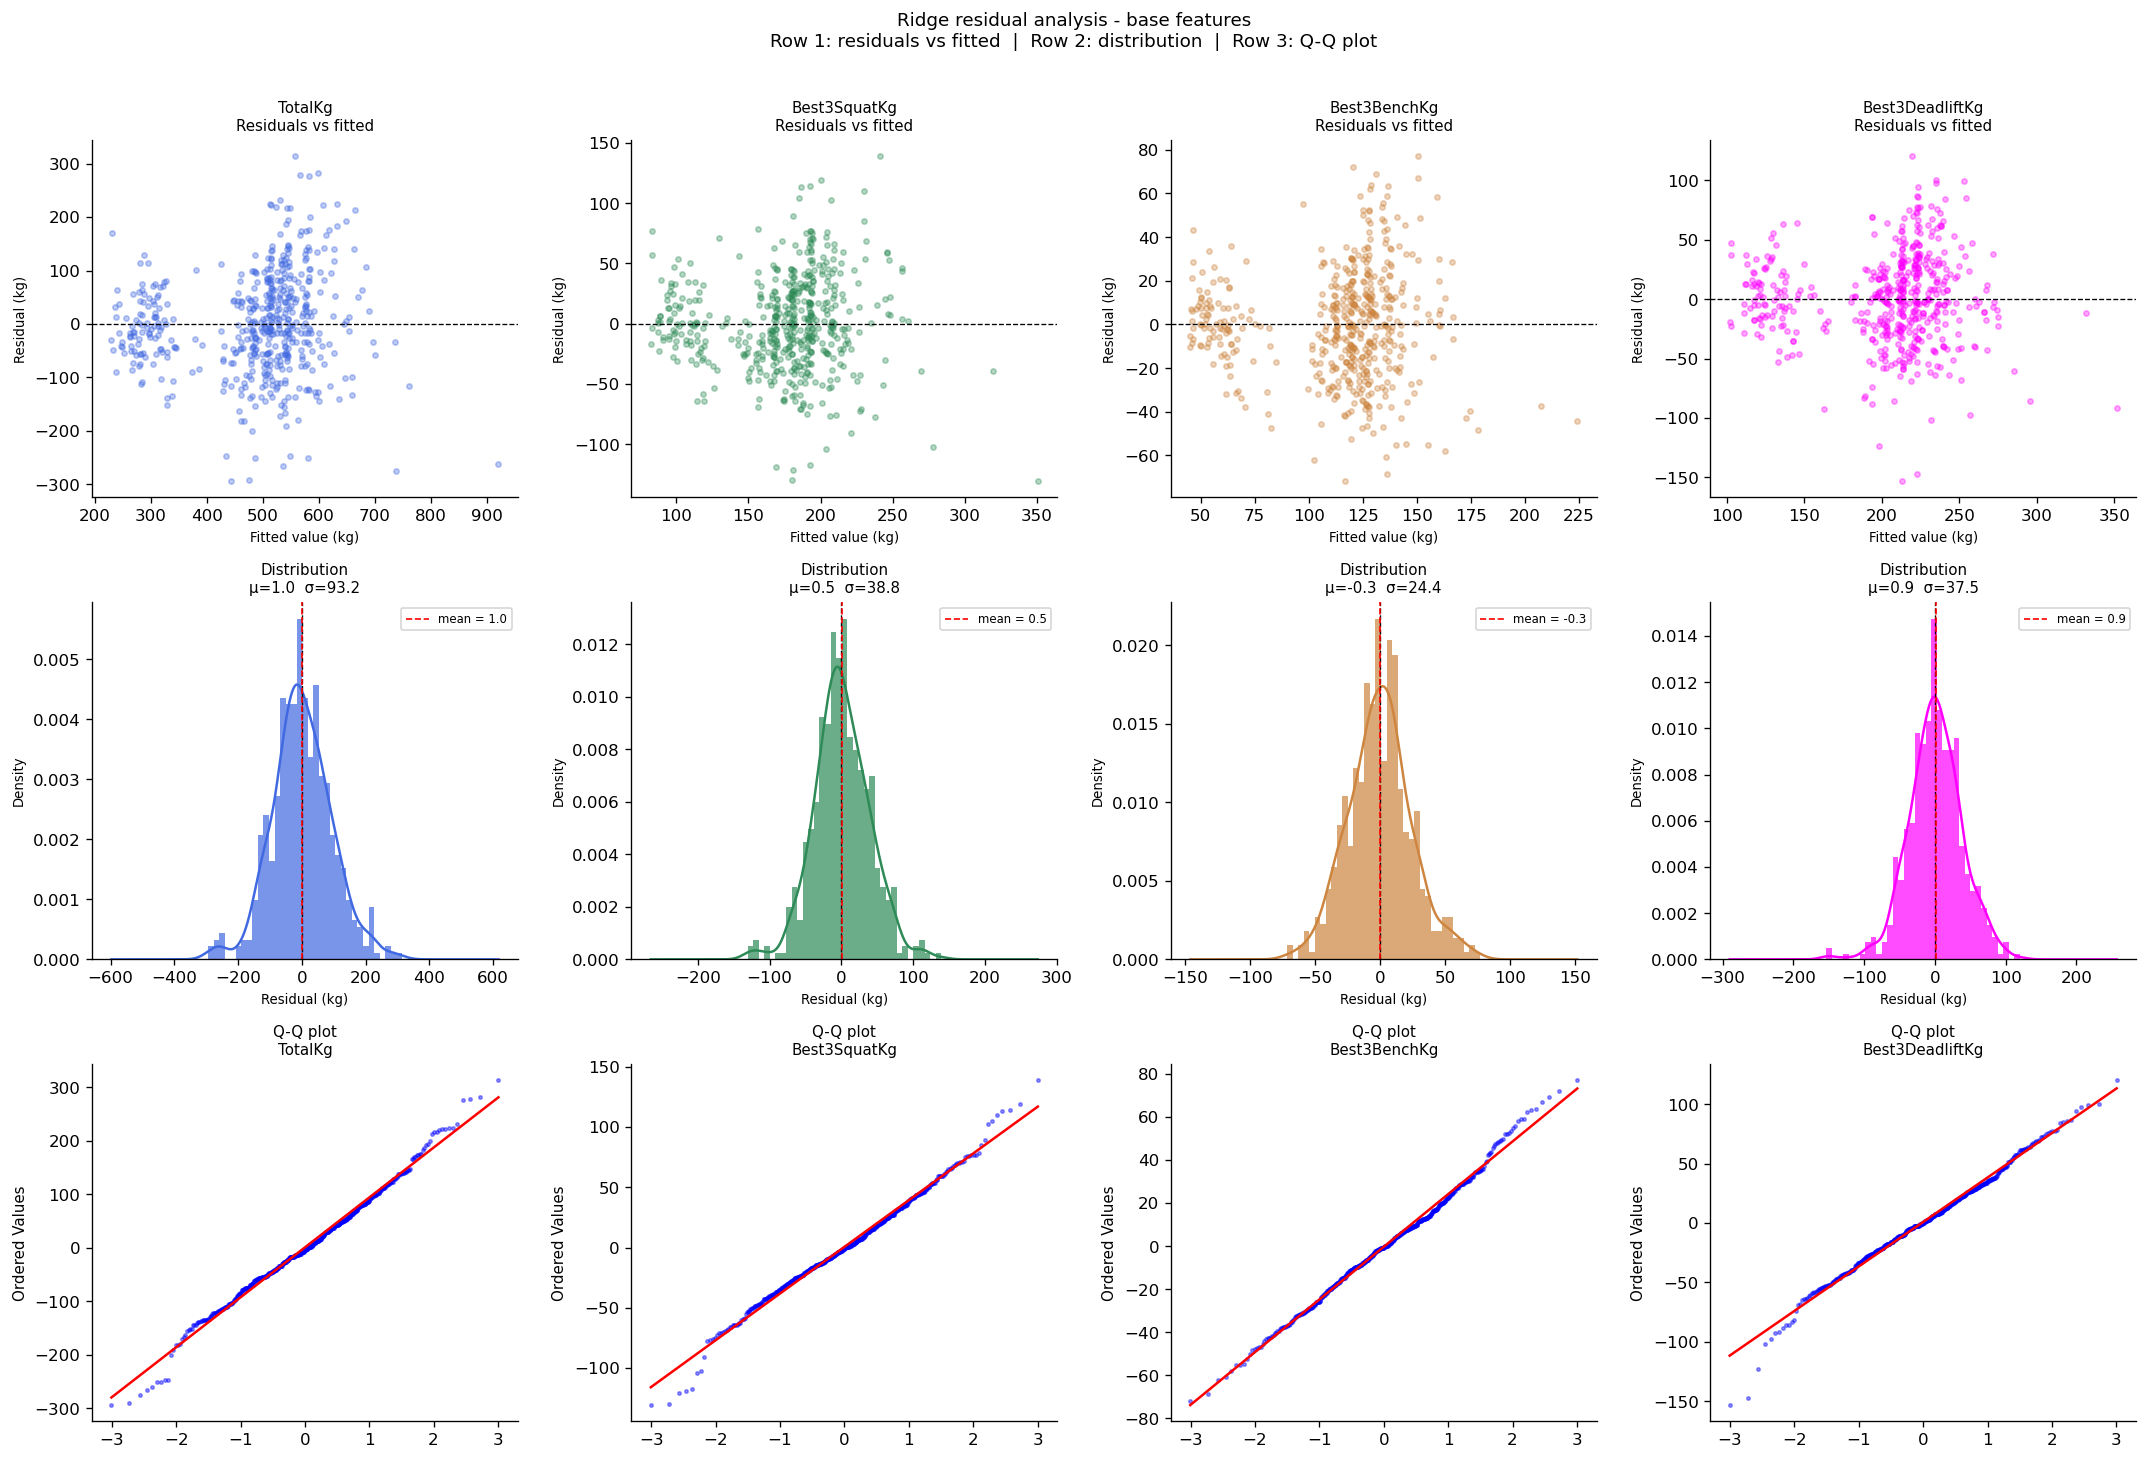

In [50]:
from scipy import stats as scipy_stats 

# Compute the residuals using Ridge predictions 
residuals_base_total = Y_te_base_total.ravel() - Y_pred_ridge_base_total_te.ravel()
residuals_age_total  = Y_te_age_total.ravel() - Y_pred_ridge_age_total_te.ravel()
residuals_base_sbd   = Y_te_base_sbd - Y_pred_ridge_base_sbd_te
residuals_age_sbd    = Y_te_age_sbd - Y_pred_ridge_age_sbd_te

# Gather the above together 
all_residuals_base = [residuals_base_total] + [col for col in residuals_base_sbd.T]
all_residuals_age = [residuals_age_total] + [col for col in residuals_age_sbd.T]
all_preds_base = ([Y_pred_ridge_base_total_te.ravel()] + [col for col in Y_pred_ridge_base_sbd_te.T]) 
all_preds_age = ([Y_pred_ridge_age_total_te.ravel()] + [col for col in Y_pred_ridge_age_sbd_te.T])

colors = ['royalblue', 'seagreen', 'peru', 'magenta']

import pandas as pd
import scipy.stats as scipy_stats

fig, axes = plt.subplots(3, 4, figsize=(18, 12)) 

for i, target in enumerate(all_targets_list):
    resid = all_residuals_base[i]
    pred = all_preds_base[i]
    col_color = colors[i]
    resid_mean = resid.mean()

    # ROW 1: Residuals vs Fitted Values
    # Captures heteroscedasticity or missed non-linear relationships
    ax_rv = axes[0, i]
    ax_rv.scatter(pred, resid, alpha=0.35, s=10, color=col_color)
    ax_rv.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_rv.set_xlabel("Fitted value (kg)", fontsize=8)
    ax_rv.set_ylabel("Residual (kg)", fontsize=8)
    ax_rv.set_title(f"{target}\nResiduals vs fitted", fontsize=9)

    # ROW 2: Residual Histogram with KDE
    # Evaluates error symmetry, dispersion, and baseline bias
    ax_hist = axes[1, i]
    ax_hist.hist(
        resid, bins=35, color=col_color, edgecolor="none", alpha=0.7, density=True
    )
    pd.Series(resid).plot.kde(ax=ax_hist, color=col_color, linewidth=1.5)

    ax_hist.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax_hist.axvline(
        resid_mean,
        color="red",
        linewidth=1,
        linestyle="--",
        label=f"mean = {resid_mean:.1f}",
    )
    ax_hist.set_xlabel("Residual (kg)", fontsize=8)
    ax_hist.set_ylabel("Density", fontsize=8)
    ax_hist.set_title(
        f"Distribution\nμ={resid_mean:.1f}  σ={resid.std():.1f}", fontsize=9
    )
    ax_hist.legend(fontsize=7)

    # ROW 3: Q-Q Plot Against Normal Distribution
    # Curve tails reveal heavy or light tails relative to normality assumptions
    ax_qq = axes[2, i]
    scipy_stats.probplot(resid, dist="norm", plot=ax_qq)
    ax_qq.set_title(f"Q-Q plot\n{target}", fontsize=9)
    ax_qq.set_xlabel("")

    ax_qq.lines[0].set(markersize=2, alpha=0.4)

plt.suptitle(
    "Ridge residual analysis - base features\n"
    "Row 1: residuals vs fitted  |  "
    "Row 2: distribution  |  "
    "Row 3: Q-Q plot",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / "residual_analysis_base.png", bbox_inches="tight")
plt.show()

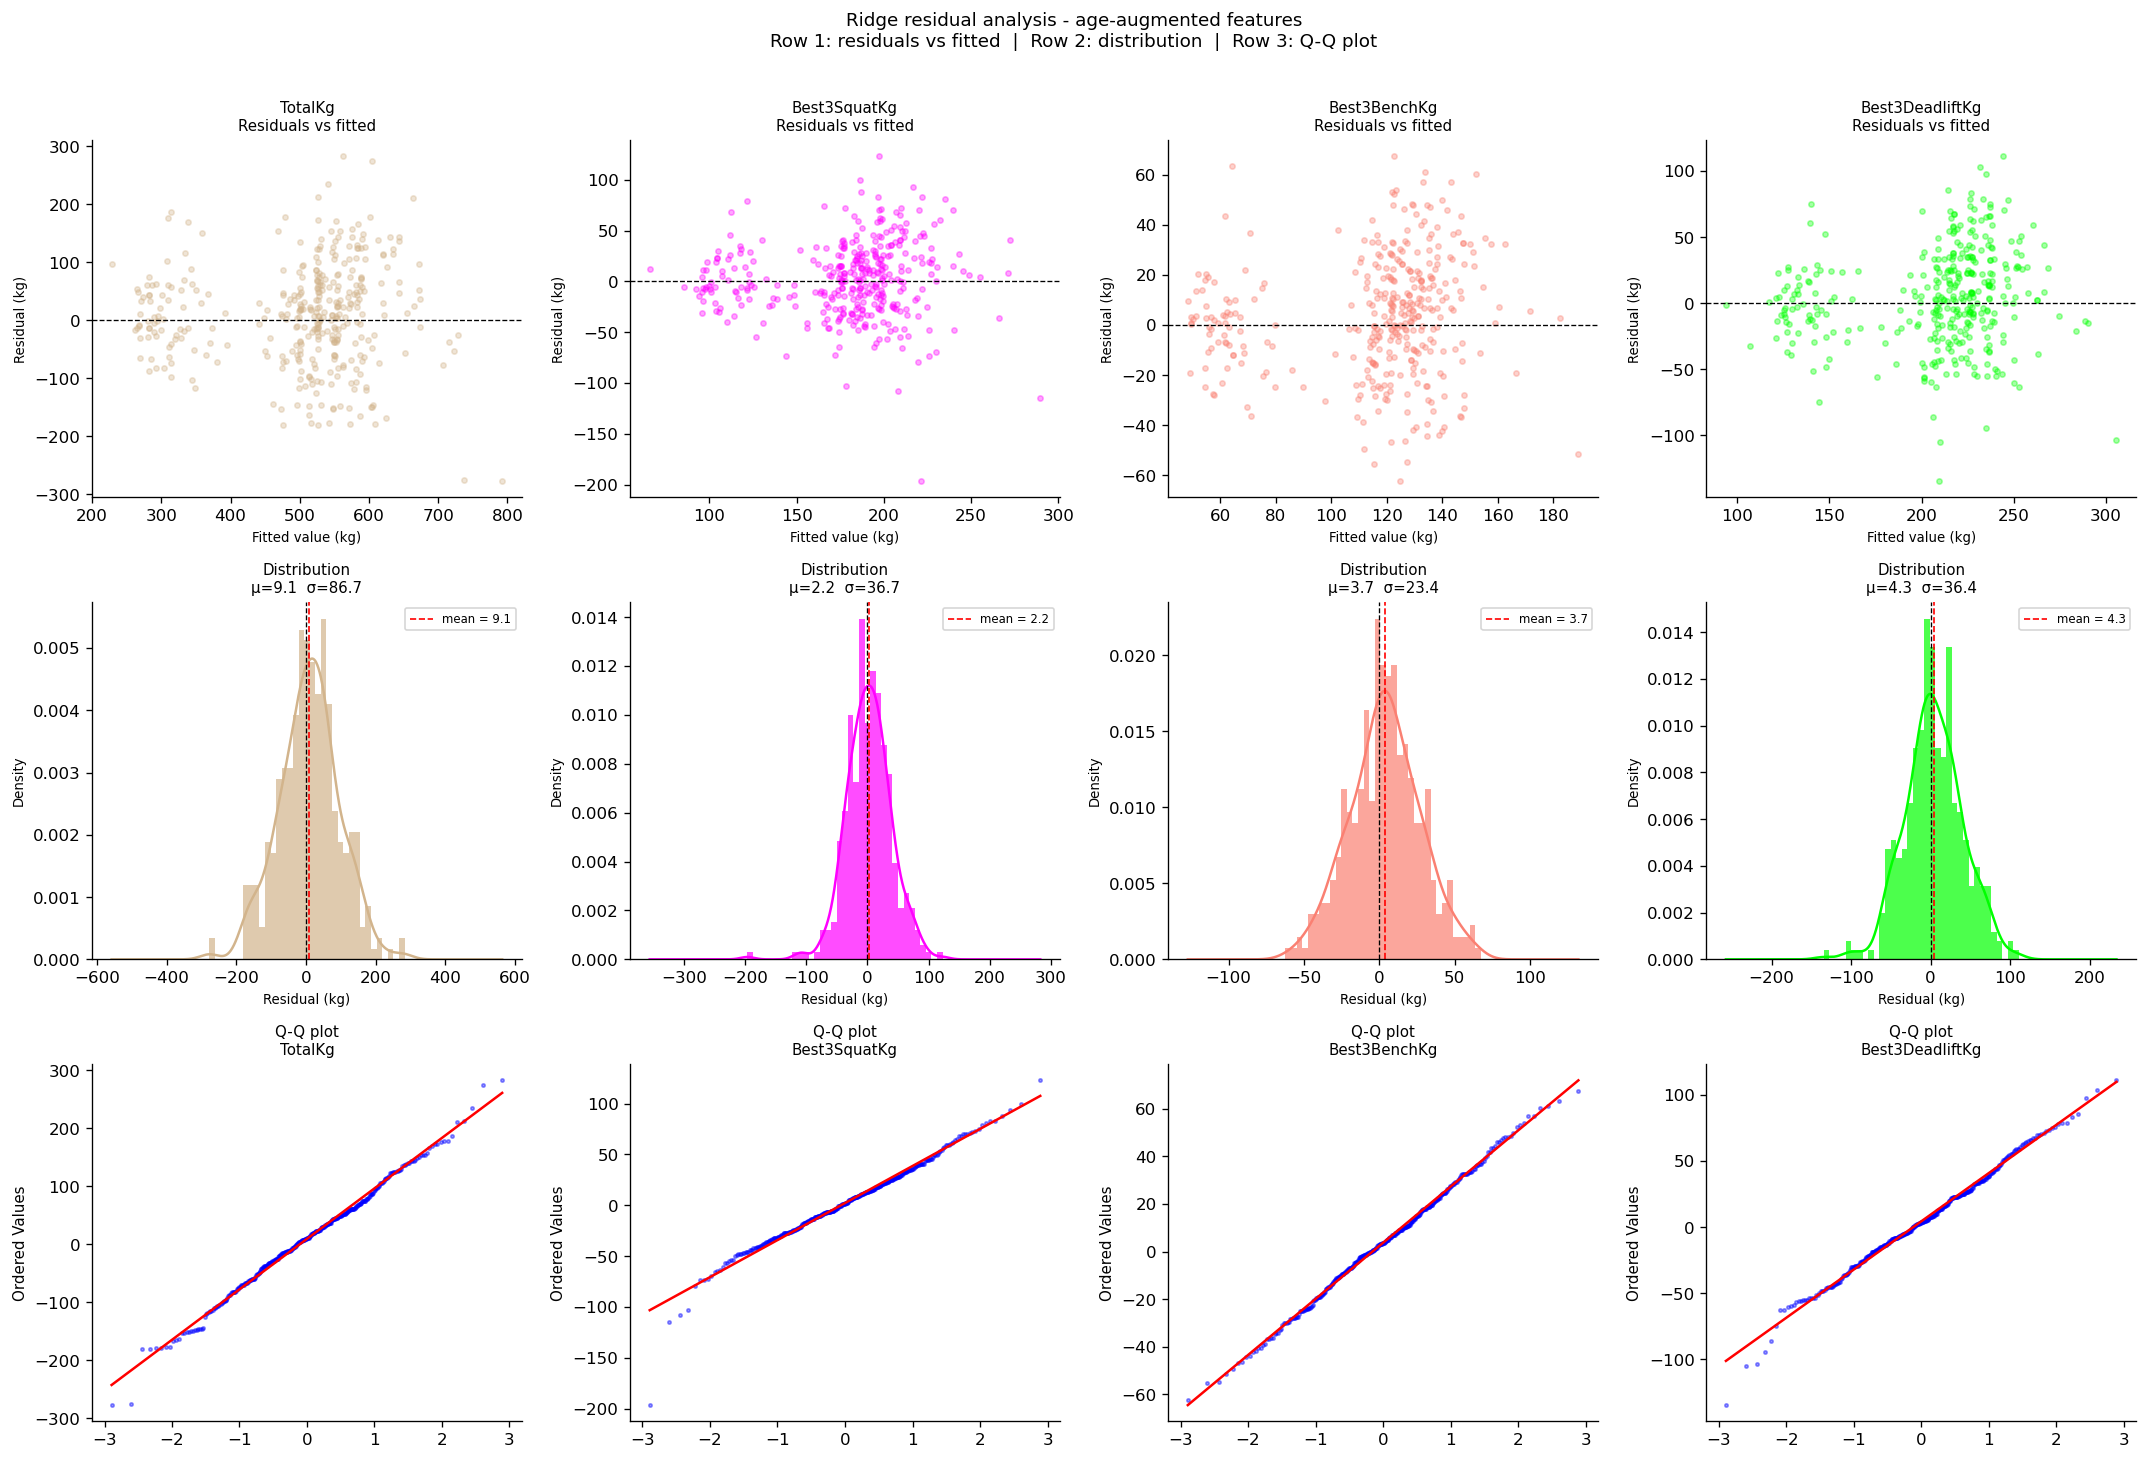

In [51]:
colors = ['tan', 'fuchsia', 'salmon', 'lime']

fig, axes = plt.subplots(3, 4, figsize=(18, 12)) 

for i, target in enumerate(all_targets_list):
    resid = all_residuals_age[i]
    pred = all_preds_age[i]
    col_color = colors[i]
    resid_mean = resid.mean()

    # ROW 1: Residuals vs Fitted Values
    # Captures heteroscedasticity or missed non-linear relationships
    ax_rv = axes[0, i]
    ax_rv.scatter(pred, resid, alpha=0.35, s=10, color=col_color)
    ax_rv.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_rv.set_xlabel("Fitted value (kg)", fontsize=8)
    ax_rv.set_ylabel("Residual (kg)", fontsize=8)
    ax_rv.set_title(f"{target}\nResiduals vs fitted", fontsize=9)

    # ROW 2: Residual Histogram with KDE
    # Evaluates error symmetry, dispersion, and baseline bias
    ax_hist = axes[1, i]
    ax_hist.hist(
        resid, bins=35, color=col_color, edgecolor="none", alpha=0.7, density=True
    )
    pd.Series(resid).plot.kde(ax=ax_hist, color=col_color, linewidth=1.5)

    ax_hist.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax_hist.axvline(
        resid_mean,
        color="red",
        linewidth=1,
        linestyle="--",
        label=f"mean = {resid_mean:.1f}",
    )
    ax_hist.set_xlabel("Residual (kg)", fontsize=8)
    ax_hist.set_ylabel("Density", fontsize=8)
    ax_hist.set_title(
        f"Distribution\nμ={resid_mean:.1f}  σ={resid.std():.1f}", fontsize=9
    )
    ax_hist.legend(fontsize=7)

    # ROW 3: Q-Q Plot Against Normal Distribution
    # Curve tails reveal heavy or light tails relative to normality assumptions
    ax_qq = axes[2, i]
    scipy_stats.probplot(resid, dist="norm", plot=ax_qq)
    ax_qq.set_title(f"Q-Q plot\n{target}", fontsize=9)
    ax_qq.set_xlabel("")

    ax_qq.lines[0].set(markersize=2, alpha=0.4)

plt.suptitle(
    "Ridge residual analysis - age-augmented features\n"
    "Row 1: residuals vs fitted  |  "
    "Row 2: distribution  |  "
    "Row 3: Q-Q plot",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / "residual_analysis_age.png", bbox_inches="tight")
plt.show()

## Cell 46 — Sex-stratified performance with mean residual

Mean residual per sex; a non-zero mean residual indicates systematic bias: the model consistently over- or under-predicts for one sex group. A positive mean residual means the model under-predicts on average (true value exceeds prediction). A negative mean residual means the model over-predicts. 

**Note on interpreting $\text{R}^2$ alongside the violin plots:** these two diagnostics can disagree without being contradictory — they answer different questions. $\text{R}^2$ measures explanatory power *relative to that
subgroup's own variance*: a small, low-variance subgroup (e.g. female squat, $\text{R}^2$ = −0.023) can produce a near-zero or negative $\text{R}^2$ even when the absolute residuals look reasonable, simply because there is little
variance in the group to explain. The violin plots instead show *absolute error magnitude and bias* — and by that measure the female residuals are consistently narrower than the male ones. Both are correct simultaneously: the model's absolute errors are smaller for female lifters, but it explains comparatively less of what variance exists within that group.

In [52]:
sex_te_base_total = df.loc[X_te_base_total.index, 'Sex'].values
sex_te_age_total  = df.loc[X_te_age_total.index, 'Sex'].values
sex_te_base_sbd   = df_complete.loc[X_te_base_sbd.index, 'Sex'].values
sex_te_age_sbd    = df_complete.loc[X_te_age_sbd.index, 'Sex'].values

print('Sex-stratified performance: TotalKg - base features')
print(f"{'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12} {'Std resid':>12}")
print(bsep)

for sex in ['M', 'F']: 
    mask         = sex_te_base_total == sex 
    y_true       = Y_te_base_total[mask].ravel() 
    y_pred       = Y_pred_ridge_base_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2))
    r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mean_r_value = residuals.mean()
    std_r_value  = residuals.std() 

    print(f"  {sex:<8} {mask.sum():>5} {rmse_value:>8.2f} "
          f"{r2_value:>8.3f} {mean_r_value:>12.2f} {std_r_value:>12.2f}") 
print('\n')

print('Sex-stratified performance: TotalKg - age-augmented features')
print(f"{'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12} {'Std resid':>12}")
print(bsep)

for sex in ['M', 'F']: 
    mask         = sex_te_age_total == sex 
    y_true       = Y_te_age_total[mask].ravel() 
    y_pred       = Y_pred_ridge_age_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2))
    r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mean_r_value = residuals.mean()
    std_r_value  = residuals.std() 

    print(f"  {sex:<8} {mask.sum():>5} {rmse_value:>8.2f} "
          f"{r2_value:>8.3f} {mean_r_value:>12.2f} {std_r_value:>12.2f}") 
print('\n') 

print('Sex-stratified performance: SBD targets - base features')
print(f"{'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12} {'Std resid':>12}")
print(bsep)
for t_idx, target in enumerate(target_names_sbd):
    print(f"\n  {target}:")
    print(f"  {'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
          f"{'Mean resid':>12}")
    print(f"  {'─'*48}") 

    for sex in ['M', 'F']: 
        mask         = sex_te_base_sbd == sex 
        y_true       = Y_te_base_sbd[mask, t_idx]
        y_pred       = Y_pred_ridge_base_sbd_te[mask, t_idx] 
        residuals    = y_true - y_pred 
    
        rmse_value   = np.sqrt(np.mean(residuals ** 2))
        r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        mean_r_value = residuals.mean()
        std_r_value  = residuals.std() 
    
        print(f"  {sex:<8} {mask.sum():>5} {rmse_value:>8.2f} "
              f"{r2_value:>8.3f} {mean_r_value:>12.2f} {std_r_value:>12.2f}")  
print('\n') 

print('Sex-stratified performance: SBD targets - age-augmented features')
print(f"{'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12} {'Std resid':>12}")
print(bsep)
for t_idx, target in enumerate(target_names_sbd):
    print(f"\n  {target}:")
    print(f"  {'Group':<10} {'n':>5} {'RMSE':>8} {'R²':>8} "
          f"{'Mean resid':>12}")
    print(f"  {'─'*48}") 

    for sex in ['M', 'F']: 
        mask         = sex_te_age_sbd == sex 
        y_true       = Y_te_age_sbd[mask, t_idx]
        y_pred       = Y_pred_ridge_age_sbd_te[mask, t_idx] 
        residuals    = y_true - y_pred 
    
        rmse_value   = np.sqrt(np.mean(residuals ** 2))
        r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        mean_r_value = residuals.mean()
        std_r_value  = residuals.std() 
    
        print(f"  {sex:<8} {mask.sum():>5} {rmse_value:>8.2f} "
              f"{r2_value:>8.3f} {mean_r_value:>12.2f} {std_r_value:>12.2f}")  
print('\n') 

Sex-stratified performance: TotalKg - base features
Group          n     RMSE       R²   Mean resid    Std resid
  M          419    99.98    0.317         4.04        99.90
  F          110    60.80    0.132       -10.79        59.83


Sex-stratified performance: TotalKg - age-augmented features
Group          n     RMSE       R²   Mean resid    Std resid
  M          291    91.41    0.267         9.68        90.89
  F           75    68.09    0.091         6.82        67.75


Sex-stratified performance: SBD targets - base features
Group          n     RMSE       R²   Mean resid    Std resid

  Best3SquatKg:
  Group          n     RMSE       R²   Mean resid
  ────────────────────────────────────────────────
  M          424    41.16    0.298         0.63        41.16
  F           97    25.85   -0.023         0.16        25.85

  Best3BenchKg:
  Group          n     RMSE       R²   Mean resid
  ────────────────────────────────────────────────
  M          424    25.99    0.270        

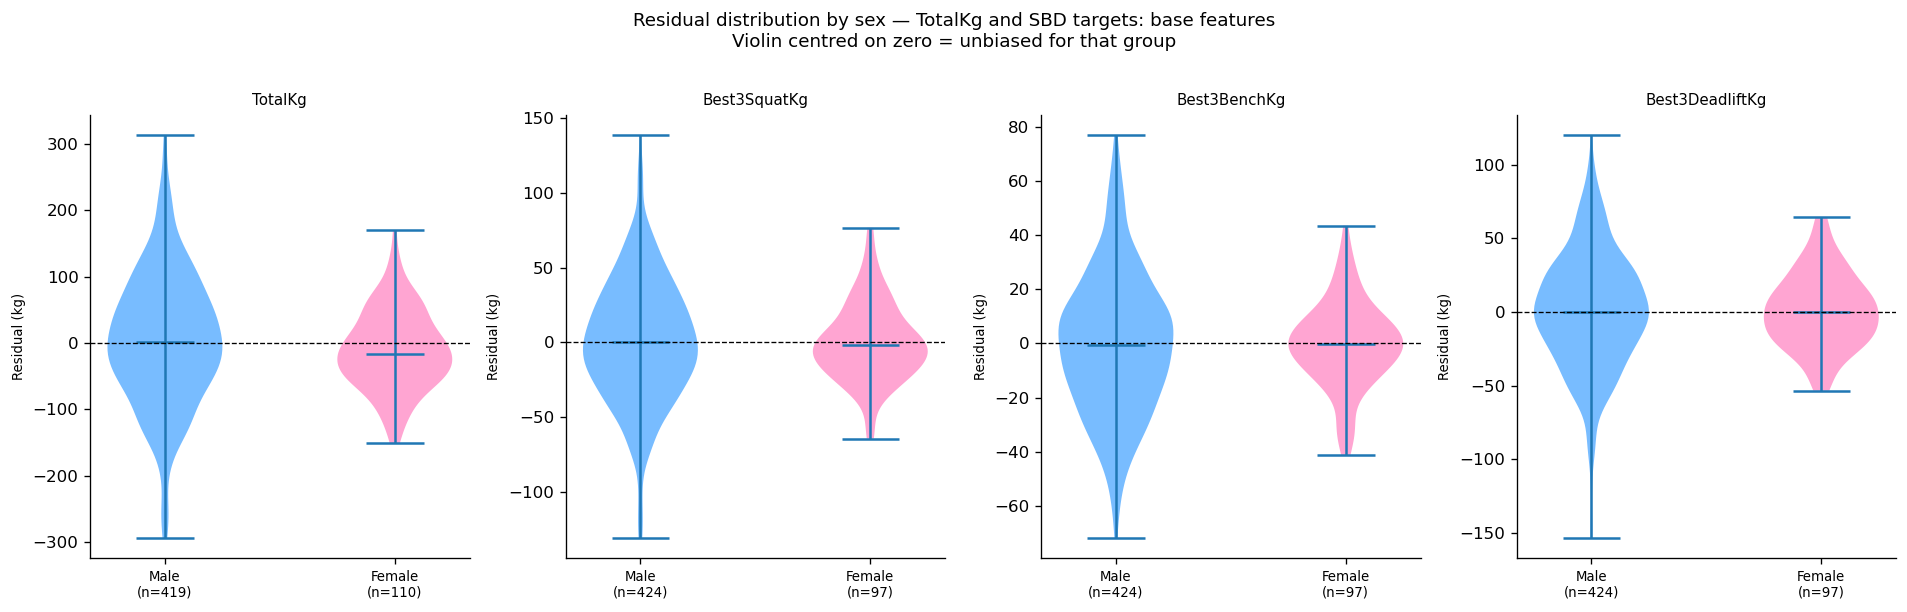

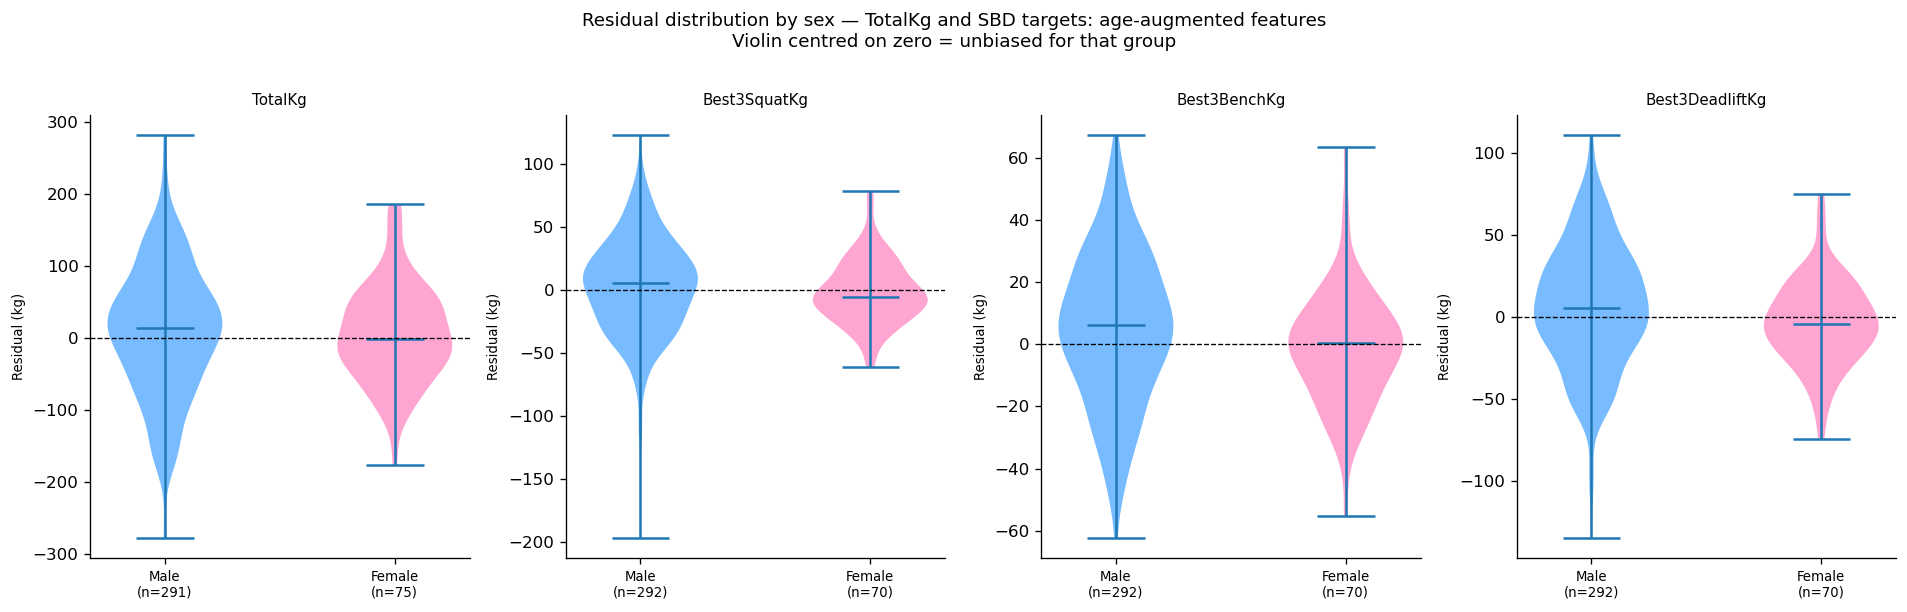

In [53]:
sex_colours = ["dodgerblue", "hotpink"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, target in enumerate(all_targets_list):
    ax = axes[i]
    resid_all = all_residuals_base[i]

    sex_labels = sex_te_base_total if target == "TotalKg" else sex_te_base_sbd

    resid_m = resid_all[sex_labels == "M"]
    resid_f = resid_all[sex_labels == "F"]

    violin_components = ax.violinplot(
        dataset=[resid_m, resid_f],
        positions=[1, 2],
        showmedians=True,
        showextrema=True,
    )

    for body_index, body_polygon in enumerate(violin_components["bodies"]):
        body_polygon.set_facecolor(sex_colours[body_index])
        body_polygon.set_alpha(0.6)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f"Male\n(n={len(resid_m)})", f"Female\n(n={len(resid_f)})"], fontsize=8
    )
    ax.set_ylabel("Residual (kg)", fontsize=8)
    ax.set_title(target, fontsize=9)

plt.suptitle(
    "Residual distribution by sex — TotalKg and SBD targets: base features\n"
    "Violin centred on zero = unbiased for that group",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / "residuals_by_sex_base.png", bbox_inches="tight")
plt.show()

print('\n')

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, target in enumerate(all_targets_list):
    ax = axes[i]
    resid_all = all_residuals_age[i]

    sex_labels = sex_te_age_total if target == "TotalKg" else sex_te_age_sbd

    resid_m = resid_all[sex_labels == "M"]
    resid_f = resid_all[sex_labels == "F"]

    violin_components = ax.violinplot(
        dataset=[resid_m, resid_f],
        positions=[1, 2],
        showmedians=True,
        showextrema=True,
    )

    for body_index, body_polygon in enumerate(violin_components["bodies"]):
        body_polygon.set_facecolor(sex_colours[body_index])
        body_polygon.set_alpha(0.6)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f"Male\n(n={len(resid_m)})", f"Female\n(n={len(resid_f)})"], fontsize=8
    )
    ax.set_ylabel("Residual (kg)", fontsize=8)
    ax.set_title(target, fontsize=9)

plt.suptitle(
    "Residual distribution by sex — TotalKg and SBD targets: age-augmented features\n"
    "Violin centred on zero = unbiased for that group",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / "residuals_by_sex_age.png", bbox_inches="tight")
plt.show()

## Cell 47 — Performance by age category 

AgeCategory is derived from the AgeClass column. This cell checks whether the model performs equally well across Sub-Junior, Junior, Open, Masters, and Unknown categories.

We use the full dataset indices to recover AgeCategory labels for the test set rows. Unknown means AgeClass was missing.

**Findings:** the Masters subgroup is poorly explained under both the base (RMSE 107.1 kg, $\text{R}^2$ = 0.247) and age-augmented (RMSE 116.0 kg, $\text{R}^2$ = 0.038) feature sets — age-augmentation does not rescue this subgroup, and performance is if anything slightly worse. This points to small sample size (33–35 test rows) combined with within-category heterogeneity — Masters spans a wide 40+ age range covering very different lifters at 40 versus 70 — rather than a missing feature the model could exploit.

The model also underperforms for female lifters across several targets ($\text{R}^2$ near zero or negative for base squat and bench). As with Masters, this is consistent with a small subgroup sample size limiting how much structure the model can learn, rather than a flaw specific to female lifters.

In [54]:
age_te_base_total = df.loc[X_te_base_total.index, 'AgeCategory'].values
age_te_age_total  = df.loc[X_te_age_total.index, 'AgeCategory'].values
age_te_base_sbd   = df_complete.loc[X_te_base_sbd.index, 'AgeCategory'].values
age_te_age_sbd    = df_complete.loc[X_te_age_sbd.index, 'AgeCategory'].values

age_categories = ['Sub-Junior', 'Junior', 'Open', 'Masters', 'Unknown']

Performance by age category: TotalKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      63    83.25    0.484       -25.68
  Junior         106    74.02    0.619        19.94
  Open           176    98.74    0.655        22.58
  Masters         35   107.08    0.247       -47.49
  Unknown        149    99.00    0.620       -15.43


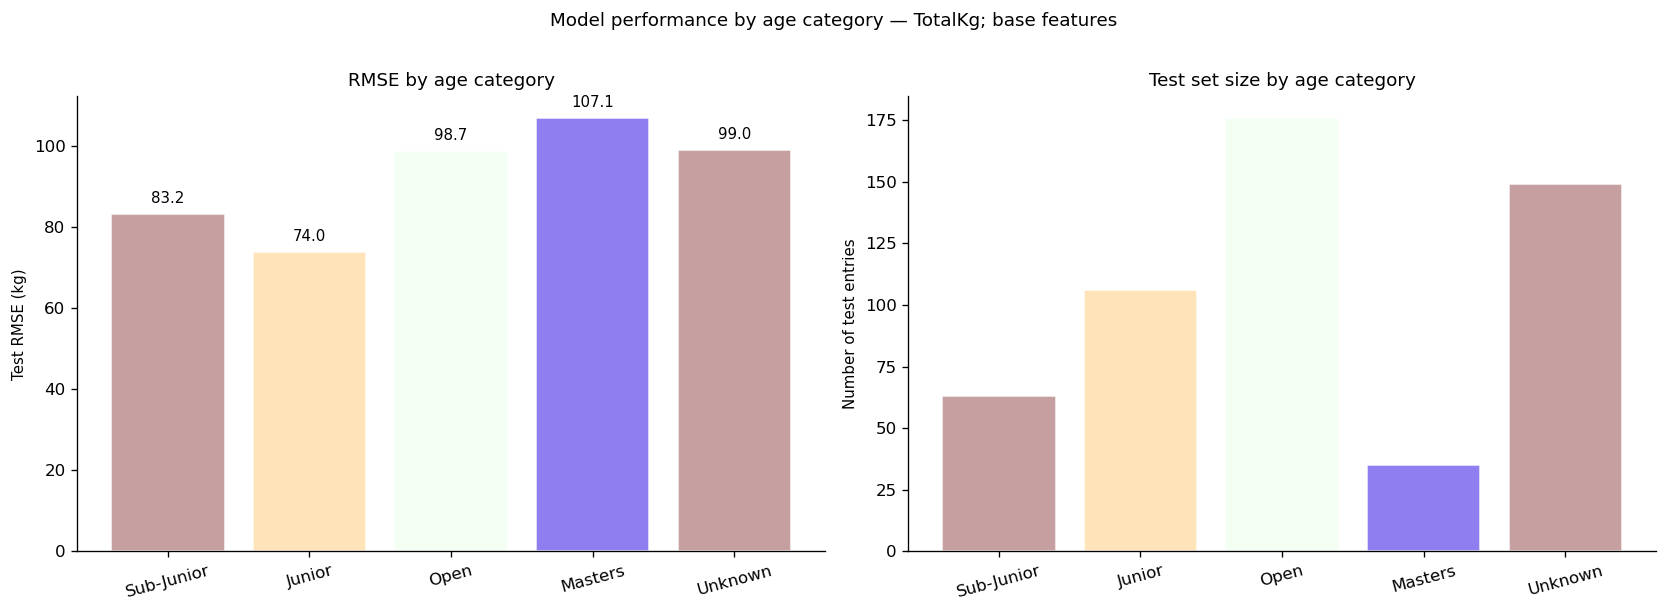

In [55]:
age_te_base_total = df.loc[X_te_base_total.index, 'AgeCategory'].values
age_te_age_total  = df.loc[X_te_age_total.index, 'AgeCategory'].values
age_te_base_sbd   = df_complete.loc[X_te_base_sbd.index, 'AgeCategory'].values
age_te_age_sbd    = df_complete.loc[X_te_age_sbd.index, 'AgeCategory'].values

age_categories = ['Sub-Junior', 'Junior', 'Open', 'Masters', 'Unknown']

print('Performance by age category: TotalKg - base features')
print(f"{'Category':<14} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12}")
print(bsep) 

rmse_age_cat_base_total = {} 

for category in age_categories: 
    mask = age_te_base_total == category 
    n    = mask.sum()

    if n < 5: 
        print(f"  {category:<12} {n:>5}  (too few samples)")
        continue 

    y_true       = Y_te_base_total[mask].ravel() 
    y_pred       = Y_pred_ridge_base_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2))
    r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mean_r_value = residuals.mean() 

    rmse_age_cat_base_total[category] = rmse_value 

    print(f"  {category:<12} {n:>5} {rmse_value:>8.2f} "
          f"{r2_value:>8.3f} {mean_r_value:>12.2f}") 

# Left: RMSE by age category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories_present = list(rmse_age_cat_base_total.keys())
rmse_values        = list(rmse_age_cat_base_total.values())
bar_colours        = ['rosybrown', 'navajowhite', 'honeydew', 'mediumslateblue']

bars = axes[0].bar(
    categories_present, rmse_values,
    color     = bar_colours[:len(categories_present)],
    edgecolor = 'white',
    alpha     = 0.85
)

for bar in bars:
    bar_height = bar.get_height()
    label_x_pos = bar.get_x() + bar.get_width() / 2

    axes[0].text(
            x=label_x_pos,
            y=bar_height + 2,
            s=f"{bar_height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

axes[0].set_ylabel('Test RMSE (kg)')
axes[0].set_title('RMSE by age category')
axes[0].tick_params(axis='x', rotation=15)

# Right: sample count by age category
n_by_cat = []
for category in categories_present:
    n_by_cat.append((age_te_base_total == category).sum())

axes[1].bar(
    categories_present, n_by_cat,
    color     = bar_colours[:len(categories_present)],
    edgecolor = 'white',
    alpha     = 0.85
)
axes[1].set_ylabel('Number of test entries')
axes[1].set_title('Test set size by age category')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(
    'Model performance by age category — TotalKg; base features',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / 'performance_by_age_base_total.png', bbox_inches='tight')
plt.show()

Performance by age category: TotalKg - age-augmented features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      46    71.94    0.588       -24.47
  Junior         110    74.38    0.640        14.89
  Open           176    91.55    0.647        29.03
  Masters         34   116.00    0.038       -67.46
  Unknown          0  (too few samples)


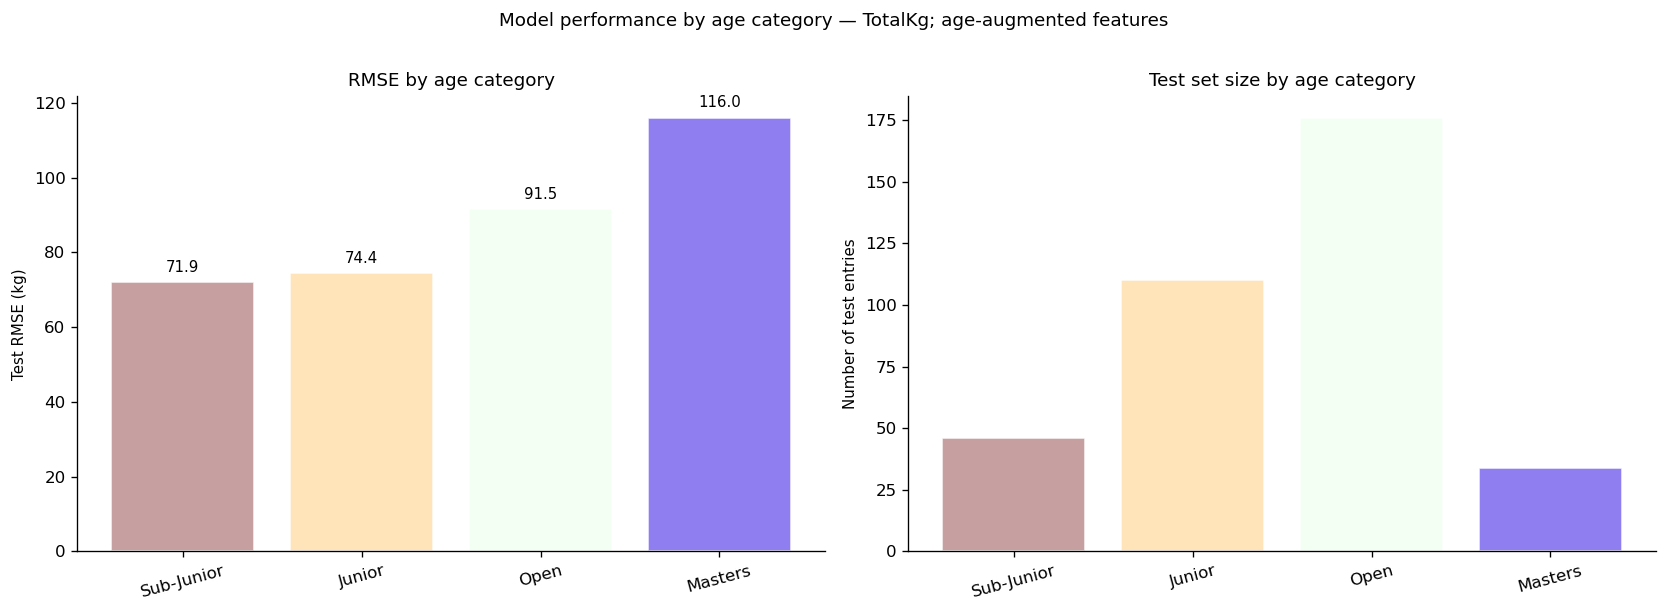

In [56]:
print('Performance by age category: TotalKg - age-augmented features')
print(f"{'Category':<14} {'n':>5} {'RMSE':>8} {'R²':>8} "
      f"{'Mean resid':>12}")
print(bsep) 

rmse_age_cat_age_total = {} 

for category in age_categories: 
    mask = age_te_age_total == category 
    n    = mask.sum()

    if n < 5: 
        print(f"  {category:<12} {n:>5}  (too few samples)")
        continue 

    y_true       = Y_te_age_total[mask].ravel() 
    y_pred       = Y_pred_ridge_age_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2))
    r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    mean_r_value = residuals.mean() 

    rmse_age_cat_age_total[category] = rmse_value 

    print(f"  {category:<12} {n:>5} {rmse_value:>8.2f} "
          f"{r2_value:>8.3f} {mean_r_value:>12.2f}") 

# Left: RMSE by age category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories_present = list(rmse_age_cat_age_total.keys())
rmse_values        = list(rmse_age_cat_age_total.values())
bar_colours        = ['rosybrown', 'navajowhite', 'honeydew', 'mediumslateblue']

bars = axes[0].bar(
    categories_present, rmse_values,
    color     = bar_colours[:len(categories_present)],
    edgecolor = 'white',
    alpha     = 0.85
)

for bar in bars:
    bar_height = bar.get_height()
    label_x_pos = bar.get_x() + bar.get_width() / 2

    axes[0].text(
            x=label_x_pos,
            y=bar_height + 2,
            s=f"{bar_height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

axes[0].set_ylabel('Test RMSE (kg)')
axes[0].set_title('RMSE by age category')
axes[0].tick_params(axis='x', rotation=15)

# Right: sample count by age category
n_by_cat = []
for category in categories_present:
    n_by_cat.append((age_te_age_total == category).sum())

axes[1].bar(
    categories_present, n_by_cat,
    color     = bar_colours[:len(categories_present)],
    edgecolor = 'white',
    alpha     = 0.85
)
axes[1].set_ylabel('Number of test entries')
axes[1].set_title('Test set size by age category')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(
    'Model performance by age category — TotalKg; age-augmented features',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(plots_dir_p4 / 'performance_by_age_age_total.png', bbox_inches='tight')
plt.show()

Performance by age category: SBD targets; Best3SquatKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      61    33.41    0.137       -13.43
  Junior         103    30.28    0.552        11.29
  Open           180    41.11    0.553         8.77
  Masters         20    34.86    0.460       -18.38
  Unknown        157    43.13    0.448        -8.10
Performance by age category: SBD targets; Best3BenchKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      61    22.99    0.274       -10.46
  Junior         103    22.76    0.568         5.29
  Open           180    24.36    0.651         4.60
  Masters         20    25.00    0.531       -10.56
  Unknown        157    25.91    0.578        -4.37
Performance by age category: SBD targets; Best3DeadliftKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      61    38.29    0.180       -11.89
  Junior         103    29.70    0.613         9.30
  Op

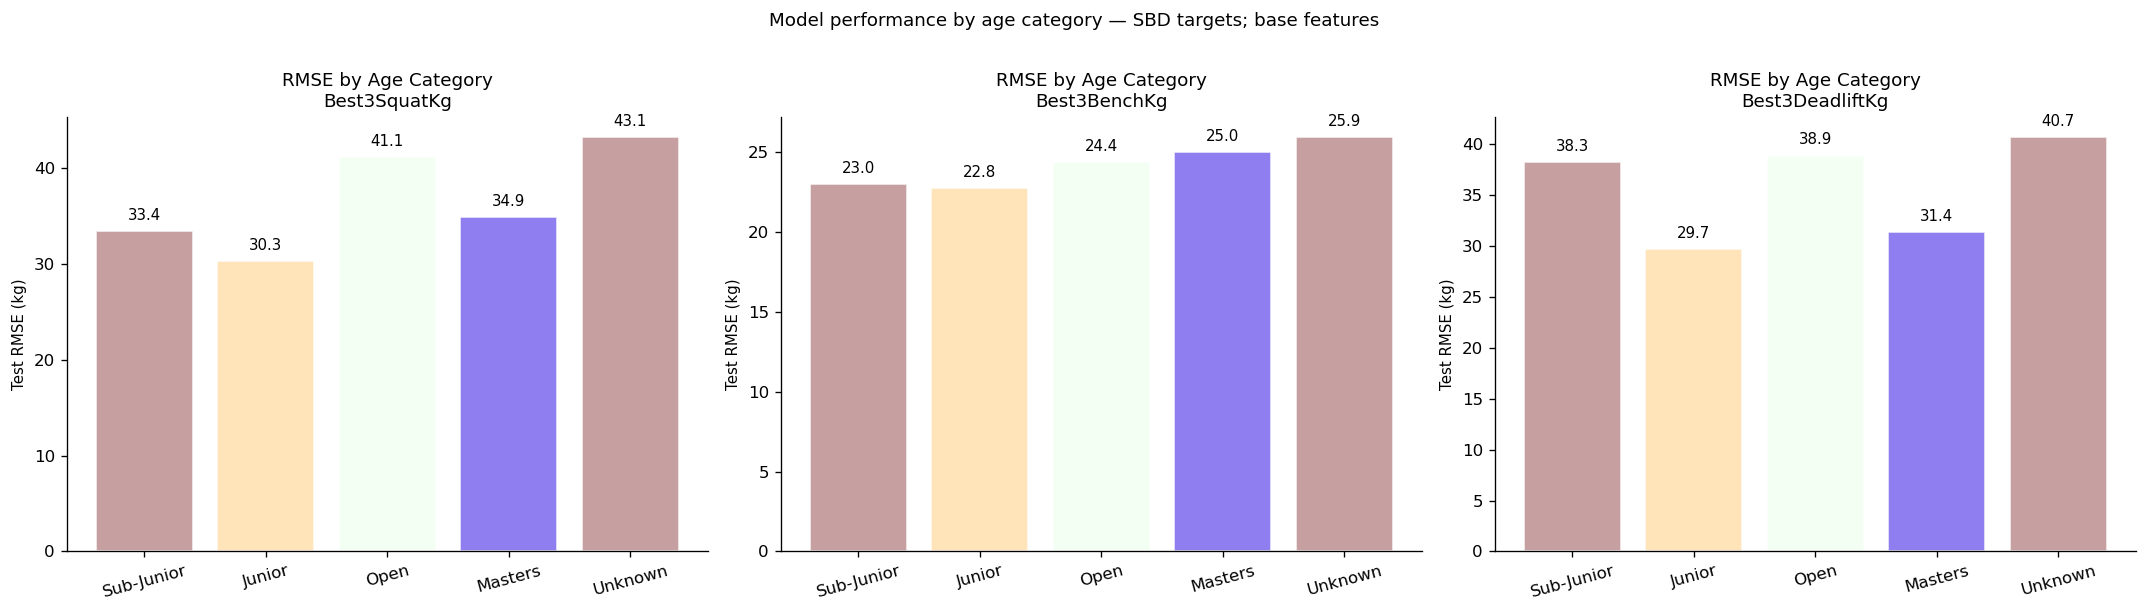

In [57]:
results_age_cat_base_sbd = {} 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(target_names_sbd): 
    print(f"Performance by age category: SBD targets; {target} - base features")
    print(
        f"{'Category':<14} {'n':>5} {'RMSE':>8} {'R²':>8} {'Mean resid':>12}"
    )
    print(bsep) 

    ax = axes[i] 

    rmse_age_cat_base_sbd  = {} 
    sample_counts_base_sbd = []
    categories_present     = []

    for category in age_categories: 
        mask = age_te_base_sbd == category 
        n = mask.sum() 

        if n < 5:
            print(f"  {category:<12} {n:>5}  (too few samples)")
            continue 

        y_true    = Y_te_base_sbd[mask, i].ravel() 
        y_pred    = Y_pred_ridge_base_sbd_te[mask, i].ravel() 
        residuals = y_true - y_pred 

        rmse_value   = np.sqrt(np.mean(residuals ** 2))
        r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) **2 )
        mean_r_value = residuals.mean() 

        categories_present.append(category)
        rmse_age_cat_base_sbd[category] = rmse_value
        sample_counts_base_sbd.append(n)

        print(f"  {category:<12} {n:>5} {rmse_value:>8.2f} "
            f"{r2_value:>8.3f} {mean_r_value:>12.2f}")

    results_age_cat_base_sbd[target] = {
        "rmse": rmse_age_cat_base_sbd, 
        "n": {categories_present[idx]: sample_counts_base_sbd[idx]
              for idx in range(len(categories_present))},
    }

    rmse_values = list(rmse_age_cat_base_sbd.values())
    color_slice = bar_colours[: len(categories_present)]

    bars = ax.bar(
        categories_present,
        rmse_values,
        color=color_slice,
        edgecolor="white",
        alpha=0.85,
    )
    
    for bar in bars:
        bar_height = bar.get_height()
        label_x_pos = bar.get_x() + bar.get_width() / 2
        ax.text(
            x=label_x_pos,
            y=bar_height + (max(rmse_values) * 0.02),  # Dynamic padding offset
            s=f"{bar_height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylabel("Test RMSE (kg)")
    ax.set_title(f"RMSE by Age Category\n{target}")
    ax.tick_params(axis="x", rotation=15)
    
plt.suptitle(
        'Model performance by age category — SBD targets; base features',
        fontsize=11, y=1.01
    )
plt.tight_layout()
plt.savefig(plots_dir_p4 / 'performance_by_age_base_sbd.png', bbox_inches='tight')
plt.show() 

Performance by age category: SBD targets; Best3SquatKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      54    44.21    0.199       -16.46
  Junior         112    30.16    0.544         2.07
  Open           171    37.69    0.604        11.40
  Masters         25    39.15    0.271       -19.41
  Unknown          0  (too few samples)
Performance by age category: SBD targets; Best3BenchKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      54    21.56    0.496        -5.40
  Junior         112    23.13    0.591         4.50
  Open           171    23.29    0.687         8.67
  Masters         25    32.39    0.405       -14.29
  Unknown          0  (too few samples)
Performance by age category: SBD targets; Best3DeadliftKg - base features
Category           n     RMSE       R²   Mean resid
  Sub-Junior      54    39.79    0.392       -12.75
  Junior         112    30.04    0.604         3.47
  Open           171    39.2

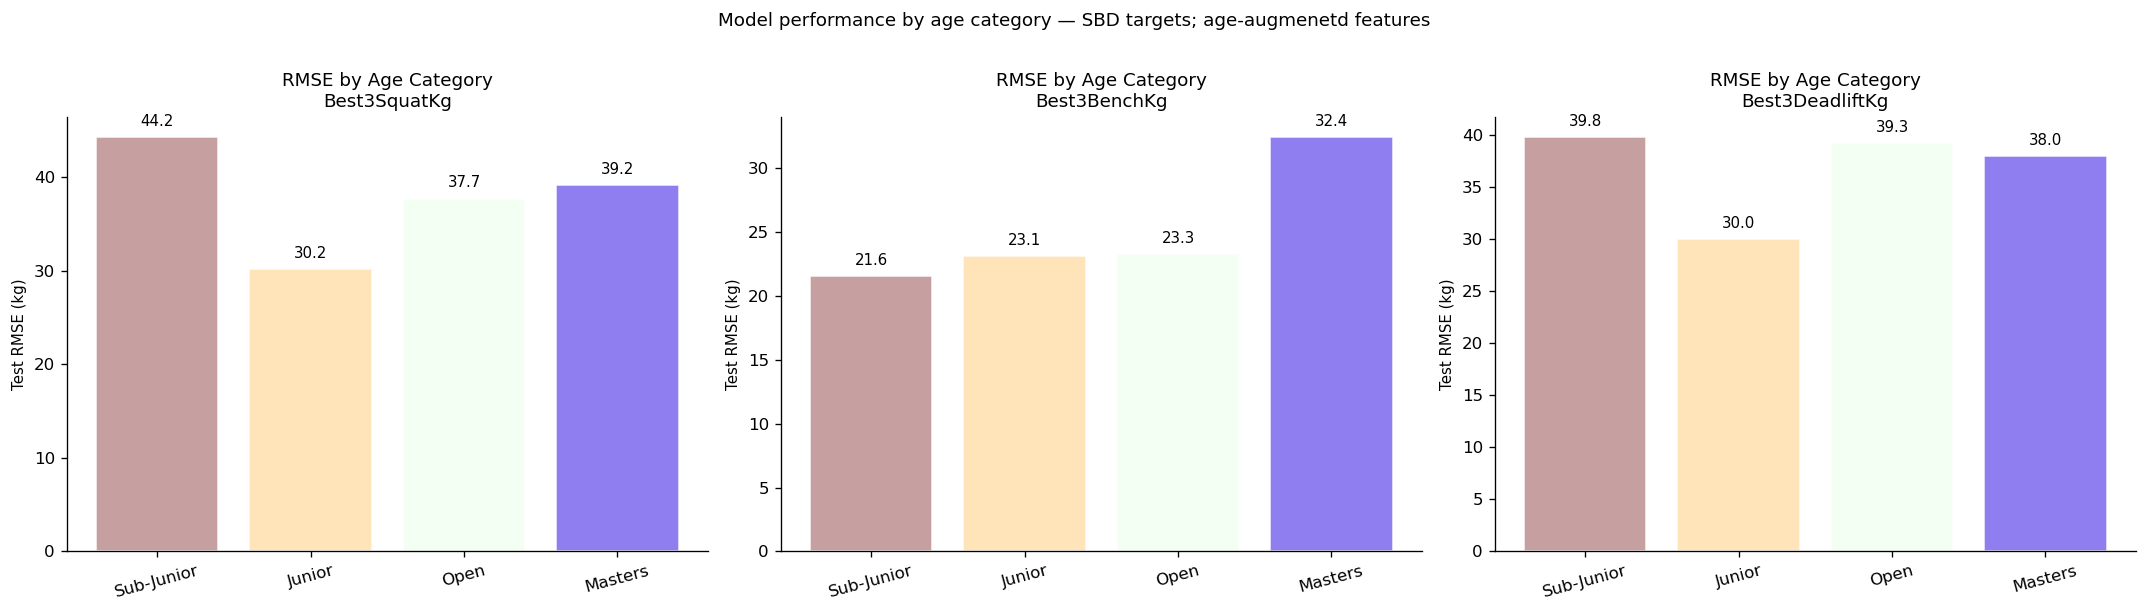

In [58]:
results_age_cat_age_sbd = {} 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(target_names_sbd): 
    print(f"Performance by age category: SBD targets; {target} - base features")
    print(
        f"{'Category':<14} {'n':>5} {'RMSE':>8} {'R²':>8} {'Mean resid':>12}"
    )
    print(bsep) 

    ax = axes[i] 

    rmse_age_cat_age_sbd  = {} 
    sample_counts_age_sbd = []
    categories_present     = []

    for category in age_categories: 
        mask = age_te_age_sbd == category 
        n = mask.sum() 

        if n < 5:
            print(f"  {category:<12} {n:>5}  (too few samples)")
            continue 

        y_true    = Y_te_age_sbd[mask, i].ravel() 
        y_pred    = Y_pred_ridge_age_sbd_te[mask, i].ravel() 
        residuals = y_true - y_pred 

        rmse_value   = np.sqrt(np.mean(residuals ** 2))
        r2_value     = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) **2 )
        mean_r_value = residuals.mean() 

        categories_present.append(category)
        rmse_age_cat_age_sbd[category] = rmse_value
        sample_counts_age_sbd.append(n)

        print(f"  {category:<12} {n:>5} {rmse_value:>8.2f} "
            f"{r2_value:>8.3f} {mean_r_value:>12.2f}")

    results_age_cat_age_sbd[target] = {
        "rmse": rmse_age_cat_age_sbd,
        "n": {categories_present[idx]: sample_counts_age_sbd[idx]
              for idx in range(len(categories_present))},
    }

    rmse_values = list(rmse_age_cat_age_sbd.values())
    color_slice = bar_colours[: len(categories_present)]

    bars = ax.bar(
        categories_present,
        rmse_values,
        color=color_slice,
        edgecolor="white",
        alpha=0.85,
    )
    
    for bar in bars:
        bar_height = bar.get_height()
        label_x_pos = bar.get_x() + bar.get_width() / 2
        ax.text(
            x=label_x_pos,
            y=bar_height + (max(rmse_values) * 0.02),  # Dynamic padding offset
            s=f"{bar_height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylabel("Test RMSE (kg)")
    ax.set_title(f"RMSE by Age Category\n{target}")
    ax.tick_params(axis="x", rotation=15)
    
plt.suptitle(
        'Model performance by age category — SBD targets; age-augmenetd features',
        fontsize=11, y=1.01
    )
plt.tight_layout()
plt.savefig(plots_dir_p4 / 'performance_by_age_age_sbd.png', bbox_inches='tight')
plt.show() 

## Cell 48 — Bias-variance analysis 

Compare training RMSE vs CV RMSE to diagnose the ***bias-variance*** regime.

1. Large gap -train RMSE << CV RMSE- suggests overfitting; high variance
2. Small gap but both high indicates underfitting; high bias
3. Both low means good fit

We expect high bias here: with only a small number of features describing athletes whose performance is (to some extent) driven by unobserved factors (training history, experience, competitive level), the model cannot capture most of the variance in performance.

In [59]:
def compute_train_rmse(X_np, Y_np, model): 
    """
    Fit model on full data and return training RMSE.
    This is an optimistic estimate — the model has seen all the data.
    Useful only for diagnosing bias vs variance, not for reporting.
    """

    scaler = StandardScaler()
    X_s    = scaler.fit_transform(X_np)
    Y_fit  = Y_np.ravel() if Y_np.shape[1] == 1 else Y_np 
    model.fit(X_s, Y_fit) 
    Y_pred = model.predict(X_s)

    if Y_np.shape[1] == 1:
        rmse_scalar  = np.sqrt(mean_squared_error(Y_np.ravel(), Y_pred))
        return rmse_scalar
    else:
        rmse_per_column = []
        num_columns = Y_np.shape[1]

        for j in range(num_columns):
            actual_column = Y_np[:, j]
            predicted_column = Y_pred[:, j]

            column_mse = mean_squared_error(actual_column, predicted_column)
            column_rmse = np.sqrt(column_mse)

            rmse_per_column.append(column_rmse)

        rmse_per_column_array = np.array(rmse_per_column)
        return rmse_per_column_array

# TotalKg; base features
tr_rmse_ols_base_total   = compute_train_rmse(X_base_total_np, Y_base_total_np, LinearRegression())
tr_rmse_ridge_base_total = compute_train_rmse(X_base_total_np, Y_base_total_np, SkRidge(alpha = ridge_lam_base_total))
# TotalKg; age-augmented features
tr_rmse_ols_age_total    = compute_train_rmse(X_age_total_np, Y_age_total_np, LinearRegression())
tr_rmse_ridge_age_total  = compute_train_rmse(X_age_total_np, Y_age_total_np, SkRidge(alpha = ridge_lam_age_total))
# CV RMSE results from Phase 3 
cv_ols_base_total        = strat_results_base_total['OLS'].mean()
cv_ridge_base_total      = strat_results_base_total['Ridge'].mean()
cv_ols_age_total         = strat_results_age_total['OLS'].mean()
cv_ridge_age_total       = strat_results_age_total['Ridge'].mean()

print('Bias-variance diagnosis: TotalKg; base features')
print(f"{'Model':<10} {'Train RMSE':>12} {'CV RMSE':>12} {'Gap':>10}")
print(bsep)
print(f"  {'OLS':<8} {tr_rmse_ols_base_total:>12.2f} "
      f"{cv_ols_base_total:>12.2f} "
      f"{cv_ols_base_total - tr_rmse_ols_base_total:>10.2f}")
print(f"  {'Ridge':<8} {tr_rmse_ridge_base_total:>12.2f} "
      f"{cv_ridge_base_total:>12.2f} "
      f"{cv_ridge_base_total - tr_rmse_ridge_base_total:>10.2f}")
print('\n')
print('Bias-variance diagnosis: TotalKg; age-augmented features')
print(f"{'Model':<10} {'Train RMSE':>12} {'CV RMSE':>12} {'Gap':>10}")
print(bsep)
print(f"  {'OLS':<8} {tr_rmse_ols_age_total:>12.2f} "
      f"{cv_ols_age_total:>12.2f} "
      f"{cv_ols_age_total - tr_rmse_ols_age_total:>10.2f}")
print(f"  {'Ridge':<8} {tr_rmse_ridge_age_total:>12.2f} "
      f"{cv_ridge_age_total:>12.2f} "
      f"{cv_ridge_age_total - tr_rmse_ridge_age_total:>10.2f}")
print('\n') 

# SBD; base features
tr_rmse_ols_base_sbd     = compute_train_rmse(X_base_sbd_np, Y_base_sbd_np, LinearRegression())
tr_rmse_ridge_base_sbd   = compute_train_rmse(X_base_sbd_np, Y_base_sbd_np, SkRidge(alpha = ridge_lam_base_sbd))
# SBD; age-augmented features
tr_rmse_ols_age_sbd     = compute_train_rmse(X_age_sbd_np, Y_age_sbd_np, LinearRegression())
tr_rmse_ridge_age_sbd    = compute_train_rmse(X_age_sbd_np, Y_age_sbd_np, SkRidge(alpha = ridge_lam_age_sbd))
# CV RMSE results from Phase 3 
cv_ols_base_sbd        = strat_results_base_sbd['OLS'].mean(axis = 0)
cv_ridge_base_sbd      = strat_results_base_sbd['Ridge'].mean(axis = 0)
cv_ols_age_sbd         = strat_results_age_sbd['OLS'].mean(axis = 0)
cv_ridge_age_sbd       = strat_results_age_sbd['Ridge'].mean(axis = 0)


print('Bias-variance diagnosis: SBD targets; base features')
print(f"{'Target':<22}  {'Train OLS':>10} {'CV OLS':>10} {'Gap':>10}"
    f"     {'Train Ridge':>12} {'CV Ridge':>10} {'Gap':>9}")
print(2 * bsep)
for i, target in enumerate(target_names_sbd):
    gap_ols_base_sbd = cv_ols_base_sbd[i] - tr_rmse_ols_base_sbd[i]
    gap_ridge_base_sbd = cv_ridge_base_sbd[i] - tr_rmse_ridge_base_sbd[i]
    print(f"  {target:<20} {tr_rmse_ols_base_sbd[i]:>10.2f} "
          f"{cv_ols_base_sbd[i]:>10.2f} "
          f"{gap_ols_base_sbd:>12.2f}"
          f"{tr_rmse_ridge_base_sbd[i]:>12.2f} "
          f"{cv_ridge_base_sbd[i]:>12.2f} "
          f"{gap_ridge_base_sbd:>12.2f}")
print('\n')
print('Bias-variance diagnosis: SBD targets; age-augmented features')
print(f"{'Target':<22}  {'Train OLS':>10} {'CV OLS':>10} {'Gap':>10}"
    f"     {'Train Ridge':>12} {'CV Ridge':>10} {'Gap':>9}")
print(2 * bsep)
for i, target in enumerate(target_names_sbd):
    gap_ols_age_sbd = cv_ols_age_sbd[i] - tr_rmse_ols_age_sbd[i]
    gap_ridge_age_sbd = cv_ridge_age_sbd[i] - tr_rmse_ridge_age_sbd[i]
    print(f"  {target:<20} {tr_rmse_ols_age_sbd[i]:>10.2f} "
          f"{cv_ols_age_sbd[i]:>10.2f} "
          f"{gap_ols_age_sbd:>12.2f}"
          f"{tr_rmse_ridge_age_sbd[i]:>12.2f} "
          f"{cv_ridge_age_sbd[i]:>12.2f} "
          f"{gap_ridge_age_sbd:>12.2f}")

Bias-variance diagnosis: TotalKg; base features
Model        Train RMSE      CV RMSE        Gap
  OLS             92.01        92.17       0.16
  Ridge           92.01        92.17       0.16


Bias-variance diagnosis: TotalKg; age-augmented features
Model        Train RMSE      CV RMSE        Gap
  OLS             88.47        88.90       0.43
  Ridge           88.47        88.90       0.43


Bias-variance diagnosis: SBD targets; base features
Target                   Train OLS     CV OLS        Gap      Train Ridge   CV Ridge       Gap
  Best3SquatKg              38.59      38.69         0.10       38.59        38.69         0.10
  Best3BenchKg              24.25      24.31         0.06       24.25        24.31         0.06
  Best3DeadliftKg           37.44      37.50         0.06       37.44        37.50         0.06


Bias-variance diagnosis: SBD targets; age-augmented features
Target                   Train OLS     CV OLS        Gap      Train Ridge   CV Ridge       Gap
  Best3Squ

## Cell 49 — Residual correlation matrix; correlated outputs 

If errors on squat are correlated with errors on deadlift, it means the model is missing a shared latent factor — likely overall strength
or training quality — that drives both lifts simultaneously.

High residual correlation confirms the multi-output modeling choice was correct: the three lifts share unobserved variance that a single joint model can partially account for.

**Why TotalKg is excluded:** TotalKg = Squat + Bench + Deadlift by definition, so its residual is a near-linear combination of the other three. Including it would be mechanically redundant rather than informative. A direct check confirms this is not merely theoretical — restricting to the 175 rows common to both the TotalKg and SBD test
splits (out of 521 possible SBD test rows, a ~ 66% reduction) showed the overlap was too small and non-random to support a meaningful fourth column, so TotalKg is excluded on both statistical and definitional grounds.

**Findings:** squat-deadlift residuals show the strongest correlation (0.80), consistent with both being multi-joint, lower-body-dominant lifts. Squat-bench is next (0.75) — plausibly because both lifts are trained at higher frequency than the deadlift in most raw programming, so a lifter's overall training quality shows up similarly in both. Bench-deadlift is weakest (0.69), the two lifts sharing the least biomechanical and programming overlap.

All three correlations are positive and moderate-to-strong rather than near zero, meaning the model's errors are not independent per lift — they share a common source. This connects directly to the bias-variance finding in Cell 48: since train and CV RMSE are close throughout (high bias, not high variance), the shared residual structure across lifts is consistent with the same unobserved factors — training history, technical proficiency, competitive experience — driving under- or over-prediction across all three lifts simultaneously, rather than lift-specific noise.

Residual correlation matrix: SBD targets - base features
                Resid_Squat  Resid_Bench  Resid_Deadlift
Resid_Squat            1.00         0.75            0.80
Resid_Bench            0.75         1.00            0.69
Resid_Deadlift         0.80         0.69            1.00


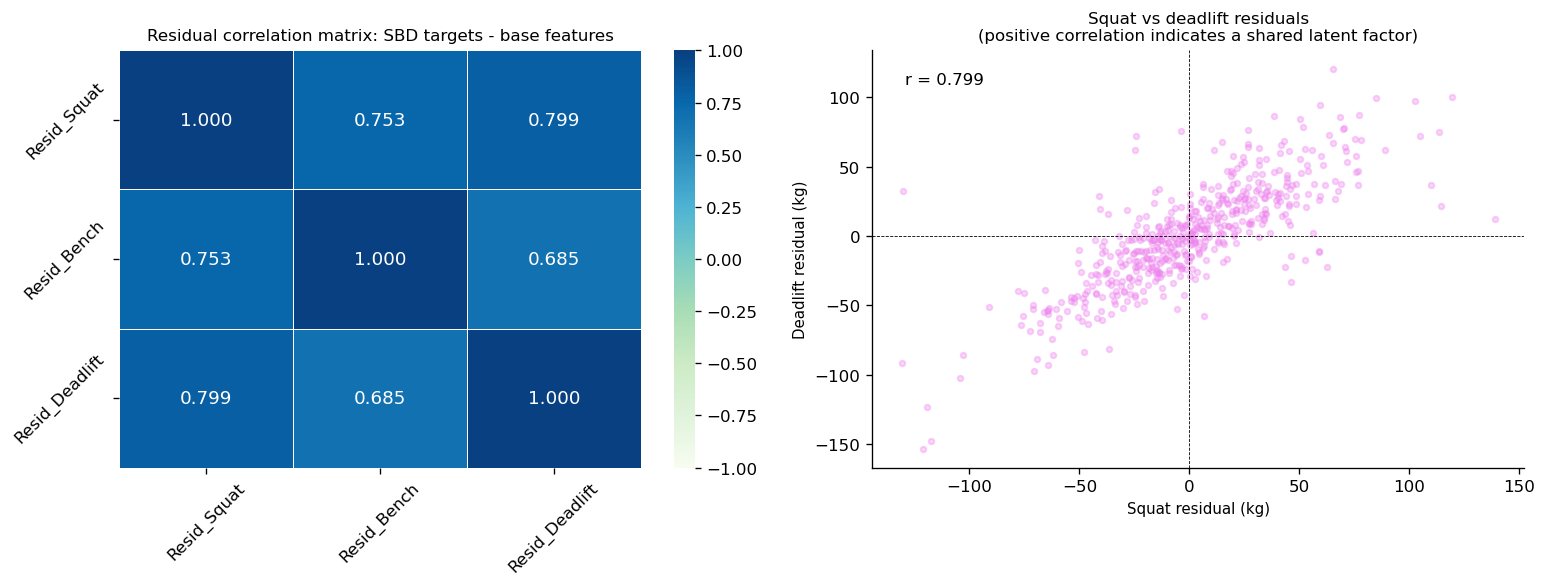

In [60]:
resid_base_sbd_df = pd.DataFrame(
    residuals_base_sbd,
    columns = ['Resid_Squat', 'Resid_Bench', 'Resid_Deadlift']
)

resid_corr_base_sbd = resid_base_sbd_df.corr()

print('Residual correlation matrix: SBD targets - base features')
print(resid_corr_base_sbd.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    resid_corr_base_sbd,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'GnBu',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = axes[0],
    linewidths = 0.5,
    annot_kws  = {'size': 11}
)
axes[0].set_title('Residual correlation matrix: SBD targets - base features',
                  fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=45) 
axes[0].set_xticklabels(axes[0].get_yticklabels(), rotation=45) 

r_val_base_sbd = resid_corr_base_sbd.loc['Resid_Squat', 'Resid_Deadlift']

axes[1].scatter(
    residuals_base_sbd[:, 0], residuals_base_sbd[:, 2],
    alpha=0.35, s=12, color='violet'
)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('Squat residual (kg)', fontsize=9)
axes[1].set_ylabel('Deadlift residual (kg)', fontsize=9)
axes[1].set_title(
    'Squat vs deadlift residuals\n'
    '(positive correlation indicates a shared latent factor)',
    fontsize=10
)
axes[1].text(
    0.05, 0.92, f'r = {r_val_base_sbd:.3f}',
    transform = axes[1].transAxes, fontsize=10
)

plt.tight_layout()
plt.savefig(plots_dir_p4 / 'residual_correlation_base_sbd.png', bbox_inches='tight')
plt.show()

Residual correlation matrix: SBD targets - age-augmented features
                Resid_Squat  Resid_Bench  Resid_Deadlift
Resid_Squat            1.00         0.67            0.79
Resid_Bench            0.67         1.00            0.64
Resid_Deadlift         0.79         0.64            1.00


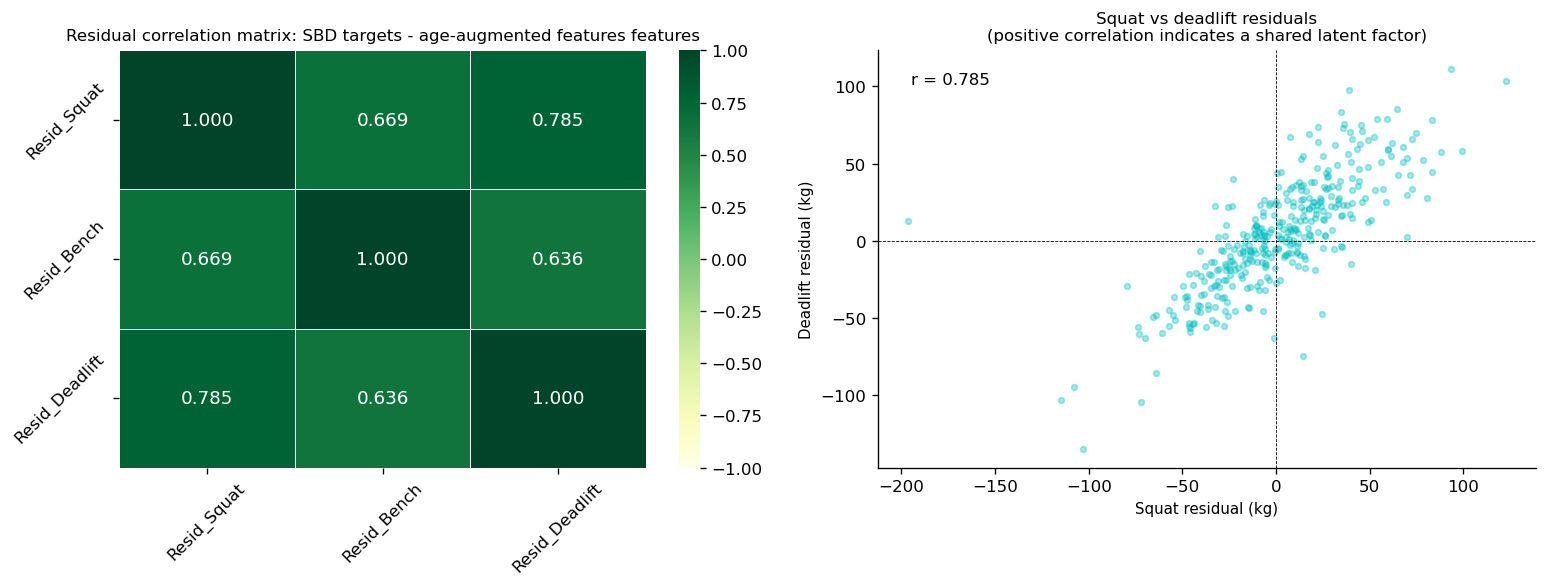

In [61]:
resid_age_sbd_df = pd.DataFrame(
    residuals_age_sbd,
    columns = ['Resid_Squat', 'Resid_Bench', 'Resid_Deadlift']
)

resid_corr_age_sbd = resid_age_sbd_df.corr()

print('Residual correlation matrix: SBD targets - age-augmented features')
print(resid_corr_age_sbd.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    resid_corr_age_sbd,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'YlGn',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = axes[0],
    linewidths = 0.5,
    annot_kws  = {'size': 11}
)
axes[0].set_title('Residual correlation matrix: SBD targets - age-augmented features features',
                  fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=45) 
axes[0].set_xticklabels(axes[0].get_yticklabels(), rotation=45) 

r_val_age_sbd = resid_corr_age_sbd.loc['Resid_Squat', 'Resid_Deadlift']

axes[1].scatter(
    residuals_age_sbd[:, 0], residuals_age_sbd[:, 2],
    alpha=0.35, s=12, color='c'
)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('Squat residual (kg)', fontsize=9)
axes[1].set_ylabel('Deadlift residual (kg)', fontsize=9)
axes[1].set_title(
    'Squat vs deadlift residuals\n'
    '(positive correlation indicates a shared latent factor)',
    fontsize=10
)
axes[1].text(
    0.05, 0.92, f'r = {r_val_age_sbd:.3f}',
    transform = axes[1].transAxes, fontsize=10
)

plt.tight_layout()
plt.savefig(plots_dir_p4 / 'residual_correlation_age_sbd.png', bbox_inches='tight')
plt.show()

# PHASE 5: GRADIENT BOOSTING

**Goal:** Explore the possibility of creating a model with better predictive accuracy on the structured data than the linear models used so far. 

**Motivation:** Phase 4 established that the linear models were underfitting; high bias. The pattern of gains XGBoost showed in Phase 5's baseline comparison — concentrated in age-augmented targets — suggested a specific mechanism: the relationship of age with performance is -quite likely- non-monotonic; young lifters advancing rapidly, a plateau somewhere in the late 20s to 30s, then decline in performance. A linear model, e.g OLS, can only fit that as a straight-line. A tree-based model can split at different age thresholds and capture those curve shapes faithfully. It is important to note that this limitation has to do with the inner workings of a linear model, and is independent of how well-conditioned the matrix is.

**Approach:** Learning curves for TotalKg and SBD targets; classical models. This establishes the baseline shape against which the gradient boosting has to be compared. Baseline (untuned) XGBoost vs OLS/Ridge as a test of whether the boosting helped before investing any tuning effort. Optuna hyperparameter seach for all four targets; 100 trials per target/variant, TPE sampler, search space biased toward shallow trees to counteract overfitting on a small dataset. Fit final tuned models on the full training split. Evaluate tuned models using stratified CV; per-sex breakdown. This tests if boosting narrowed the sex-related gaps revealed in Phase 4. Learning curves for tuned XGBoost and a comaprison against the classical models; a direct visual test of the changes due to boosting in the bias-vairance regime. SHAP analysis as a direct test of the non-linear relation of age hypothesised above, with the Age SHAP dependence plots confirming the non-monotonic shape across all four targets, namely a steep rise through the mid-20s, a plateau through the early 30s, and a consistent decline thereafter. 

## Cell 50 — Create output folder and environment check

In [62]:
# Create the Phase 5 plots folder
plots_dir_p5 = Path('plots/phase5')
plots_dir_p5.mkdir(parents=True, exist_ok=True)
print(f"Plot output folder: {plots_dir_p5.resolve()}")

Plot output folder: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase5


In [63]:
# Verify required packages
import subprocess
import sys

required_packages = ['xgboost', 'optuna', 'shap']

for pkg in required_packages:
    try:
        __import__(pkg)
        version = __import__(pkg).__version__
        print(f"  {pkg:<12} OK  (version {version})")
    except ImportError:
        print(f"  {pkg:<12} MISSING — installing...")
        subprocess.check_call([sys.executable, '-m', 'pip',
                               'install', pkg, '-q'])
        print(f"  {pkg:<12} installed")

import xgboost as xgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"All packages ready.")

  xgboost      OK  (version 3.2.0)
  optuna       OK  (version 4.7.0)
  shap         OK  (version 0.51.0)
All packages ready.


## Cell 51 — Learning curves: all four targets

Learning curves show how training and CV RMSE change as training set size increases. This diagnoses the bias-variance regime:

Both curves plateau at high RMSE with small gap between them

   → high bias (underfitting) — adding more data will not help much

Large gap between train and CV curves

   → high variance (overfitting) — more data or stronger regularization needed

We show OLS and Ridge for all four targets in two 2×4 grids.

**Note:** learning_curve does not accept a separate stratification array, so we use KFold here. The sex imbalance may inflate fold variance slightly but does not change the qualitative conclusion.

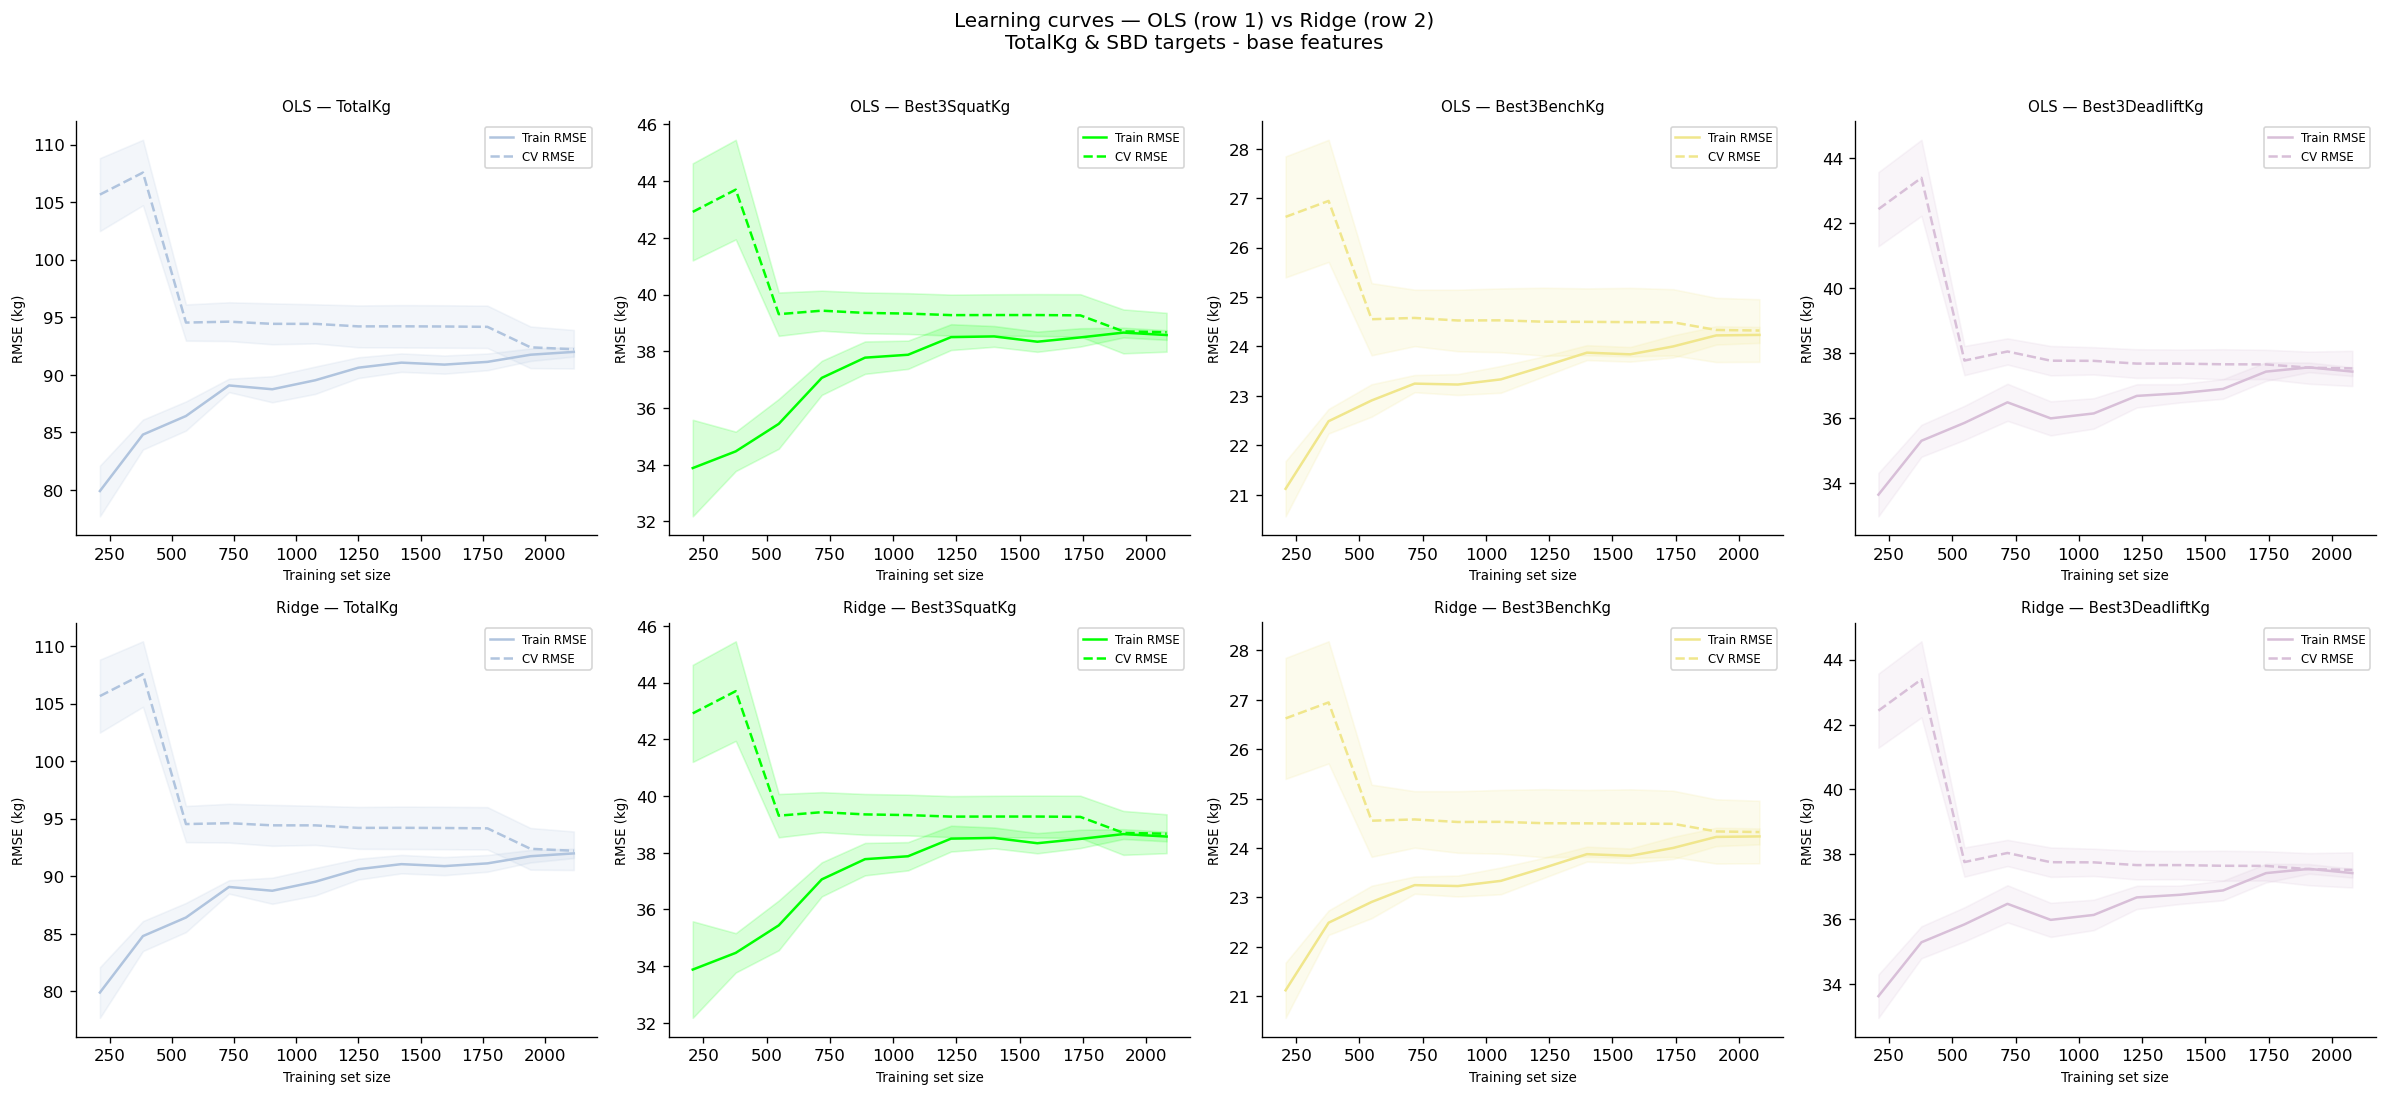

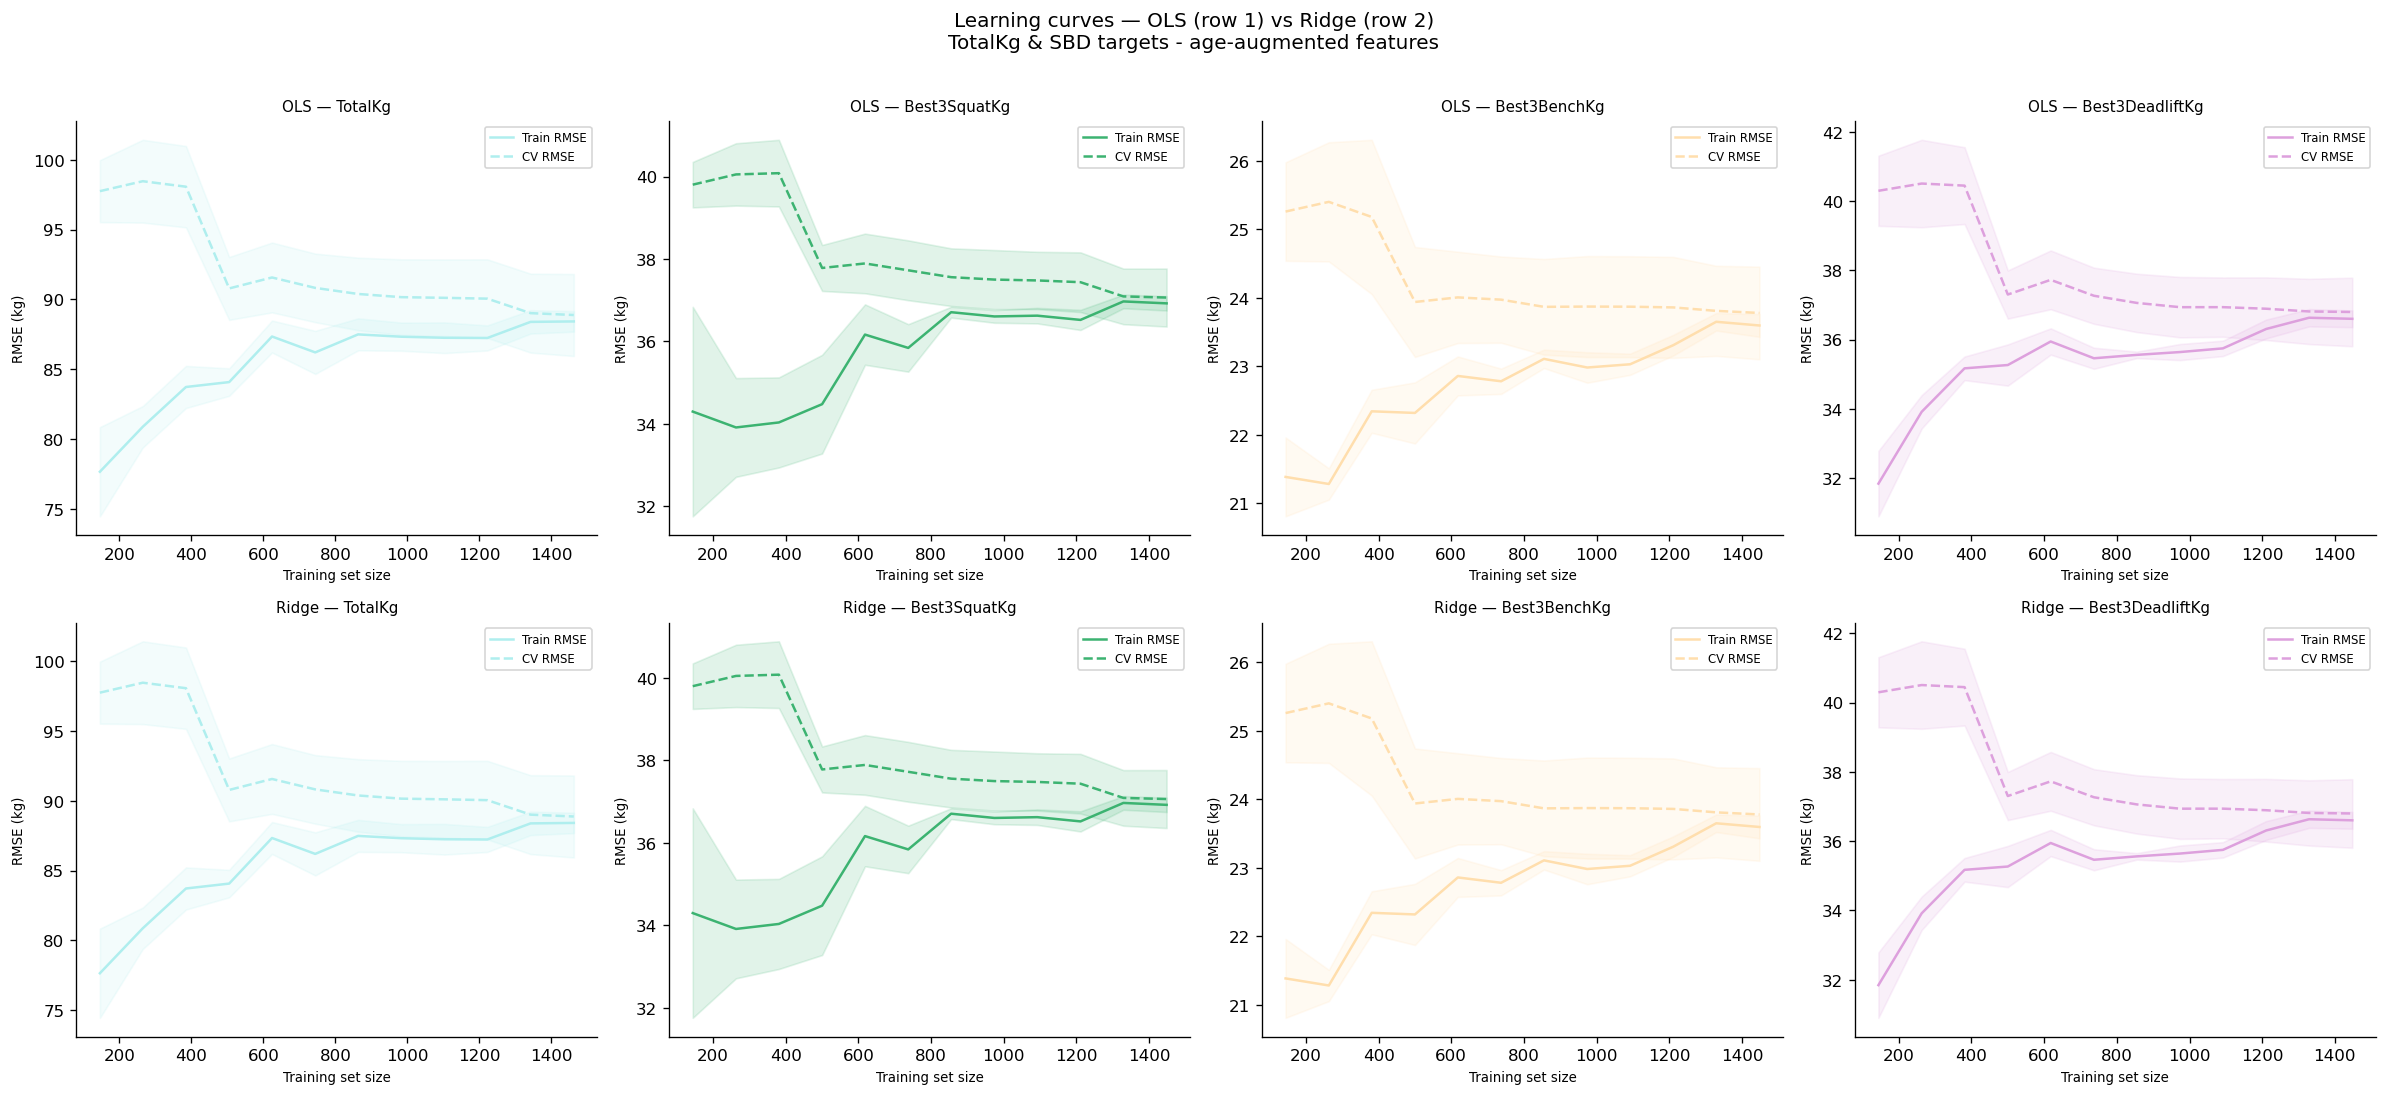

In [64]:
from sklearn.model_selection import learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler as SS

kf_lc       = KFold(n_splits = 5, shuffle = True, random_state = 42)
train_sizes = np.linspace(0.1, 1.0, 12)

def compute_learning_curve(X, Y, model, train_sizes, kf):
    """
    Compute learning curve for a given model.
    Scaling is handled inside the pipeline to prevent leakage.
    Returns train_sizes, train_mean, train_std, cv_mean, cv_std.
    """
    Y_1d = Y.ravel() if (Y.ndim == 2 and Y.shape[1] == 1) else Y

    ts, tr_scores, cv_scores = learning_curve(
        model,
        X, Y_1d,
        train_sizes = train_sizes,
        cv          = kf,
        scoring     = 'neg_root_mean_squared_error',
        n_jobs      = -1
    )

    tr_mean = -tr_scores.mean(axis=1)
    tr_std  =  tr_scores.std(axis=1)
    cv_mean = -cv_scores.mean(axis=1)
    cv_std  =  cv_scores.std(axis=1)

    return ts, tr_mean, tr_std, cv_mean, cv_std

def plot_single_lc(ax, ts, tr_mean, tr_std, cv_mean, cv_std,
                   title, color):
    """Plot one learning curve panel with shaded confidence bands."""
    ax.plot(ts, tr_mean, color=color, linewidth=1.5, label='Train RMSE')
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=color)
    ax.plot(ts, cv_mean, color=color, linewidth=1.5,
            linestyle='--', label='CV RMSE')
    ax.fill_between(ts, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.15, color=color)
    ax.set_xlabel('Training set size', fontsize=8)
    ax.set_ylabel('RMSE (kg)', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(2, 4, figsize=(20, 9))
lc_colours = ['lightsteelblue', 'lime', 'khaki', 'thistle']

# Models with scaling pipeline
pipe_ols_base_total   = Pipeline([('scaler', SS()),
                              ('model',  LinearRegression())])
pipe_ridge_base_total = Pipeline([('scaler', SS()),
                              ('model',  SkRidge(alpha=ridge_lam_base_total))])
pipe_ols_age_total    = Pipeline([('scaler', SS()),
                              ('model',  LinearRegression())])
pipe_ridge_age_total  = Pipeline([('scaler', SS()),
                              ('model',  SkRidge(alpha=ridge_lam_age_total))])

pipe_ols_base_sbd            = Pipeline([('scaler', SS()),
                              ('model',  LinearRegression())])
pipe_ridge_base_sbd          = Pipeline([('scaler', SS()),
                              ('model',  SkRidge(alpha = ridge_lam_base_sbd))])
pipe_ols_age_sbd            = Pipeline([('scaler', SS()),
                              ('model',  LinearRegression())])
pipe_ridge_age_sbd          = Pipeline([('scaler', SS()),
                              ('model',  SkRidge(alpha = ridge_lam_age_sbd))])

num_targets = len(all_targets_list)

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    X_np = X_base_total_np if target == "TotalKg" else X_base_sbd_np
    Y_np = Y_base_total_np if target == "TotalKg" else Y_base_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_base_sbd_np[:, t_idx]   

    pipe_model_base_ols = pipe_ols_base_total if target == "TotalKg" else pipe_ols_base_sbd
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, pipe_model_base_ols, train_sizes, kf_lc
    )

    plot_single_lc(
        axes[0, col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"OLS — {target}",
        colour,
    )

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    X_np = X_base_total_np if target == "TotalKg" else X_base_sbd_np
    Y_np = Y_base_total_np if target == "TotalKg" else Y_base_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_base_sbd_np[:, t_idx] 

    pipe_model_base_ridge = pipe_ridge_base_total if target == "TotalKg" else pipe_ridge_base_sbd
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, pipe_model_base_ridge, train_sizes, kf_lc
    )

    plot_single_lc(
        axes[1, col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"Ridge — {target}",
        colour,
    )

plt.suptitle(
    "Learning curves — OLS (row 1) vs Ridge (row 2)\n"
    "TotalKg & SBD targets - base features",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p5 / "learning_curves_base.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
lc_colours = ['paleturquoise', 'mediumseagreen', 'navajowhite', 'plum']

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    X_np = X_age_total_np if target == "TotalKg" else X_age_sbd_np
    Y_np = Y_age_total_np if target == "TotalKg" else Y_age_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_age_sbd_np[:, t_idx]   

    pipe_model_age_ols = pipe_ols_age_total if target == "TotalKg" else pipe_ols_age_sbd
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, pipe_model_age_ols, train_sizes, kf_lc
    )

    plot_single_lc(
        axes[0, col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"OLS — {target}",
        colour,
    )

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    X_np = X_age_total_np if target == "TotalKg" else X_age_sbd_np
    Y_np = Y_age_total_np if target == "TotalKg" else Y_age_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_age_sbd_np[:, t_idx] 

    pipe_model_age_ridge = pipe_ridge_age_total if target == "TotalKg" else pipe_ridge_age_sbd
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, pipe_model_age_ridge, train_sizes, kf_lc
    )

    plot_single_lc(
        axes[1, col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"Ridge — {target}",
        colour,
    )

plt.suptitle(
    "Learning curves — OLS (row 1) vs Ridge (row 2)\n"
    "TotalKg & SBD targets - age-augmented features",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.savefig(plots_dir_p5 / "learning_curves_age.png", bbox_inches="tight")
plt.show() 

## Cell 52 — Baseline XGBoost: all targets 

Before tuning, establish a baseline with sensible default parameters. This tells us the starting point and how much tuning can potentially gain.

We use StratifiedKFold by sex for consistency with Phase 3 CV results. XGBoost does not require feature scaling — tree splits are invariant to monotone transformations of feature values.

For SBD targets we fit one model per target per fold — XGBoost has no native multi-output support unlike Ridge.

**Important note:** every age-augmented target shows a real, non-trivial gain; TotalKg −6.67 kg, Squat −1.61, Bench −1.47, and Deadlift −2.59. That's not noise, but rather a consistent pattern across the four targets. The base-feature set, by contrast, shows only small or negligible gains. That asymmetry — real improvement only when Age is present. 

This leads to the following reasonable claim: the relationship of age with strength performance is very plausibly **non-monotonic** — young lifters improving rapidly, a plateau somewhere in the late 20s to 30s, then decline — and OLS can only fit that as one straight-line coefficient. A tree-based model can split at different age thresholds and capture that curve shape directly, which a linear model structurally cannot, no matter how well-conditioned the matrix is.

In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Stratification labels
sex_labels_base_total = X_base_total['Sex_binary'].values
sex_labels_age_total  = X_age_total['Sex_binary'].values
sex_labels_base_sbd   = X_base_sbd['Sex_binary'].values
sex_labels_age_sbd    = X_age_sbd['Sex_binary'].values

# Baseline hyperparameters — not tuned
baseline_params = dict(
    n_estimators     = 300,
    learning_rate    = 0.1,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0
)

def xgb_cv_single(X, Y_1d, strat_labels, params, skf):
    """
    Stratified 5-fold CV for a single XGBoost target.
    Returns array of per-fold RMSE values.
    """
    fold_rmses = []

    for tr_idx, te_idx in skf.split(X, strat_labels):
        X_tr  = X[tr_idx]
        X_te  = X[te_idx]
        y_tr  = Y_1d[tr_idx]
        y_te  = Y_1d[te_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_te)
        fold_rmses.append(
            np.sqrt(mean_squared_error(y_te, y_pred))
        )

    folded_rmse_array = np.array(fold_rmses) 
    
    return folded_rmse_array 

# TotalKg baseline - base features 
xgb_base_total_folds = xgb_cv_single(
    X_base_total_np, Y_base_total_np.ravel(),
    sex_labels_base_total, baseline_params, skf5
) 

# TotalKg baseline - age-augmented features 
xgb_age_total_folds = xgb_cv_single(
    X_age_total_np, Y_age_total_np.ravel(),
    sex_labels_age_total, baseline_params, skf5
) 

# SBD targets baseline - base features  
xgb_base_sbd_folds = {}
for i, target in enumerate(target_names_sbd):
    xgb_base_sbd_folds[target] = xgb_cv_single(
        X_base_sbd_np, Y_base_sbd_np[:, i],
        sex_labels_base_sbd, baseline_params, skf5
    )

# SBD targets baseline - age-augmented features  
xgb_age_sbd_folds = {}
for i, target in enumerate(target_names_sbd):
    xgb_age_sbd_folds[target] = xgb_cv_single(
        X_age_sbd_np, Y_age_sbd_np[:, i],
        sex_labels_age_sbd, baseline_params, skf5
    )

# Reference values from Phase 3 - stratified CV
ols_cv_base_total = strat_results_base_total['OLS'].mean()
ols_cv_base_sbd   = {target: strat_results_base_sbd['OLS'].mean(axis = 0)[i] for i, target in enumerate(target_names_sbd)}
ols_cv_age_total  = strat_results_age_total['OLS'].mean()
ols_cv_age_sbd    = {target: strat_results_age_sbd['OLS'].mean(axis = 0)[i] for i, target in enumerate(target_names_sbd)}

ridge_cv_base_total = strat_results_base_total['Ridge'].mean()
ridge_cv_base_sbd   = {target: strat_results_base_sbd['Ridge'].mean(axis = 0)[i] for i, target in enumerate(target_names_sbd)}
ridge_cv_age_total  = strat_results_age_total['Ridge'].mean()
ridge_cv_age_sbd    = {target: strat_results_age_sbd['Ridge'].mean(axis = 0)[i] for i, target in enumerate(target_names_sbd)}

print('Baseline XGBoost vs OLS vs Ridge - base features')
print(f"{'Target':<26} {'XGB base':>10} {'XGB std':>8} "
      f"{'OLS CV':>10} {'Delta_OLS':>8} {'Ridge CV':>10} {'Delta_Ridge':>8}")
print(2 * bsep)

xgb_base_mean_total = xgb_base_total_folds.mean()
xgb_base_std_total  = xgb_base_total_folds.std()
delta_total_ols     = xgb_base_mean_total - ols_cv_base_total
delta_total_ridge   = xgb_base_mean_total - ridge_cv_base_total

print(f"  {'TotalKg':<24} {xgb_base_mean_total:>10.2f} "
      f"{xgb_base_std_total:>8.2f} "
      f"{ols_cv_base_total:>10.2f} {delta_total_ols:>+8.2f}"
      f"{ridge_cv_base_total:>10.2f} {delta_total_ridge:>+8.2f}")

for target in target_names_sbd:
    xgb_mean    = xgb_base_sbd_folds[target].mean()
    xgb_std     = xgb_base_sbd_folds[target].std()
    ols_r       = ols_cv_base_sbd[target]
    ridge_r     = ridge_cv_base_sbd[target]
    delta_ols   = xgb_mean - ols_r
    delta_ridge = xgb_mean - ridge_r
    print(f"  {target:<24} {xgb_mean:>10.2f} "
          f"{xgb_std:>8.2f} "
          f"{ols_r:>10.2f} {delta_ols:>+8.2f}"
          f"{ridge_r:>10.2f} {delta_ridge:>+8.2f}")

print('\n') 

print('Baseline XGBoost vs OLS vs Ridge - age-augmented features')
print(f"{'Target':<26} {'XGB base':>10} {'XGB std':>8} "
      f"{'OLS CV':>10} {'Delta_OLS':>8} {'Ridge CV':>10} {'Delta_Ridge':>8}")
print(2 * bsep)

xgb_age_mean_total = xgb_age_total_folds.mean()
xgb_age_std_total  = xgb_age_total_folds.std()
delta_total_ols     = xgb_age_mean_total - ols_cv_age_total
delta_total_ridge   = xgb_age_mean_total - ridge_cv_age_total

print(f"  {'TotalKg':<24} {xgb_age_mean_total:>10.2f} "
      f"{xgb_age_std_total:>8.2f} "
      f"{ols_cv_age_total:>10.2f} {delta_total_ols:>+8.2f}"
      f"{ridge_cv_age_total:>10.2f} {delta_total_ridge:>+8.2f}")

for target in target_names_sbd:
    xgb_mean    = xgb_age_sbd_folds[target].mean()
    xgb_std     = xgb_age_sbd_folds[target].std()
    ols_r       = ols_cv_age_sbd[target]
    ridge_r     = ridge_cv_age_sbd[target]
    delta_ols   = xgb_mean - ols_r
    delta_ridge = xgb_mean - ridge_r
    print(f"  {target:<24} {xgb_mean:>10.2f} "
          f"{xgb_std:>8.2f} "
          f"{ols_r:>10.2f} {delta_ols:>+8.2f}"
          f"{ridge_r:>10.2f} {delta_ridge:>+8.2f}")

Baseline XGBoost vs OLS vs Ridge - base features
Target                       XGB base  XGB std     OLS CV Delta_OLS   Ridge CV Delta_Ridge
  TotalKg                       91.50     1.83      92.17    -0.66     92.17    -0.66
  Best3SquatKg                  38.99     2.20      38.69    +0.30     38.69    +0.30
  Best3BenchKg                  24.25     1.00      24.31    -0.07     24.31    -0.07
  Best3DeadliftKg               37.22     1.51      37.50    -0.28     37.50    -0.28


Baseline XGBoost vs OLS vs Ridge - age-augmented features
Target                       XGB base  XGB std     OLS CV Delta_OLS   Ridge CV Delta_Ridge
  TotalKg                       82.23     3.71      88.90    -6.67     88.90    -6.67
  Best3SquatKg                  35.57     1.02      37.18    -1.61     37.18    -1.61
  Best3BenchKg                  22.27     1.00      23.75    -1.47     23.75    -1.47
  Best3DeadliftKg               34.28     0.63      36.87    -2.59     36.87    -2.59


## Cell 53 — Optuna tuning: TotalKg  

Optuna uses Bayesian optimisation via the TPE (Tree-structured Parzen Estimator) sampler. At each trial it fits two density estimators:

1.   l(x) — density of configurations that gave good results
2.   g(x) — density of configurations that gave poor results
and samples from l(x)/g(x), concentrating search in promising regions.

The search space is biased toward simpler models to counteract overfitting:
1. max_depth 2-6 (shallow trees)
2. min_child_weight up to 20 (prevents splits on small groups)
3. reg_alpha, reg_lambda (L1/L2 on leaf weights)

In [66]:
def objective_base_total(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate    = trial.suggest_float('learning_rate',
                                               0.005, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 2, 6),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha',
                                               1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',
                                               1e-4, 10.0, log=True),
        random_state     = 42,
        verbosity        = 0
    )

    fold_rmses = []

    for tr_idx, te_idx in skf5.split(X_base_total_np, sex_labels_base_total):
        X_tr  = X_base_total_np[tr_idx]
        X_te  = X_base_total_np[te_idx]
        y_tr  = Y_base_total_np[tr_idx].ravel()
        y_te  = Y_base_total_np[te_idx].ravel()

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr,
                  eval_set  = [(X_te, y_te)],
                  verbose   = False)

        y_pred = model.predict(X_te)
        fold_rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    mean_folded_rmses = np.mean(fold_rmses)

    return mean_folded_rmses


study_base_total = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42)
)
study_base_total.optimize(objective_base_total, n_trials=100,
                     show_progress_bar=True)

best_params_base_total = study_base_total.best_params.copy()
best_params_base_total.update({'random_state': 42, 'verbosity': 0})

print(f'Optuna results: TotalKg - base features')
print(f"  Best CV RMSE:              {study_base_total.best_value:.2f} kg")
print(f"  Baseline XGBoost:          {xgb_base_mean_total:.2f} kg")
print(f"  OLS :                      {ols_cv_base_total:.2f} kg")
print(f"  Ridge :                    {ridge_cv_base_total:.2f} kg")
print(f"  Improvement over baseline: "
      f"{xgb_base_mean_total - study_base_total.best_value:+.2f} kg")
print(f"  Improvement over OLS:    "
      f"  {ols_cv_base_total - study_base_total.best_value:+.2f} kg")
print(f"  Improvement over Ridge:    "
      f"{ridge_cv_base_total - study_base_total.best_value:+.2f} kg")
print(f"\n  Best hyperparameters:")
for k, v in study_base_total.best_params.items():
    print(f"    {k:<22} {v}")

print(bsep) 

def objective_age_total(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate    = trial.suggest_float('learning_rate',
                                               0.005, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 2, 6),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha',
                                               1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',
                                               1e-4, 10.0, log=True),
        random_state     = 42,
        verbosity        = 0
    )

    fold_rmses = []

    for tr_idx, te_idx in skf5.split(X_age_total_np, sex_labels_age_total):
        X_tr  = X_age_total_np[tr_idx]
        X_te  = X_age_total_np[te_idx]
        y_tr  = Y_age_total_np[tr_idx].ravel()
        y_te  = Y_age_total_np[te_idx].ravel()

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr,
                  eval_set  = [(X_te, y_te)],
                  verbose   = False)

        y_pred = model.predict(X_te)
        fold_rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))

    mean_folded_rmses = np.mean(fold_rmses)

    return mean_folded_rmses


study_age_total = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42)
)
study_age_total.optimize(objective_age_total, n_trials=100,
                     show_progress_bar=True)

best_params_age_total = study_age_total.best_params.copy()
best_params_age_total.update({'random_state': 42, 'verbosity': 0})

print(f'Optuna results: TotalKg - age-augmented features')
print(f"  Best CV RMSE:              {study_age_total.best_value:.2f} kg")
print(f"  Baseline XGBoost:          {xgb_age_mean_total:.2f} kg")
print(f"  OLS :                      {ols_cv_age_total:.2f} kg")
print(f"  Ridge :                    {ridge_cv_age_total:.2f} kg")
print(f"  Improvement over baseline: "
      f"{xgb_age_mean_total - study_age_total.best_value:+.2f} kg")
print(f"  Improvement over OLS:    "
      f"  {ols_cv_age_total - study_age_total.best_value:+.2f} kg")
print(f"  Improvement over Ridge:    "
      f"{ridge_cv_age_total - study_age_total.best_value:+.2f} kg")
print(f"\n  Best hyperparameters:")
for k, v in study_age_total.best_params.items():
    print(f"    {k:<22} {v}")

  0%|          | 0/100 [00:00<?, ?it/s]

Optuna results: TotalKg - base features
  Best CV RMSE:              88.90 kg
  Baseline XGBoost:          91.50 kg
  OLS :                      92.17 kg
  Ridge :                    92.17 kg
  Improvement over baseline: +2.61 kg
  Improvement over OLS:      +3.27 kg
  Improvement over Ridge:    +3.27 kg

  Best hyperparameters:
    n_estimators           865
    learning_rate          0.01057278212275702
    max_depth              3
    min_child_weight       5
    subsample              0.897468931884667
    colsample_bytree       0.9380998439154907
    reg_alpha              4.818425054403804
    reg_lambda             5.199782310005262


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna results: TotalKg - age-augmented features
  Best CV RMSE:              79.92 kg
  Baseline XGBoost:          82.23 kg
  OLS :                      88.90 kg
  Ridge :                    88.90 kg
  Improvement over baseline: +2.31 kg
  Improvement over OLS:      +8.98 kg
  Improvement over Ridge:    +8.98 kg

  Best hyperparameters:
    n_estimators           826
    learning_rate          0.012731654636830573
    max_depth              6
    min_child_weight       8
    subsample              0.9178262394508081
    colsample_bytree       0.550209297512699
    reg_alpha              0.04794476014302222
    reg_lambda             9.942053265805118


## Cell 54 — Optuna tuning: SBD targets  

We tune one Optuna study per target since each lift may have different optimal complexity — Phase 3's Ridge sweep found identical optimal λ (0.001, the grid floor) across all targets under linear regularization, but that doesn't guarantee gradient boosting's optimal tree depth, learning rate, or regularization will also be uniform across lifts, since boosting captures a different kind of structure (as this phase's Motivation argues for Age).

**A caveat:** Optuna's 100 trials optimize directly against the same 5 CV folds used to report the final RMSE; this is a mild form of leakage (the folds have effectively been searched, not just evaluated), so the reported improvement is likely a modest overestimate of true generalization gain. A held-out validation split or nested CV would give an unbiased estimate, but was judged not worth the added complexity for this project.

**Important note:** tuned XGBoost beats the untuned baseline, and furthermore untuned XGBoost already outperformed Ridge in every case. Hence, tuned XGBoost beating Ridge by −0.84 to −3.66 kg follows the same pattern as TotalKg; modest gains on base features with larger gains on age-augmented features. 

This finding confirms the age-nonlinearity hypothesis: every single age-augmented target shows a bigger improvement than its base-features counterpart (−2.90 vs −0.91 for Squat, −2.34 vs −0.84 for Bench, −3.66 vs −1.57 for Deadlift). This is the exact expected pattern if trees are specifically exploiting the non-monotonic age structure that OLS can't represent.

In [67]:
def make_base_sbd_objective(target_idx):
    """
    Returns an Optuna objective function for one SBD target.
    Using a closure captures target_idx without a global variable.
    """
    def objective_base(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
            learning_rate    = trial.suggest_float('learning_rate',
                                                   0.005, 0.3, log=True),
            max_depth        = trial.suggest_int('max_depth', 2, 6),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',
                                                   0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',
                                                   1e-4, 10.0, log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',
                                                   1e-4, 10.0, log=True),
            random_state     = 42,
            verbosity        = 0
        )

        fold_rmses = []

        for tr_idx, te_idx in skf5.split(X_base_sbd_np, sex_labels_base_sbd):
            X_tr  = X_base_sbd_np[tr_idx]
            X_te  = X_base_sbd_np[te_idx]
            y_tr  = Y_base_sbd_np[tr_idx, target_idx]
            y_te  = Y_base_sbd_np[te_idx, target_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      eval_set  = [(X_te, y_te)],
                      verbose   = False)

            y_pred = model.predict(X_te)
            fold_rmses.append(
                np.sqrt(mean_squared_error(y_te, y_pred))
            )

        mean_folded_rmses = np.mean(fold_rmses)
        
        return mean_folded_rmses

    return objective_base


best_params_base_sbd = {}
studies_base_sbd     = {}

for i, target in enumerate(target_names_sbd):
    print(f"Tuning {target}...")

    study_base_sbd = optuna.create_study(
        direction = 'minimize',
        sampler   = optuna.samplers.TPESampler(seed=42)
    )
    study_base_sbd.optimize(make_base_sbd_objective(i), n_trials=100,
                   show_progress_bar=True)

    params_base_sbd = study_base_sbd.best_params.copy()
    params_base_sbd.update({'random_state': 42, 'verbosity': 0})

    best_params_base_sbd[target] = params_base_sbd
    studies_base_sbd[target]     = study_base_sbd

    print(f"  Best CV RMSE: {study_base_sbd.best_value:.2f} kg")


print('Optuna results: SBD targets - base features')
print(f"{'Target':<26} {'Tuned XGB':>10} {'Base XGB':>10} "
      f"{'Ridge CV':>10} {'vs Ridge':>8}")
print('─' * 68)

for target in target_names_sbd:
    tuned    = studies_base_sbd[target].best_value
    base     = xgb_base_sbd_folds[target].mean()
    ridge_r  = ridge_cv_base_sbd[target]
    vs_ridge = tuned - ridge_r 
    print(f"  {target:<24} {tuned:>10.2f} {base:>10.2f} "
          f"{ridge_r:>10.2f} {vs_ridge:>+8.2f}")

print('Best hyperparameters per SBD target')
for target in target_names_sbd:
    print(f'\n  {target}:')
    for k, v in studies_base_sbd[target].best_params.items():
        print(f"    {k:<22} {v}")

print(bsep)

def make_age_sbd_objective(target_idx):
    """
    Returns an Optuna objective function for one SBD target.
    Using a closure captures target_idx without a global variable.
    """
    def objective_age(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
            learning_rate    = trial.suggest_float('learning_rate',
                                                   0.005, 0.3, log=True),
            max_depth        = trial.suggest_int('max_depth', 2, 6),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',
                                                   0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',
                                                   1e-4, 10.0, log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',
                                                   1e-4, 10.0, log=True),
            random_state     = 42,
            verbosity        = 0
        )

        fold_rmses = []

        for tr_idx, te_idx in skf5.split(X_age_sbd_np, sex_labels_age_sbd):
            X_tr  = X_age_sbd_np[tr_idx]
            X_te  = X_age_sbd_np[te_idx]
            y_tr  = Y_age_sbd_np[tr_idx, target_idx]
            y_te  = Y_age_sbd_np[te_idx, target_idx]

            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr,
                      eval_set  = [(X_te, y_te)],
                      verbose   = False)

            y_pred = model.predict(X_te)
            fold_rmses.append(
                np.sqrt(mean_squared_error(y_te, y_pred))
            )

        mean_folded_rmses = np.mean(fold_rmses)
        
        return mean_folded_rmses

    return objective_age


best_params_age_sbd = {}
studies_age_sbd     = {}

for i, target in enumerate(target_names_sbd):
    print(f"Tuning {target}...")

    study_age_sbd = optuna.create_study(
        direction = 'minimize',
        sampler   = optuna.samplers.TPESampler(seed=42)
    )
    study_age_sbd.optimize(make_age_sbd_objective(i), n_trials=100,
                   show_progress_bar=True)

    params_age_sbd = study_age_sbd.best_params.copy()
    params_age_sbd.update({'random_state': 42, 'verbosity': 0})

    best_params_age_sbd[target] = params_age_sbd
    studies_age_sbd[target]     = study_age_sbd

    print(f"  Best CV RMSE: {study_age_sbd.best_value:.2f} kg")


print('Optuna results: SBD targets - age-augmented features')
print(f"{'Target':<26} {'Tuned XGB':>10} {'Base XGB':>10} "
      f"{'Ridge CV':>10} {'vs Ridge':>8}")
print('─' * 68)

for target in target_names_sbd:
    tuned    = studies_age_sbd[target].best_value
    base     = xgb_age_sbd_folds[target].mean()
    ridge_r  = ridge_cv_age_sbd[target]
    vs_ridge = tuned - ridge_r
    print(f"  {target:<24} {tuned:>10.2f} {base:>10.2f} "
          f"{ridge_r:>10.2f} {vs_ridge:>+8.2f}")

print('Best hyperparameters per SBD target')
for target in target_names_sbd:
    print(f'\n  {target}:')
    for k, v in studies_age_sbd[target].best_params.items():
        print(f"    {k:<22} {v}")

Tuning Best3SquatKg...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 37.78 kg
Tuning Best3BenchKg...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 23.47 kg
Tuning Best3DeadliftKg...


...

  Best CV RMSE: 34.28 kg
Tuning Best3BenchKg...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 21.41 kg
Tuning Best3DeadliftKg...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 33.21 kg
Optuna results: SBD targets - age-augmented features
Target                      Tuned XGB   Base XGB   Ridge CV vs Ridge
────────────────────────────────────────────────────────────────────
  Best3SquatKg                  34.28      35.57      37.18    -2.90
  Best3BenchKg                  21.41      22.27      23.75    -2.34
  Best3DeadliftKg               33.21      34.28      36.87    -3.66
Best hyperparameters per SBD target

  Best3SquatKg:
    n_estimators           378
    learning_rate          0.016250324085532054
    max_depth              4
    min_child_weight       6
    subsample              0.6428874022737932
    colsample_bytree       0.7032301483370633
    reg_alpha              0.0456708881751499
    reg_lambda             0.00016505259064064707

  Best3BenchKg:
    n_estimators           738
    learning_rate          0.00555419148963375
    max_depth              5
    min_child_weight       3
    subsample              0.6458342278968919


## Cell 55 — Fit final tuned models 

Fit tuned models on the full training split for SHAP and the strength standards tool. We use unscaled features throughout Phase 5 — XGBoost does not require scaling, and unscaled feature values make SHAP plots directly interpretable in original units.

In [68]:
# Feature name lists
feature_names_base_total = list(X_tr_base_total.columns)
feature_names_age_total = list(X_tr_age_total.columns)
feature_names_base_sbd   = list(X_tr_base_sbd.columns)
feature_names_age_sbd   = list(X_tr_age_sbd.columns)

# Fit on train split
# TotalKg; base features
xgb_final_base_total = xgb.XGBRegressor(**best_params_base_total)
xgb_final_base_total.fit(X_tr_base_total.values, Y_tr_base_total.ravel())
# TotalKg; age-augmented features
xgb_final_age_total = xgb.XGBRegressor(**best_params_age_total)
xgb_final_age_total.fit(X_tr_age_total.values, Y_tr_age_total.ravel())
# One model per lift
# SBD targets; base features 
xgb_final_base_sbd = {}
for i, target in enumerate(target_names_sbd):
    model_base_sbd = xgb.XGBRegressor(**best_params_base_sbd[target])
    model_base_sbd.fit(X_tr_base_sbd.values, Y_tr_base_sbd[:, i])
    xgb_final_base_sbd[target] = model_base_sbd
# SBD targets; age-augmented features 
xgb_final_age_sbd = {}
for i, target in enumerate(target_names_sbd):
    model_age_sbd = xgb.XGBRegressor(**best_params_age_sbd[target])
    model_age_sbd.fit(X_tr_age_sbd.values, Y_tr_age_sbd[:, i])
    xgb_final_age_sbd[target] = model_age_sbd

print('Final tuned models fitted')
print(f"  {'Target':<36} {'Trees':>6} {'Depth':>6} {'LR':>8}")
print(bsep)
print(f"  {'TotalKg; base':<36} "
      f"{best_params_base_total['n_estimators']:>6} "
      f"{best_params_base_total['max_depth']:>6} "
      f"{best_params_base_total['learning_rate']:>8.4f}")
print(f"  {'TotalKg; age-augmented':<36} "
      f"{best_params_age_total['n_estimators']:>6} "
      f"{best_params_age_total['max_depth']:>6} "
      f"{best_params_age_total['learning_rate']:>8.4f}")
for target in target_names_sbd:
    p = best_params_base_sbd[target]
    full_target_name = f"{target}; base"
    print(f"  {full_target_name:<36} "
          f"{p['n_estimators']:>6} "
          f"{p['max_depth']:>6} "
          f"{p['learning_rate']:>8.4f}")
for target in target_names_sbd:
    p = best_params_age_sbd[target]
    full_target_name = f"{target}; age-augmented"
    print(f"  {full_target_name:<36} "
          f"{p['n_estimators']:>6} "
          f"{p['max_depth']:>6} "
          f"{p['learning_rate']:>8.4f}")

Final tuned models fitted
  Target                                Trees  Depth       LR
  TotalKg; base                           865      3   0.0106
  TotalKg; age-augmented                  826      6   0.0127
  Best3SquatKg; base                      973      3   0.0051
  Best3BenchKg; base                     1000      3   0.0055
  Best3DeadliftKg; base                   910      3   0.0080
  Best3SquatKg; age-augmented             378      4   0.0163
  Best3BenchKg; age-augmented             738      5   0.0056
  Best3DeadliftKg; age-augmented          413      5   0.0142


## Cell 56 — Evaluate tuned models: CV and per-sex breakdown 

Final evaluation of tuned XGBoost models using the same stratified 5-fold CV protocol as Phase 3. We also compute per-sex RMSE to check whether XGBoost closes the sex-specific performance gaps from Phase 4.

In [69]:
# Per-sex breakdown using test split predictions
# TotalKg - base features 
Y_pred_xgb_base_total_te = xgb_final_base_total.predict(X_te_base_total.values)
sex_te_base_total         = df.loc[X_te_base_total.index, 'Sex'].values
# TotalKg - age-augmented features 
Y_pred_xgb_age_total_te = xgb_final_age_total.predict(X_te_age_total.values)
sex_te_age_total         = df.loc[X_te_age_total.index, 'Sex'].values

ridge_sex_rmse_base_total = {}

for sex in ['M', 'F']: 
    mask         = sex_te_base_total == sex 
    y_true       = Y_te_base_total[mask].ravel() 
    y_pred       = Y_pred_ridge_base_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2)) 
    
    ridge_sex_rmse_base_total[sex] = round(float(rmse_value), 2)

ridge_sex_rmse_age_total = {} 

for sex in ['M', 'F']:
    mask         = sex_te_age_total == sex 
    y_true       = Y_te_age_total[mask].ravel() 
    y_pred       = Y_pred_ridge_age_total_te[mask].ravel() 
    residuals    = y_true - y_pred 

    rmse_value   = np.sqrt(np.mean(residuals ** 2)) 
    
    ridge_sex_rmse_age_total[sex] = round(float(rmse_value), 2)

# CV evaluation of tuned models
# TotalKg - base features 
xgb_tuned_base_total_folds = xgb_cv_single(
    X_base_total_np, Y_base_total_np.ravel(),
    sex_labels_base_total, best_params_base_total, skf5
)
# TotalKg - age-augmented features 
xgb_tuned_age_total_folds = xgb_cv_single(
    X_age_total_np, Y_age_total_np.ravel(),
    sex_labels_age_total, best_params_age_total, skf5
)
# SBD targets - base features 
xgb_tuned_base_sbd_folds = {}
for i, target in enumerate(target_names_sbd):
    xgb_tuned_base_sbd_folds[target] = xgb_cv_single(
        X_base_sbd_np, Y_base_sbd_np[:, i],
        sex_labels_base_sbd, best_params_base_sbd[target], skf5
    )
# SBD targets - age-augmented features 
xgb_tuned_age_sbd_folds = {}
for i, target in enumerate(target_names_sbd):
    xgb_tuned_age_sbd_folds[target] = xgb_cv_single(
        X_age_sbd_np, Y_age_sbd_np[:, i],
        sex_labels_age_sbd, best_params_age_sbd[target], skf5
    )

print('Tuned XGBoost: stratified 5-fold CV; base features')
print(f"{'Target':<26} {'Tuned XGB':>10} {'XGB std':>8} "
      f"{'Ridge CV':>10} {'Delta':>8}")
print(bsep)

print(f"  {'TotalKg':<24} "
      f"{xgb_tuned_base_total_folds.mean():>10.2f} "
      f"{xgb_tuned_base_total_folds.std():>8.2f} "
      f"{ridge_cv_base_total:>10.2f} "
      f"{xgb_tuned_base_total_folds.mean() - ridge_cv_base_total:>+8.2f}")

for target in target_names_sbd:
    xgb_mean = xgb_tuned_base_sbd_folds[target].mean()
    xgb_std  = xgb_tuned_base_sbd_folds[target].std()
    ridge_r  = ridge_cv_base_sbd[target]
    print(f"  {target:<24} {xgb_mean:>10.2f} "
          f"{xgb_std:>8.2f} "
          f"{ridge_r:>10.2f} "
          f"{xgb_mean - ridge_r:>+8.2f}")

print('\n')

print('Tuned XGBoost: stratified 5-fold CV; age-augmented features')
print(f"{'Target':<26} {'Tuned XGB':>10} {'XGB std':>8} "
      f"{'Ridge CV':>10} {'Delta':>8}")
print(bsep)

print(f"  {'TotalKg':<24} "
      f"{xgb_tuned_age_total_folds.mean():>10.2f} "
      f"{xgb_tuned_age_total_folds.std():>8.2f} "
      f"{ridge_cv_age_total:>10.2f} "
      f"{xgb_tuned_age_total_folds.mean() - ridge_cv_age_total:>+8.2f}")


for target in target_names_sbd:
    xgb_mean = xgb_tuned_age_sbd_folds[target].mean()
    xgb_std  = xgb_tuned_age_sbd_folds[target].std()
    ridge_r  = ridge_cv_age_sbd[target]
    print(f"  {target:<24} {xgb_mean:>10.2f} "
          f"{xgb_std:>8.2f} "
          f"{ridge_r:>10.2f} "
          f"{xgb_mean - ridge_r:>+8.2f}")

print('\n')

print('Tuned XGBoost RMSE by sex: TotalKg-base features')
print(f"{'Group':<10} {'n':>5} {'XGB RMSE':>10} {'Ridge RMSE':>12} "
      f"{'Improvement':>12}")
print(bsep)

for sex in ['M', 'F']:
    mask     = sex_te_base_total == sex
    y_true   = Y_te_base_total[mask].ravel()
    y_pred   = Y_pred_xgb_base_total_te[mask]
    xgb_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    improv   = xgb_rmse - ridge_sex_rmse_base_total[sex] 

    print(f"  {sex:<8} {mask.sum():>5} {xgb_rmse:>10.2f} "
          f"{ridge_sex_rmse_base_total[sex]:>12.2f} {improv:>+12.2f}")

print('\n')
 
print('Tuned XGBoost RMSE by sex: TotalKg; age-augmented features')
print(f"{'Group':<10} {'n':>5} {'XGB RMSE':>10} {'Ridge RMSE':>12} "
      f"{'Improvement':>12}")
print(bsep)

for sex in ['M', 'F']:
    mask     = sex_te_age_total == sex
    y_true   = Y_te_age_total[mask].ravel()
    y_pred   = Y_pred_xgb_age_total_te[mask]
    xgb_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    improv   = xgb_rmse - ridge_sex_rmse_age_total[sex] 

    print(f"  {sex:<8} {mask.sum():>5} {xgb_rmse:>10.2f} "
          f"{ridge_sex_rmse_age_total[sex]:>12.2f} {improv:>+12.2f}")

Tuned XGBoost: stratified 5-fold CV; base features
Target                      Tuned XGB  XGB std   Ridge CV    Delta
  TotalKg                       88.90     1.11      92.17    -3.27
  Best3SquatKg                  37.78     1.80      38.69    -0.91
  Best3BenchKg                  23.47     0.91      24.31    -0.84
  Best3DeadliftKg               35.93     1.47      37.50    -1.57


Tuned XGBoost: stratified 5-fold CV; age-augmented features
Target                      Tuned XGB  XGB std   Ridge CV    Delta
  TotalKg                       79.92     2.83      88.90    -8.98
  Best3SquatKg                  34.28     0.84      37.18    -2.90
  Best3BenchKg                  21.41     0.97      23.75    -2.34
  Best3DeadliftKg               33.21     0.73      36.87    -3.66


Tuned XGBoost RMSE by sex: TotalKg-base features
Group          n   XGB RMSE   Ridge RMSE  Improvement
  M          419      95.16        99.98        -4.82
  F          110      59.46        60.80        -1.34


Tu

## Cell 57 — Learning Curves classical vs XGBoost

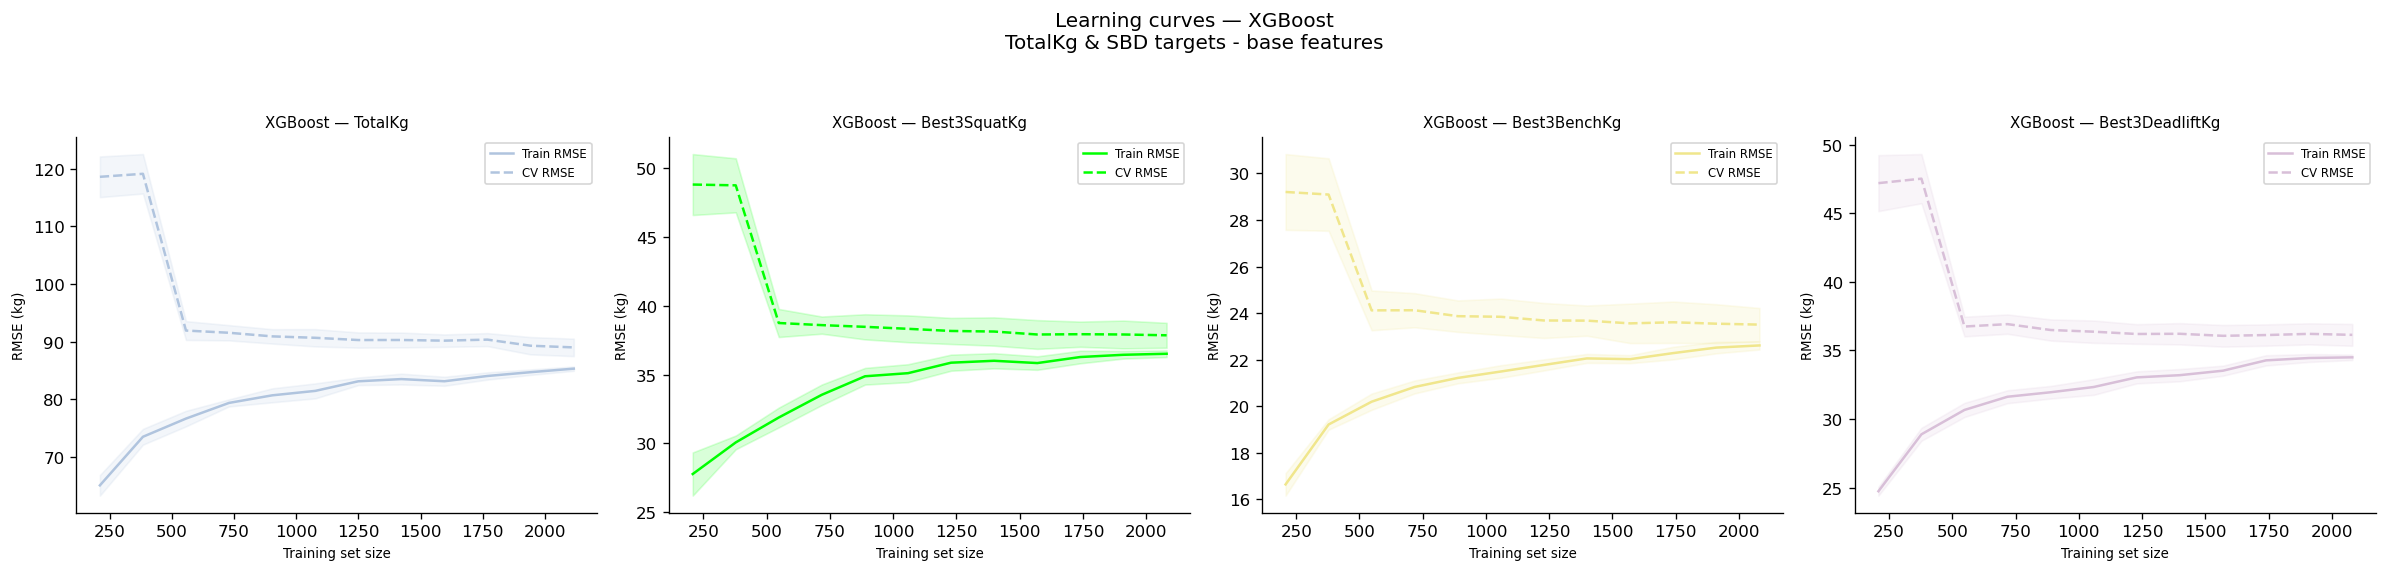

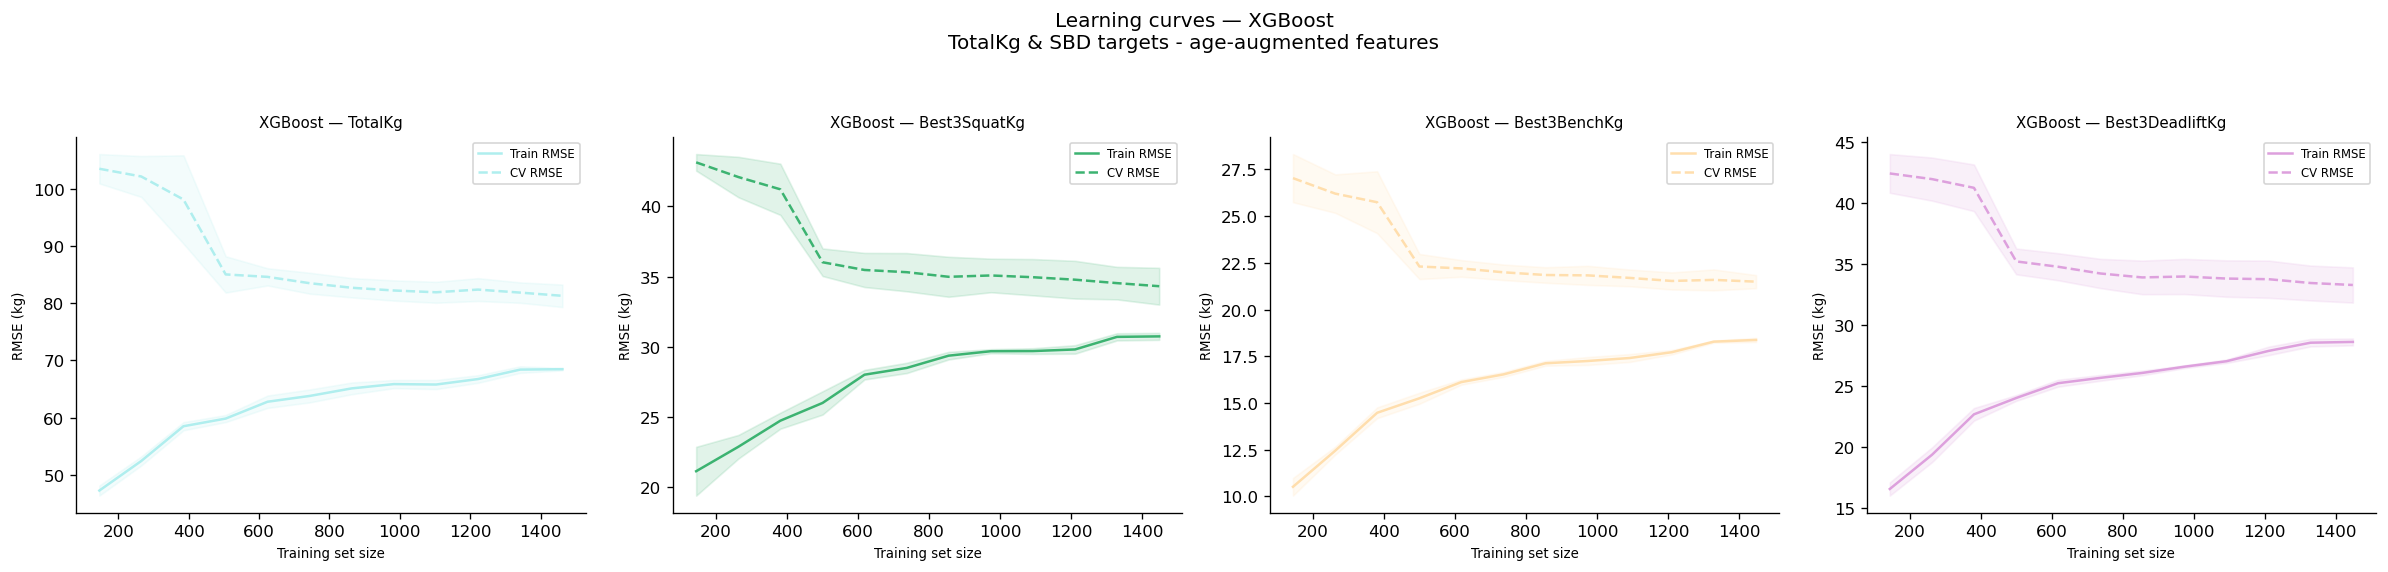

In [70]:
# 1. Instantiate the base models using the Optuna hyperparameter dictionaries
# TotalKg; base features
xgb_model_base_total = xgb.XGBRegressor(**best_params_base_total, n_jobs=-1)

# SBD targets; base features
xgb_models_base_sbd = {}

for target in target_names_sbd:
    xgb_models_base_sbd[target] = xgb.XGBRegressor(
        **best_params_base_sbd[target], 
        n_jobs=-1
    )

# 2. Set up the grid (1 row for XGBoost, 4 columns for targets)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
lc_colours = ['lightsteelblue', 'lime', 'khaki', 'thistle']
num_targets = len(all_targets_list)

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    # Select correct dataset
    X_np = X_base_total_np if target == "TotalKg" else X_base_sbd_np
    Y_np = Y_base_total_np if target == "TotalKg" else Y_base_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_base_sbd_np[:, t_idx]   

    # Select correct model instance (Do not use pre-fitted models)
    if target == "TotalKg":
        current_model = xgb_model_base_total
    else:
        current_model = xgb_models_base_sbd[target]

    # Compute the learning curve
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, current_model, train_sizes, kf_lc
    )

    # Plot on the single row array
    plot_single_lc(
        axes[col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"XGBoost — {target}",
        colour,
    )

plt.suptitle(
    "Learning curves — XGBoost\n"
    "TotalKg & SBD targets - base features",
    fontsize=12,
    y=1.05,
)
plt.tight_layout()
plt.savefig(plots_dir_p5 / "learning_curves_xgb_base.png", bbox_inches="tight")
plt.show()

# 1. Instantiate the age-augmented models
xgb_model_age_total = xgb.XGBRegressor(**best_params_age_total, n_jobs=-1)

xgb_models_age_sbd = {
    target: xgb.XGBRegressor(**best_params_age_sbd[target], n_jobs=-1)
    for target in target_names_sbd
}

# 2. Set up the grid
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
lc_colours = ['paleturquoise', 'mediumseagreen', 'navajowhite', 'plum']

for col_idx in range(num_targets):
    target = all_targets_list[col_idx]
    colour = lc_colours[col_idx]

    # Select correct dataset
    X_np = X_age_total_np if target == "TotalKg" else X_age_sbd_np
    Y_np = Y_age_total_np if target == "TotalKg" else Y_age_sbd_np

    if target != "TotalKg":
        t_idx = target_names_sbd.index(target)
        Y_np = Y_age_sbd_np[:, t_idx]   

    # Select correct model instance
    if target == "TotalKg":
        current_model = xgb_model_age_total
    else:
        current_model = xgb_models_age_sbd[target]

    # Compute learning curve
    ts, tr_mean, tr_std, cv_mean, cv_std = compute_learning_curve(
        X_np, Y_np, current_model, train_sizes, kf_lc
    )

    plot_single_lc(
        axes[col_idx],
        ts,
        tr_mean,
        tr_std,
        cv_mean,
        cv_std,
        f"XGBoost — {target}",
        colour,
    )

plt.suptitle(
    "Learning curves — XGBoost\n"
    "TotalKg & SBD targets - age-augmented features",
    fontsize=12,
    y=1.05,
)
plt.tight_layout()
plt.savefig(plots_dir_p5 / "learning_curves_xgb_age.png", bbox_inches="tight")
plt.show()

## Cell 58 — SHAP Analysis: TotalKG & SBD targets; base features 

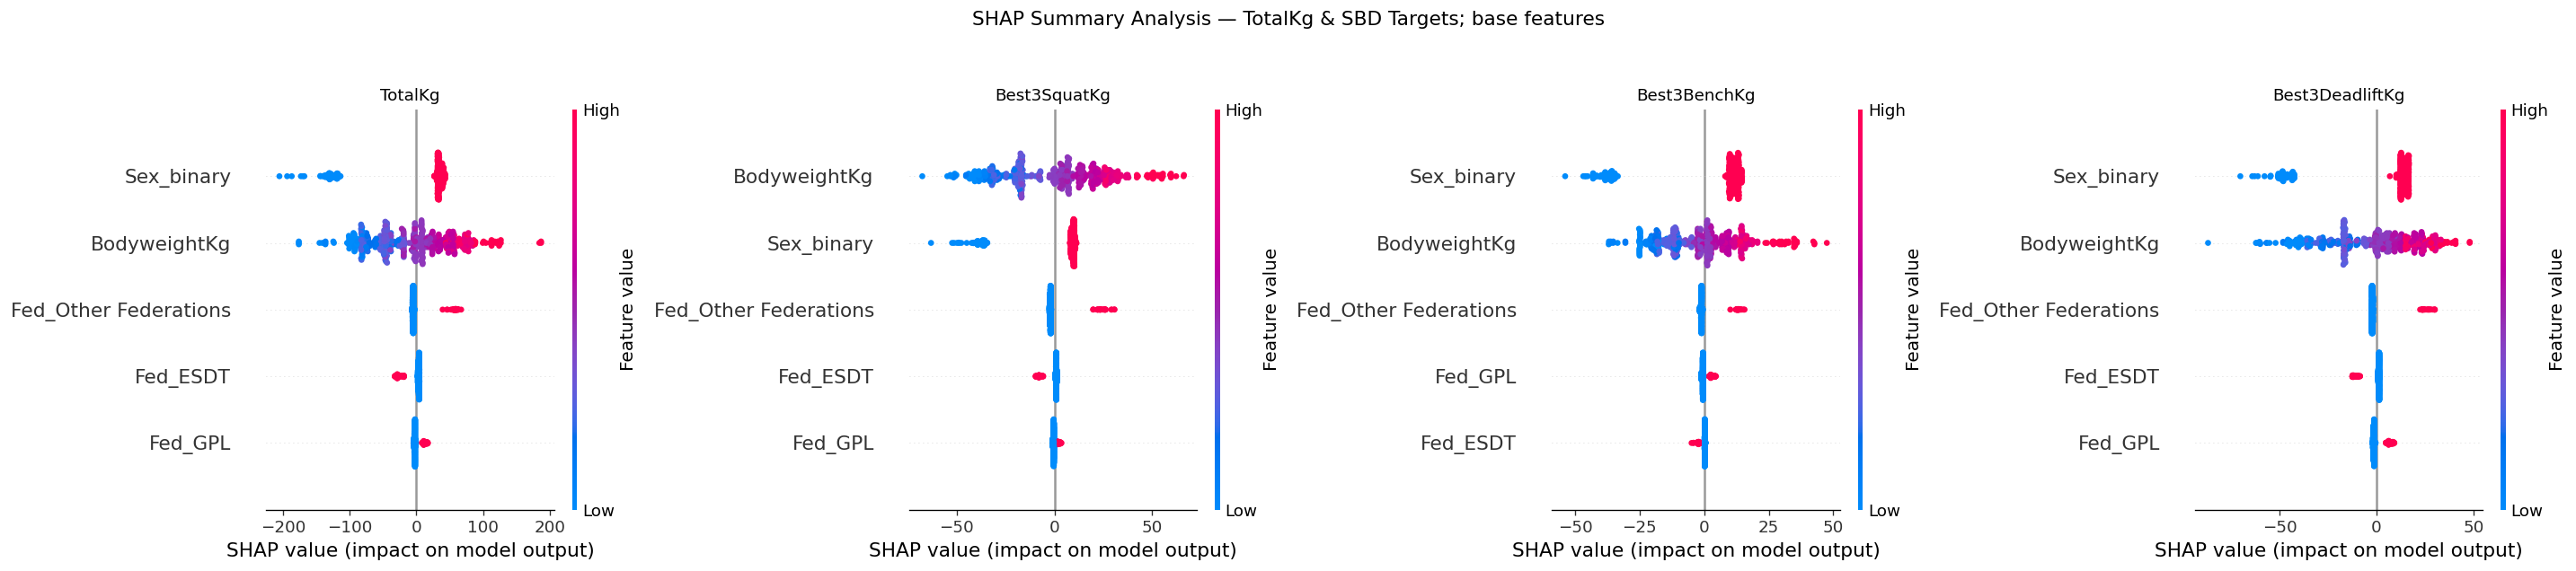

Mean absolute SHAP: TotalKg
Sex_binary              55.13
BodyweightKg            50.40
Fed_Other Federations    8.65
Fed_ESDT                 6.32
Fed_GPL                  4.30
Mean absolute SHAP: SBD targets

  Best3SquatKg:
BodyweightKg            21.86
Sex_binary              14.80
Fed_Other Federations    3.27
Fed_ESDT                 1.67
Fed_GPL                  0.67

  Best3BenchKg:
Sex_binary              16.64
BodyweightKg            11.78
Fed_Other Federations    1.76
Fed_GPL                  1.01
Fed_ESDT                 0.46

  Best3DeadliftKg:
Sex_binary              20.68
BodyweightKg            19.10
Fed_Other Federations    3.38
Fed_ESDT                 2.34
Fed_GPL                  2.32


In [72]:
# Combined SHAP Analysis: TotalKg & SBD Targets in a 1x4 Grid

# 1. Prepare named DataFrames for clean feature rendering
X_te_named_base_total = pd.DataFrame(
    X_te_base_total.values.astype(float),
    columns = feature_names_base_total
)

X_te_named_base_sbd = pd.DataFrame(
    X_te_base_sbd.values.astype(float),
    columns = feature_names_base_sbd
)

# Containers to store global feature importance metrics
shap_importance_base_total = None
shap_importance_base_sbd = {}

# 2. Initialize the 1 x 4 plotting layout
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# --- Panel 1: TotalKg ---
explainer_base_total = shap.TreeExplainer(xgb_final_base_total)
shap_values_base_total = explainer_base_total(X_te_named_base_total)

plt.sca(axes[0])
shap.summary_plot(
    shap_values_base_total,
    X_te_named_base_total,
    feature_names = feature_names_base_total,
    show          = False,
    plot_size     = None
)
axes[0].set_title('TotalKg', fontsize=11)

# Calculate TotalKg importance numbers
mean_abs_base_total = np.abs(shap_values_base_total.values).mean(axis=0)
shap_importance_base_total = (
    pd.Series(mean_abs_base_total, index=feature_names_base_total)
    .sort_values(ascending=False)
)

# --- Panels 2-4: SBD targets ---
for i, target in enumerate(target_names_sbd):
    col_idx = i + 1  # Offset by 1 to skip the TotalKg panel
    explainer_base_sbd = shap.TreeExplainer(xgb_final_base_sbd[target])
    sv                  = explainer_base_sbd(X_te_named_base_sbd)

    plt.sca(axes[col_idx])
    shap.summary_plot(
        sv,
        X_te_named_base_sbd,
        feature_names = feature_names_base_sbd,
        show          = False,
        plot_size     = None
    )
    axes[col_idx].set_title(target, fontsize=11)

    # Calculate SBD importance numbers
    mean_abs_base_sbd = np.abs(sv.values).mean(axis=0)
    shap_importance_base_sbd[target] = (
        pd.Series(mean_abs_base_sbd, index=feature_names_base_sbd)
        .sort_values(ascending=False)
    )

# 3. Finalize and save the combined figure
plt.suptitle('SHAP Summary Analysis — TotalKg & SBD Targets; base features', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(plots_dir_p5 / 'shap_summary_combined_1x4_base.png', bbox_inches='tight')
plt.show()

# 4. Console printouts for exact numerical review
print('Mean absolute SHAP: TotalKg')
print(shap_importance_base_total.round(3).to_string())

print('Mean absolute SHAP: SBD targets')
for target in target_names_sbd:
    print(f'\n  {target}:')
    print(shap_importance_base_sbd[target].round(3).to_string())

## Cell 59 — SHAP Analysis: TotalKG & SBD targets; age-augmented features 

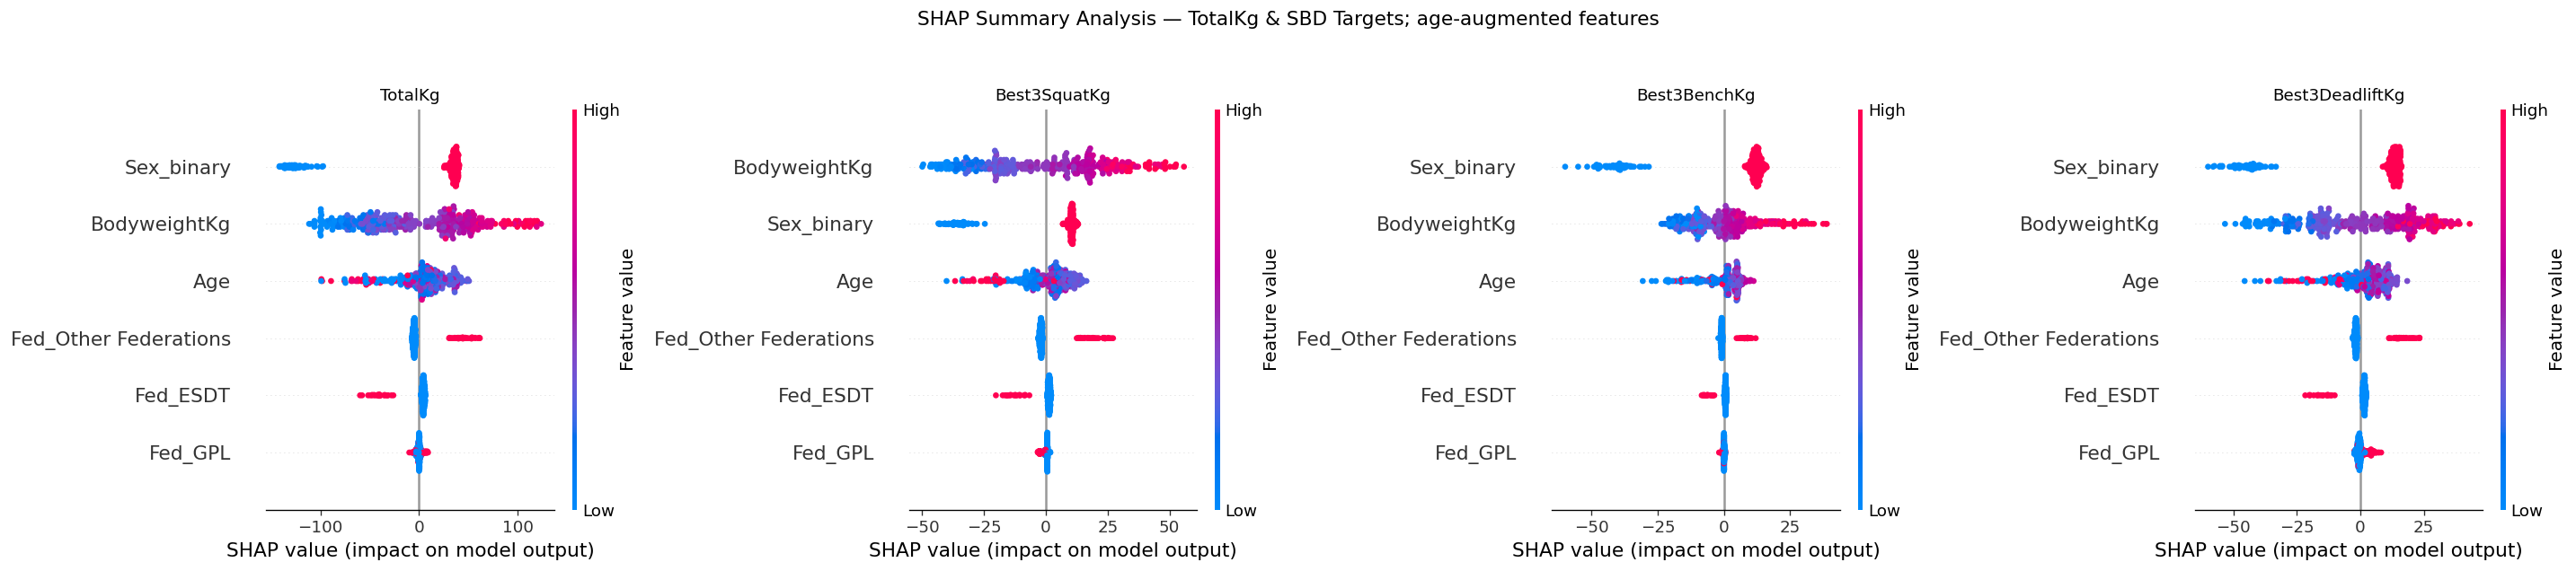

Mean absolute SHAP: TotalKg
Sex_binary              54.18
BodyweightKg            50.88
Age                     20.70
Fed_Other Federations    9.52
Fed_ESDT                 6.99
Fed_GPL                  1.50
Mean absolute SHAP: SBD targets

  Best3SquatKg:
BodyweightKg            22.51
Sex_binary              15.36
Age                      7.82
Fed_Other Federations    3.71
Fed_ESDT                 1.98
Fed_GPL                  0.73

  Best3BenchKg:
Sex_binary              17.87
BodyweightKg             9.59
Age                      5.27
Fed_Other Federations    1.63
Fed_ESDT                 0.92
Fed_GPL                  0.19

  Best3DeadliftKg:
Sex_binary              19.75
BodyweightKg            18.86
Age                      8.08
Fed_Other Federations    3.38
Fed_ESDT                 2.33
Fed_GPL                  1.22


In [73]:
# Combined SHAP Analysis: TotalKg & SBD Targets in a 1x4 Grid

# 1. Prepare named DataFrames for clean feature rendering
X_te_named_age_total = pd.DataFrame(
    X_te_age_total.values.astype(float),
    columns = feature_names_age_total
)

X_te_named_age_sbd = pd.DataFrame(
    X_te_age_sbd.values.astype(float),
    columns = feature_names_age_sbd
)

# Containers to store global feature importance metrics
shap_importance_age_total = None
shap_importance_age_sbd = {}

# 2. Initialize the 1 x 4 plotting layout
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# --- Panel 1: TotalKg ---
explainer_age_total = shap.TreeExplainer(xgb_final_age_total)
shap_values_age_total = explainer_age_total(X_te_named_age_total)

plt.sca(axes[0])
shap.summary_plot(
    shap_values_age_total,
    X_te_named_age_total,
    feature_names = feature_names_age_total,
    show          = False,
    plot_size     = None
)
axes[0].set_title('TotalKg', fontsize=11)

# Calculate TotalKg importance numbers
mean_abs_age_total = np.abs(shap_values_age_total.values).mean(axis=0)
shap_importance_age_total = (
    pd.Series(mean_abs_age_total, index=feature_names_age_total)
    .sort_values(ascending=False)
)

# --- Panels 2-4: SBD targets ---
for i, target in enumerate(target_names_sbd):
    col_idx = i + 1  # Offset by 1 to skip the TotalKg panel
    explainer_age_sbd = shap.TreeExplainer(xgb_final_age_sbd[target])
    sv                  = explainer_age_sbd(X_te_named_age_sbd)

    plt.sca(axes[col_idx])
    shap.summary_plot(
        sv,
        X_te_named_age_sbd,
        feature_names = feature_names_age_sbd,
        show          = False,
        plot_size     = None
    )
    axes[col_idx].set_title(target, fontsize=11)

    # Calculate SBD importance numbers
    mean_abs_age_sbd = np.abs(sv.values).mean(axis=0)
    shap_importance_age_sbd[target] = (
        pd.Series(mean_abs_age_sbd, index=feature_names_age_sbd)
        .sort_values(ascending=False)
    )

# 3. Finalize and save the combined figure
plt.suptitle('SHAP Summary Analysis — TotalKg & SBD Targets; age-augmented features', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(plots_dir_p5 / 'shap_summary_combined_1x4_age.png', bbox_inches='tight')
plt.show()

# 4. Console printouts for exact numerical review
print('Mean absolute SHAP: TotalKg')
print(shap_importance_age_total.round(3).to_string())

print('Mean absolute SHAP: SBD targets')
for target in target_names_sbd:
    print(f'\n  {target}:')
    print(shap_importance_age_sbd[target].round(3).to_string())

## Cell 60 — SHAP dependence plot for Age

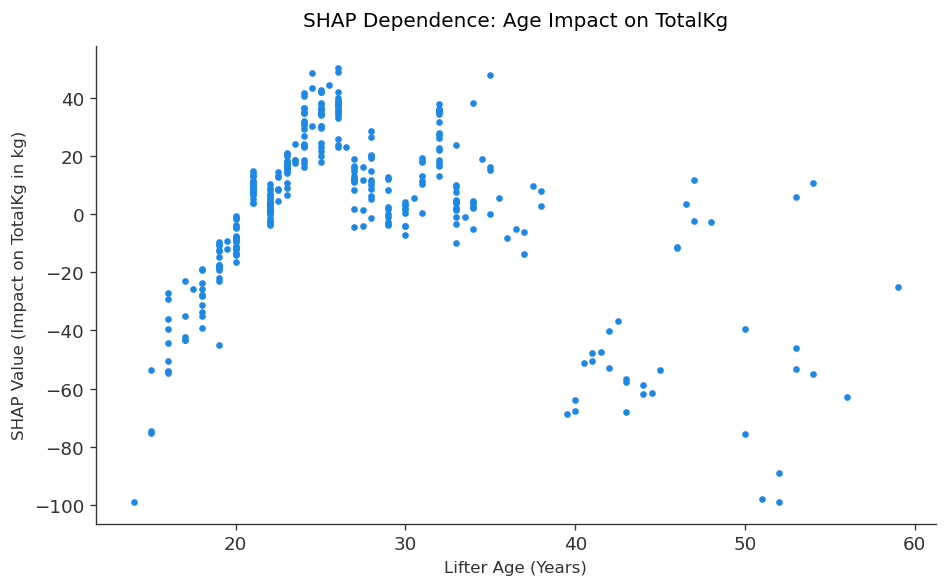

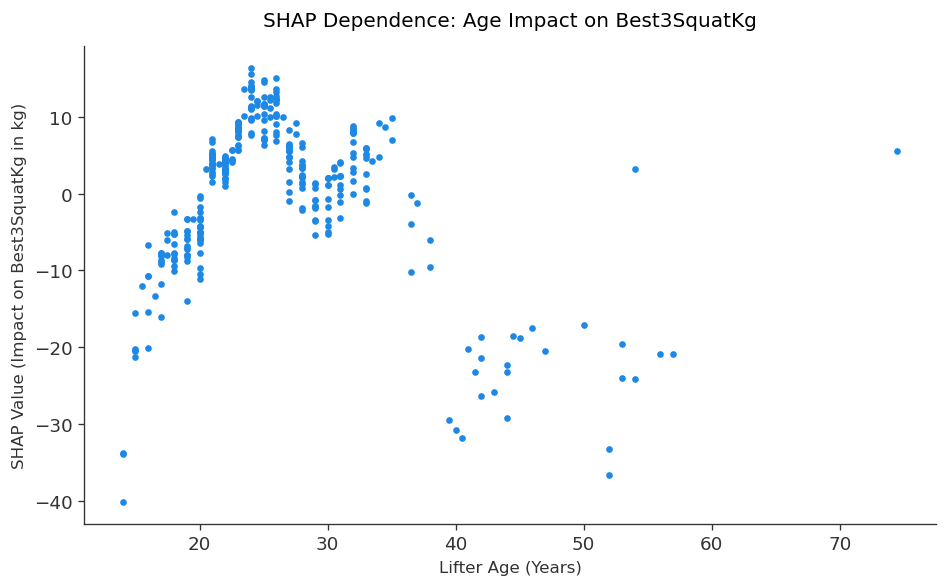

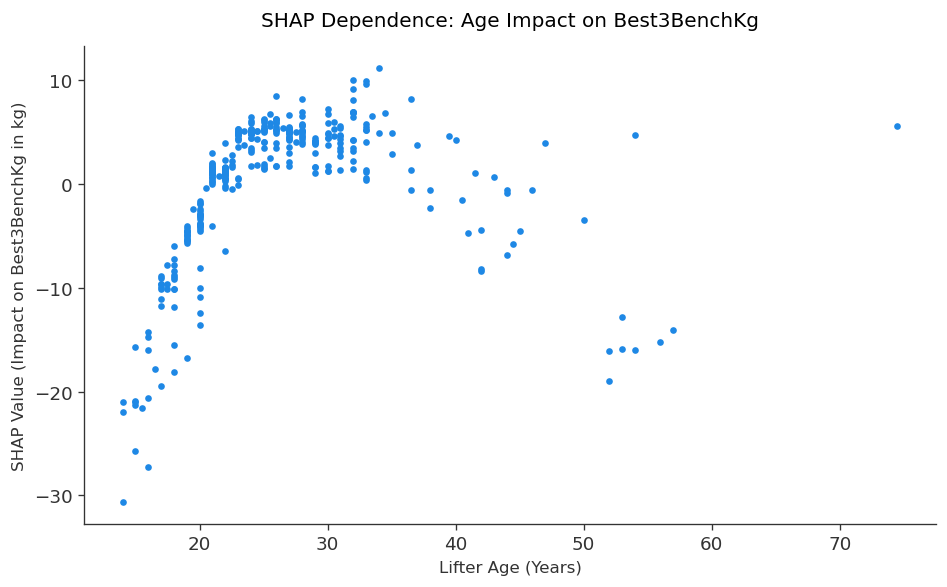

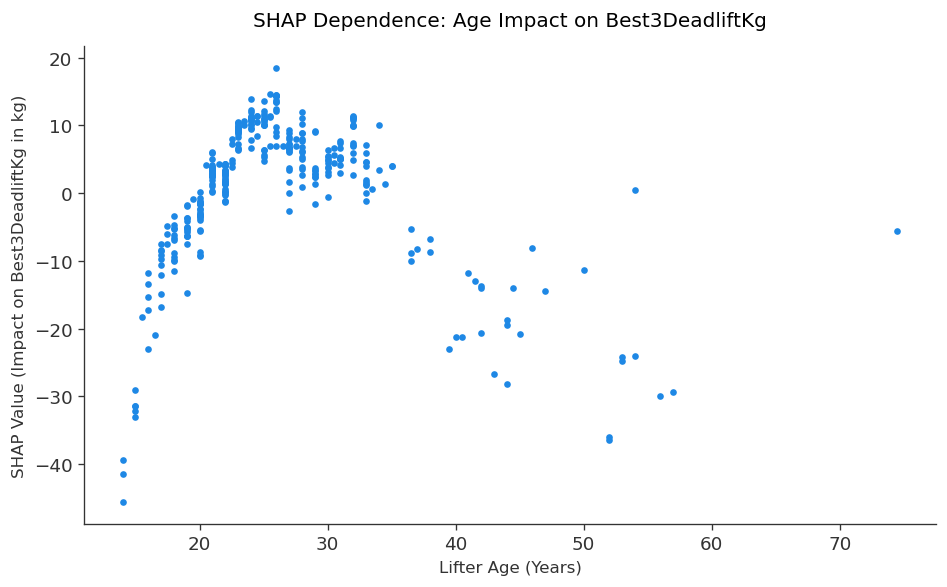

In [76]:
age_feature_name = 'Age' 

explainer_age_total = shap.TreeExplainer(xgb_final_age_total)
shap_values_age_total = explainer_age_total(X_te_named_age_total)

# 1. TotalKg Age Dependence Plot
fig, ax = plt.subplots(figsize=(8, 5))

shap.dependence_plot(
    age_feature_name,
    shap_values_age_total.values,  # Matrix array of values
    X_te_named_age_total,          # Feature values DataFrame
    interaction_index=None,        # Drops color coding for a clean single-feature curve
    show=False,
    ax=ax
)

ax.set_title(f'SHAP Dependence: Age Impact on TotalKg', fontsize=12, pad=12)
ax.set_xlabel('Lifter Age (Years)', fontsize=10)
ax.set_ylabel('SHAP Value (Impact on TotalKg in kg)', fontsize=10)
plt.tight_layout()
plt.savefig(plots_dir_p5 / 'shap_dependence_age_TotalKg.png', bbox_inches='tight')
plt.show()


# 2. SBD Targets Age Dependence Plots
for target in target_names_sbd:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Generate standalone explainer and values per lift
    explainer_age_sbd = shap.TreeExplainer(xgb_final_age_sbd[target])
    sv = explainer_age_sbd(X_te_named_age_sbd)

    shap.dependence_plot(
        age_feature_name,
        sv.values,
        X_te_named_age_sbd,
        interaction_index=None,
        show=False,
        ax=ax
    )
    
    ax.set_title(f'SHAP Dependence: Age Impact on {target}', fontsize=12, pad=12)
    ax.set_xlabel('Lifter Age (Years)', fontsize=10)
    ax.set_ylabel(f'SHAP Value (Impact on {target} in kg)', fontsize=10)
    plt.tight_layout()
    plt.savefig(plots_dir_p5 / f'shap_dependence_age_{target}.png', bbox_inches='tight')
    plt.show()